
# DTW Clustering: Accumulated Capacity, New Capacity, and LCOH

This notebook runs **independent DTW-based clustering** for three variables and saves outputs under `DTW_results/`:

1. **Total capacity (system state)** — `aggregates/investment_plans_wide.csv`  


Each section:
- builds & aligns time series per scenario
- computes a **DTW distance matrix**
- clusters with **Agglomerative (average linkage)** on precomputed distances
- generates a **DTW–MDS scatter** (variation) and a **PCA scatter** (PC1–PC2) + PCA notes

At the end, we compare labelings across variables using **Adjusted Rand Index (ARI)**.


In [1]:

# Imports & basic config
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from nbclient import NotebookClient
from nbformat import read

# Output dir
OUT_DIR = Path("DTW_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_STATE = 42

print(f"✅ Output directory ready at: {OUT_DIR.resolve()}")
print("✅ Imports OK")

✅ Output directory ready at: C:\Paper 4\Outputs\Raw\DTW_results
✅ Imports OK


## Create Investment plan wides and long files for total capacity

In [2]:
# Root is current folder (where this code lives and LTLE_Scenario_* folders exist)
ROOT = Path(".")
FNAME = "TotCapacityAnn.csv"
PATTERNS = ["LTLE_Scenario_*", "LTLE_scenario_*"]

NAMES = {
    'Waste Incineration CHP': ['BristaB2', 'HgldP3468', 'LSVTACHP'],
    'Data Centre Heat Pumps': ['DCACC'],
    'Bio Oil CHP': ['KVV1'],
    'Sewage Treatment Heat Pumps': ['HmrbySEWHP'],
    'Bio Oil HOBs': ['DECFOHOB', 'CSBOHOB'],
    'Bio Pellets CHP': ['HslbyP1toP3'],
    'Wood Chips CHP': ['BristaB1', 'KVV8'],
    'Sea Water Heat Pumps': ['VVNHP'],
    'Electric Boilers': ['VVHVELHOB'],
    'Low Temperature Sources Heat Pumps': ['SUPACC'],
}

def load_and_group_one(scen_dir: Path):
    csv_path = scen_dir / FNAME
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    if not {"YEAR","TECHNOLOGY","VALUE"}.issubset(df.columns):
        return None
    tech_keep = {t for ts in NAMES.values() for t in ts}
    df = df[df["TECHNOLOGY"].isin(tech_keep)].copy()
    if df.empty:
        return None
    piv = df.pivot_table(values="VALUE", index="YEAR", columns="TECHNOLOGY", aggfunc="sum").fillna(0.0)
    grouped = pd.DataFrame(index=piv.index)
    for cat, techs in NAMES.items():
        cols_present = [c for c in techs if c in piv.columns]
        grouped[cat] = piv[cols_present].sum(axis=1) if cols_present else 0.0
    grouped = grouped.reset_index().rename(columns={"YEAR":"Year"})
    grouped["Scenario"] = scen_dir.name
    return grouped

scen_dirs = []
for pat in PATTERNS:
    scen_dirs += [d for d in ROOT.glob(pat) if d.is_dir()]
scen_dirs = sorted(scen_dirs)

all_grouped = []
for d in scen_dirs:
    g = load_and_group_one(d)
    if g is not None:
        all_grouped.append(g)

if not all_grouped:
    raise RuntimeError("No scenarios processed. Are the LTLE_Scenario_* folders here, and do they contain AccumulatedNewCapacity.csv?")

df_wide = pd.concat(all_grouped, ignore_index=True)

out_dir = ROOT / "aggregates"
out_dir.mkdir(exist_ok=True)
df_wide.to_csv(out_dir / "totcap_plans_wide.csv", index=False)

df_long = df_wide.melt(id_vars=["Scenario","Year"], var_name="Category", value_name="Capacity_MW")
df_long.to_csv(out_dir / "totcap_plans_long.csv", index=False)

idx = df_wide.groupby("Scenario")["Year"].idxmax()
snapshot_last = df_wide.loc[idx].reset_index(drop=True)
snapshot_last.to_csv(out_dir / "totcap_snapshot_lastyear.csv", index=False)

print(f"Processed {len(scen_dirs)} scenario folders.")
print("Saved to ./aggregates/: totcap_plans_wide.csv, totcap_plans_long.csv, totcap_snapshot_lastyear.csv")

Processed 408 scenario folders.
Saved to ./aggregates/: totcap_plans_wide.csv, totcap_plans_long.csv, totcap_snapshot_lastyear.csv


## Compute Heat KPIs

In [3]:
# Path to the notebook you want to execute
notebook_path = "Heat_KPIs_Workflow.ipynb"

# Load and execute the notebook
with open(notebook_path) as f:
    nb = read(f, as_version=4)

client = NotebookClient(nb)
client.execute()

print("✅ Notebook executed successfully — results written to CSVs!")


✅ Notebook executed successfully — results written to CSVs!


In [4]:
# Results registry: collects outputs from each variable block
RESULTS = {}  # e.g., RESULTS['accumulated'] = {'D':..., 'labels':..., 'scenarios':..., 'X3':..., 'years':...}

def register_result(name, D, labels, scenarios, X3=None, years=None, persist=False, out_dir=OUT_DIR):
    """
    name: 'accumulated' | 'newcap' | 'lcoh' | 'totcap'
    persist=True also writes artifacts to disk so the final section can reload after a kernel restart.
    """
    RESULTS[name] = {
        "D": D,
        "labels": labels,
        "scenarios": list(scenarios),
        "X3": X3,
        "years": list(years) if years is not None else None,
    }
    if persist:
        np.save(out_dir / f"D_{name}.npy", D)
        pd.DataFrame({"Scenario": scenarios, "Cluster": labels}).to_csv(out_dir / f"{name}_dtw_labels.csv", index=False)
        if X3 is not None:
            np.save(out_dir / f"X3_{name}.npy", X3)
        if years is not None:
            pd.Series(years, name="Year").to_csv(out_dir / f"years_{name}.csv", index=False)


## Configure file paths

In [5]:
TOTCAP_PATH = Path("aggregates/totcap_plans_wide.csv")

In [6]:
# 1) Do we actually have them in df_long?
print("Total scenarios in df_long:", df_long["Scenario"].nunique())
print("Some scenario samples:", sorted(df_long["Scenario"].astype(str).unique())[:5], "...")

# 2) Compare against folders you expect
import os, re
expected = sorted([

    d for d in os.listdir("C:\Paper 4\Outputs\Raw")  # adjust root
    if re.search(r"LTLE_scenario_\d+", d)
])
expected_ids = sorted(int(re.search(r"(\d+)$", s).group(1)) for s in expected)

in_df_ids = sorted(
    df_long["Scenario"].astype(str).str.extract(r"(\d+)").dropna()[0].astype(int).unique().tolist()
)

missing_in_df = sorted(set(expected_ids) - set(in_df_ids))
print("Scenarios present on disk but missing in df_long:", missing_in_df[:10])

# 3) Year sanity (did coercion drop anything?)
print("Non-numeric Year rows:", df_long.loc[pd.to_numeric(df_long["Year"], errors="coerce").isna()].shape[0])

Total scenarios in df_long: 204
Some scenario samples: ['LTLE_scenario_001', 'LTLE_scenario_002', 'LTLE_scenario_004', 'LTLE_scenario_006', 'LTLE_scenario_007'] ...
Scenarios present on disk but missing in df_long: []
Non-numeric Year rows: 0


## Helper functions (1/3): alignment & normalization

In [7]:

def pivot_align_timeseries(df_long, index_col="Scenario", time_col="Year", value_cols=None, agg="sum"):
    """
    Pivot a long/wide dataframe to a (N, T, F) cube aligned on union of time steps.
    Univariate: value_cols is a single column name.
    Multivariate: value_cols is a list of column names (e.g., techs).
    Returns (X3, scenarios, years, colnames).
    """
    if value_cols is None:
        raise ValueError("value_cols must be provided (str or list of str).")
    if isinstance(value_cols, str):
        value_cols = [value_cols]
    
    df = df_long.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce").round().astype("Int64")
    df = df.dropna(subset=[time_col]).copy()
    df[time_col] = df[time_col].astype(int)

    bad = df[pd.to_datetime(df[time_col].astype(str).str.strip(), errors="coerce").isna()]
    print(f"[pivot] rows with non-parsable years: {len(bad)}")


    if agg not in ("sum", "mean"):
        raise ValueError("agg must be 'sum' or 'mean'")
    aggfunc = {"sum": np.sum, "mean": np.mean}[agg]

    years_union = sorted(df[time_col].unique())
    scenarios = sorted(df[index_col].unique())

    wide_blocks, colnames = [], []
    for vc in value_cols:
        sub = df[[index_col, time_col, vc]].copy()
        pv = sub.pivot_table(index=index_col, columns=time_col, values=vc, aggfunc=aggfunc)
        pv = pv.reindex(index=scenarios, columns=years_union)
        # interpolate across time per scenario; then forward/back fill edges
        pv = pv.apply(lambda s: s.interpolate(limit_direction="both"), axis=1)
        pv = pv.fillna(method="ffill", axis=1).fillna(method="bfill", axis=1)
        wide_blocks.append(pv)
        colnames.extend([(vc, y) for y in pv.columns.to_list()])

    years = years_union
    wide_arrays = [wb.values for wb in wide_blocks]  # each (N, T)
    X3 = np.stack(wide_arrays, axis=2)               # (N, T, F)
    return X3, scenarios, years, colnames


def znormalize_timeseries(X3):
    """Z-normalize each (scenario, feature) time series over time."""
    X = X3.copy().astype(float)
    N, T, F = X.shape
    for i in range(N):
        for f in range(F):
            series = X[i, :, f]
            mu = np.nanmean(series)
            sigma = np.nanstd(series)
            if sigma == 0 or np.isnan(sigma):
                X[i, :, f] = series - (0.0 if np.isnan(mu) else mu)
            else:
                X[i, :, f] = (series - mu) / sigma
    return X


## Helper functions (2/3): DTW distances (with optional Sakoe–Chiba band)

In [8]:

def _dtw_univariate(ts1, ts2, window=None):
    n, m = len(ts1), len(ts2)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_start = 1 if window is None else max(1, i - window)
        j_end = m + 1 if window is None else min(m + 1, i + window + 1)
        for j in range(j_start, j_end):
            cost = abs(ts1[i - 1] - ts2[j - 1])
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return float(D[n, m])


def _dtw_multivariate(ts1, ts2, window=None):
    n, m, F = ts1.shape[0], ts2.shape[0], ts1.shape[1]
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_start = 1 if window is None else max(1, i - window)
        j_end = m + 1 if window is None else min(m + 1, i + window + 1)
        for j in range(j_start, j_end):
            diff = ts1[i - 1, :] - ts2[j - 1, :]
            cost = float(np.sqrt(np.dot(diff, diff)))
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return float(D[n, m])


def compute_dtw_distance_matrix(X3, band_frac=0.15):
    """Compute pairwise DTW distances. X3: (N, T, F)."""
    N, T, F = X3.shape
    window = None
    if band_frac is not None:
        window = max(1, int(round(band_frac * T)))
    D = np.zeros((N, N), dtype=float)
    for i in range(N):
        for j in range(i + 1, N):
            if F == 1:
                d = _dtw_univariate(X3[i, :, 0], X3[j, :, 0], window=window)
            else:
                d = _dtw_multivariate(X3[i, :, :], X3[j, :, :], window=window)
            D[i, j] = D[j, i] = d
    return D


## Helper functions (3/3): Clustering, MDS embedding, PCA & plotting

In [9]:

def agglomerative_from_dist(D, n_clusters=3):
    try:
        model = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average")
    except TypeError:
        model = AgglomerativeClustering(n_clusters=n_clusters, affinity="precomputed", linkage="average")
    return model.fit_predict(D)


def mds_from_dist(D, random_state=RANDOM_STATE):
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=random_state)
    return mds.fit_transform(D)


def pca_from_timeseries(X3, scenarios, out_prefix, out_dir=OUT_DIR, labels=None):
    N, T, F = X3.shape
    X2D = X3.reshape(N, T * F)
    scaler = StandardScaler()
    Xstd = scaler.fit_transform(X2D)

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(Xstd)

    plt.figure(figsize=(8, 6))
    if labels is None:
        plt.scatter(pcs[:, 0], pcs[:, 1], s=60, alpha=0.8)
    else:
        sc = plt.scatter(pcs[:, 0], pcs[:, 1], c=labels, s=60, alpha=0.85)
        cb = plt.colorbar(sc); cb.set_label("Cluster")
    for i, scid in enumerate(scenarios):
        plt.annotate(str(scid), (pcs[i, 0], pcs[i, 1]), fontsize=7, ha="center", alpha=0.8)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title("PCA of time-series (flattened)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    png = out_dir / f"{out_prefix}_pca.png"
    plt.savefig(png, dpi=800)
    plt.close()
    plt.show()

    txt = out_dir / f"{out_prefix}_pca_notes.txt"
    with open(txt, "w") as f:
        f.write(
            "PCA interpretation:\n"
            "- PC1 typically captures overall level/trend across the horizon (broad increases/decreases).\n"
            "- PC2 often captures timing/shape differences (early vs late ramp-up, mid-horizon bumps).\n"
            "- PCA helps explain which temporal patterns drive cross-scenario variance,\n"
            "  complementing DTW (which focuses on shape similarity with time-warping).\n"
        )
    return png, txt


def plot_mds_scatter(X2, scenarios, labels, out_prefix, out_dir=OUT_DIR):
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=60, alpha=0.85)
    cb = plt.colorbar(sc); cb.set_label("Cluster")
    for i, scid in enumerate(scenarios):
        plt.annotate(str(scid), (X2[i, 0], X2[i, 1]), fontsize=7, ha="center", alpha=0.8)
    plt.title("DTW-MDS: variation between scenarios")
    plt.xlabel("MDS-1"); plt.ylabel("MDS-2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    png = out_dir / f"{out_prefix}_dtw_mds.png"
    plt.savefig(png, dpi=150)
    plt.close()
    return png

## clustering statistics (silhouette, sizes, k)

In [10]:
# --- Clustering statistics (DTW silhouette, cluster sizes) ---
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
from pathlib import Path

def summarize_clustering(prefix: str, D: np.ndarray, scenarios: list, labels: np.ndarray, out_dir: Path = OUT_DIR):
    """
    prefix: 'accumulated' | 'newcap' | 'lcoh'
    D:      precomputed DTW distance matrix (N x N)
    labels: cluster labels (length N)
    """
    # how many effective clusters (ignore noise=-1 if ever used)
    uniq = sorted(set([int(x) for x in labels if x >= 0]))
    k_eff = len(uniq)
    sizes = {c: int(np.sum(labels == c)) for c in uniq}

    # DTW silhouette (precomputed distances)
    sil = np.nan
    if k_eff >= 2 and len(labels) >= 3:
        try:
            sil = float(silhouette_score(D, labels, metric="precomputed"))
        except Exception:
            pass

    # print summary
    print(f"\n[{prefix}] CLUSTER SUMMARY")
    print(f"- #clusters: {k_eff}")
    print(f"- Cluster sizes: {sizes}")
    print(f"- Silhouette (DTW, precomputed): {sil:.3f}" if not np.isnan(sil) else "- Silhouette: n/a")

    # save as csv
    rows = [{"Cluster": c, "Size": sizes[c]} for c in uniq]
    df_sizes = pd.DataFrame(rows)
    df_sizes["Silhouette_DTW"] = sil
    df_sizes.to_csv(out_dir / f"{prefix}_cluster_stats.csv", index=False)
    return sil, df_sizes

## “variation across scenarios” time-series plots

In [11]:
# --- Variation plots: spaghetti + cluster mean ±1σ ---
import numpy as np
import matplotlib.pyplot as plt

def _collapse_to_total(X3: np.ndarray) -> np.ndarray:
    """
    Sum over features -> return (N, T) total per scenario per year.
    For univariate (F=1), this is just squeeze.
    """
    if X3.shape[2] == 1:
        return X3[:, :, 0]
    return np.sum(X3, axis=2)  # sum across features (techs)

def plot_spaghetti_with_cluster_mean(prefix: str, X3: np.ndarray, years: list, scenarios: list, labels: np.ndarray, out_dir: Path = OUT_DIR):
    """
    For the variable used for clustering, show per-scenario lines (faint),
    and cluster mean ±1σ (bold). Saves and shows inline.
    """
    Y = _collapse_to_total(X3)  # (N, T)
    N, T = Y.shape
    years = np.array(years)

    plt.figure(figsize=(9, 6))

    # faint spaghetti lines colored by cluster
    for i in range(N):
        plt.plot(years, Y[i, :], alpha=0.25)

    # overlay cluster means and ±1σ band
    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if idx.size == 0: 
            continue
        mu = Y[idx, :].mean(axis=0)
        sd = Y[idx, :].std(axis=0)

        # mean line
        plt.plot(years, mu, linewidth=2.5, label=f"Cluster {c} mean")

        # ±1σ band (light fill)
        plt.fill_between(years, mu - sd, mu + sd, alpha=0.15)

    plt.title(f"{prefix}: variation across scenarios (total over techs if multivariate)")
    plt.xlabel("Year")
    plt.ylabel("Value (total)" if X3.shape[2] > 1 else "Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()  # inline

    png = out_dir / f"{prefix}_variation_spaghetti.png"
    plt.savefig(png, dpi=150)
    plt.close()
    return png

## Cell: cluster-mean trajectories (clean)

In [12]:
# --- Variation plot: cluster means only (optionally ±1σ band) ---
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def _collapse_to_total(X3: np.ndarray) -> np.ndarray:
    """
    Sum across features -> (N, T) total per scenario per year.
    If univariate (F=1), just squeeze.
    """
    return X3[:, :, 0] if X3.shape[2] == 1 else np.sum(X3, axis=2)

def plot_cluster_means_only(
    prefix: str,
    X3: np.ndarray,
    years: list,
    labels: np.ndarray,
    out_dir: Path = OUT_DIR,
    show_band: bool = False,   # set True if you also want ±1σ around the mean
    linewidth: float = 3.0
):
    """
    Plot only the mean trajectory per cluster (no spaghetti). Saves and shows inline.
    """
    Y = _collapse_to_total(X3)  # (N, T)
    years = np.asarray(years)

    plt.figure(figsize=(9, 6))

    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if idx.size == 0:
            continue
        mu = Y[idx, :].mean(axis=0)
        if show_band:
            sd = Y[idx, :].std(axis=0)
            plt.fill_between(years, mu - sd, mu + sd, alpha=0.12)

        plt.plot(years, mu, linewidth=linewidth, label=f"Cluster {c} mean")

    plt.title(f"{prefix}: cluster mean trajectories")
    plt.xlabel("Year")
    plt.ylabel("Value (total)" if X3.shape[2] > 1 else "Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()  # inline

    png = out_dir / f"{prefix}_variation_cluster_means.png"
    plt.savefig(png, dpi=150)
    plt.close()
    return png


## Cell 1 — Compute and print clustering statistics

In [13]:
# --- Cluster statistics: silhouette, sizes, entropy, largest cluster % ---
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

def summarize_clustering_extended(prefix, D, scenarios, labels, out_dir=OUT_DIR):
    labels = np.asarray(labels)
    uniq = sorted(set(int(x) for x in labels if x >= 0))
    k_eff = len(uniq)
    sizes = {c: int(np.sum(labels == c)) for c in uniq}

    # silhouette score (DTW)
    sil = np.nan
    if k_eff >= 2 and len(labels) >= 3:
        try:
            sil = float(silhouette_score(D, labels, metric="precomputed"))
        except Exception:
            pass

    # entropy and largest cluster %
    p = np.array(list(sizes.values())) / sum(sizes.values()) if sizes else np.array([1])
    ent = float(-(p * np.log(p + 1e-12)).sum())
    largest_pct = 100 * p.max()

    print(f"\n[{prefix}] CLUSTER STATS")
    print(f"  - Clusters: {k_eff}")
    print(f"  - Sizes: {sizes}")
    print(f"  - Silhouette (DTW): {sil:.3f}" if not np.isnan(sil) else "  - Silhouette: n/a")
    print(f"  - Size entropy: {ent:.3f}")
    print(f"  - Largest cluster %: {largest_pct:.1f}")

    df = pd.DataFrame({
        "Cluster": uniq,
        "Size": [sizes[c] for c in uniq],
        "Silhouette_DTW": sil,
        "Size_Entropy": ent,
        "Largest_Cluster_%": largest_pct
    })
    df.to_csv(out_dir / f"{prefix}_cluster_stats.csv", index=False)
    return df


## Cell 2 — Visualise distances to medoid (optional)

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_distances_to_medoids(prefix, D, scenarios, labels, out_dir=OUT_DIR):
    """Show bar plots of DTW distances from each scenario to its cluster medoid."""
    medoids = {}
    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0: 
            continue
        subD = D[np.ix_(idx, idx)]
        medoid_local = np.argmin(subD.sum(axis=1))
        medoid_idx = idx[medoid_local]
        medoids[c] = medoid_idx

        dist_to_medoid = D[idx, medoid_idx]
        df = pd.DataFrame({
            "Scenario": np.array(scenarios)[idx],
            "DistanceToMedoid": dist_to_medoid
        }).sort_values("DistanceToMedoid")

        plt.figure(figsize=(8, max(4, 0.25 * len(df))))
        plt.barh(df["Scenario"], df["DistanceToMedoid"])
        plt.title(f"{prefix}: Distance to medoid (Cluster {c})")
        plt.xlabel("DTW Distance")
        plt.tight_layout()
        plt.show()

        df.to_csv(out_dir / f"{prefix}_dist_to_medoid_cluster{c}.csv", index=False)


## DTW Clustering based on Total capacity per year

### Running: Total Capacity (system state) ###
Scenarios at entry: 204
[pivot] rows with non-parsable years: 0


c:\Users\skpk\AppData\Local\anaconda3\envs\OSeMOSYS_DTW_PostProcessing\lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


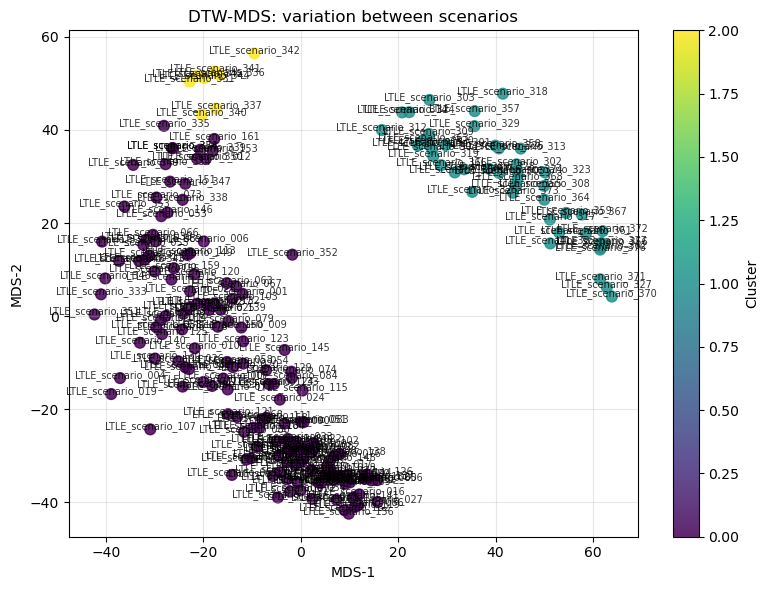

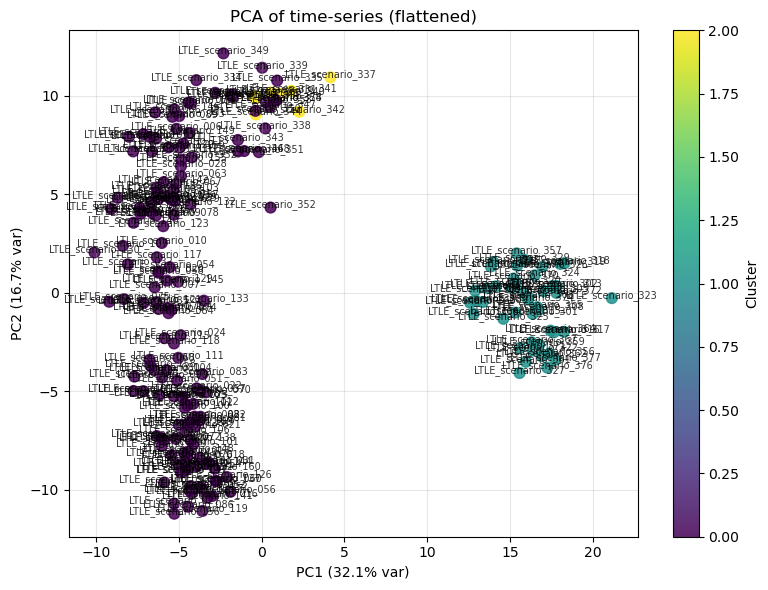


[totcap] CLUSTER SUMMARY
- #clusters: 3
- Cluster sizes: {0: 151, 1: 45, 2: 8}
- Silhouette (DTW, precomputed): 0.412


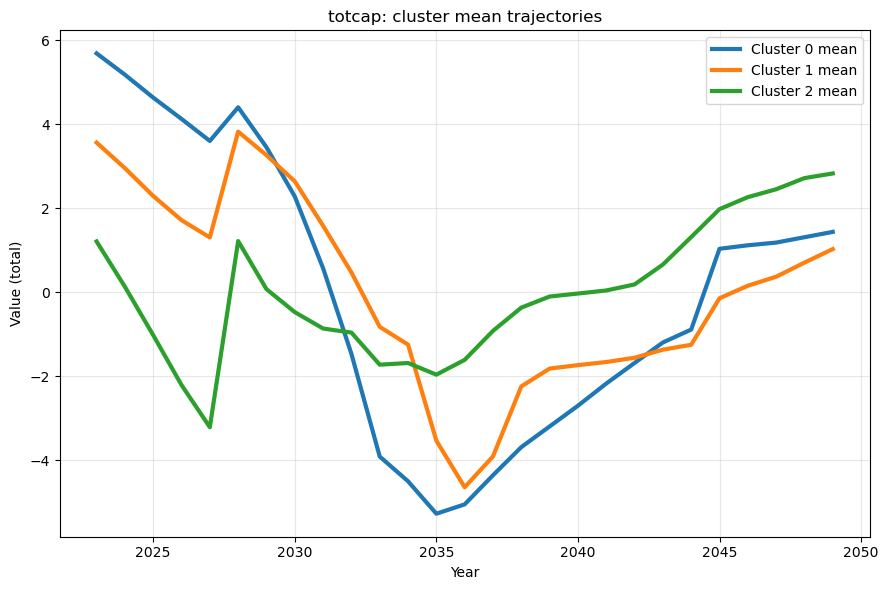

✅ Total capacity DTW done.


In [15]:
print("### Running: Total Capacity (system state) ###")

def load_totcap_df(path: Path):
    if not path.exists():
        print(f"⚠️  Skipping total capacity: file not found at {path}")
        return None, None
    df = pd.read_csv(path)
    if not {"Scenario", "Year"}.issubset(df.columns):
        raise ValueError("Total capacity file must contain 'Scenario' and 'Year' columns.")
    tech_cols = [c for c in df.columns if c not in ("Scenario", "Year")]
    if not tech_cols:
        raise ValueError("No technology columns found in total capacity file.")
    return df, tech_cols

# Load
df_tot, tech_cols_tot = load_totcap_df(TOTCAP_PATH)

sc_in = sorted(df_tot["Scenario"].astype(str).str.strip().unique())
print("Scenarios at entry:", len(sc_in))

if df_tot is not None:
    # Build multivariate time-series cube (N, T, F)
    X3_tot, scenarios_tot, years_tot, colnames_tot = pivot_align_timeseries(
        df_tot, index_col="Scenario", time_col="Year", value_cols=tech_cols_tot, agg="sum"
    )
    # Shape-focused normalization
    X3_tot_norm = znormalize_timeseries(X3_tot)

    # DTW distance matrix (with Sakoe–Chiba band frac = 0.15)
    D_tot = compute_dtw_distance_matrix(X3_tot_norm, band_frac=0.15)

    # Clustering
    labels_tot = agglomerative_from_dist(D_tot, n_clusters=3)

    # DTW–MDS scatter (inline + saved)
    _ = plot_mds_scatter(mds_from_dist(D_tot, random_state=RANDOM_STATE),
                         scenarios_tot, labels_tot, out_prefix="totcap")

    # PCA (color-coded by clusters; inline + saved)
    _ = pca_from_timeseries(X3_tot_norm, scenarios_tot, out_prefix="totcap", labels=labels_tot)

    # Optional stats & visuals (if you added these helpers earlier)
    try:
        _ = summarize_clustering("totcap", D_tot, scenarios_tot, labels_tot)
    except Exception:
        pass
    try:
        _ = plot_cluster_means_only("totcap", X3_tot_norm, years_tot, labels_tot, show_band=False)
    except Exception:
        pass
# Register for end-of-notebook comparison/robustness block (if using RESULTS registry)
    try:
        register_result("totcap", D_tot, labels_tot, scenarios_tot, X3_tot_norm, years_tot, persist=False)
    except Exception:
        pass

    # Save labels
    pd.DataFrame({"Scenario": scenarios_tot, "Cluster": labels_tot}).to_csv(
        OUT_DIR / "totcap_dtw_labels.csv", index=False
    )
    print("✅ Total capacity DTW done.")
else:
    print("⏭️  Total capacity step skipped (file missing).")

In [16]:
# What does Year look like?
print(df_tot["Year"].dtype)
print(df_tot["Year"].astype(str).str[:12].value_counts().head(10))

# Peek at the rows that would be dropped
_probe = df_tot[pd.to_datetime(df_tot["Year"].astype(str).str.strip(), errors="coerce").isna()]
print("Sample bad Year values:")
print(_probe["Year"].astype(str).drop_duplicates().head(20).to_list())


float64
2023.0    408
2037.0    408
2048.0    408
2047.0    408
2046.0    408
2045.0    408
2044.0    408
2043.0    408
2042.0    408
2041.0    408
Name: Year, dtype: int64
Sample bad Year values:
['2023.0', '2024.0', '2025.0', '2026.0', '2027.0', '2028.0', '2029.0', '2030.0', '2031.0', '2032.0', '2033.0', '2034.0', '2035.0', '2036.0', '2037.0', '2038.0', '2039.0', '2040.0', '2041.0', '2042.0']


## Cluster Robustness and Intra-Cluster Variability Analysis


In [17]:
# --- End-of-notebook robustness and variability analysis ---
from sklearn.metrics import silhouette_score

def cluster_medoids(D, labels):
    med = {}
    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue
        subD = D[np.ix_(idx, idx)]
        medoid_local = int(np.argmin(subD.sum(axis=1)))
        med[c] = (int(idx[medoid_local]), idx)
    return med

def intra_stats(D, labels, medoids):
    rows = []
    for c, (midx, idx) in medoids.items():
        d_med = D[idx, midx]
        rows.append({
            "Cluster": c,
            "n_scenarios": int(len(idx)),
            "Mean_DTW_to_Medoid": float(np.mean(d_med)),
            "SD_DTW_to_Medoid": float(np.std(d_med)),
        })
    return pd.DataFrame(rows).sort_values("Cluster")

def robustness_scores(D, labels):
    # internal cohesion vs external separation (mean distances)
    rows = []
    all_idx = np.arange(len(labels))
    for c in sorted(set(labels)):
        in_idx = np.where(labels == c)[0]
        if len(in_idx) == 0:
            continue
        out_idx = np.setdiff1d(all_idx, in_idx)
        intra = float(np.mean(D[np.ix_(in_idx, in_idx)])) if len(in_idx) > 1 else 0.0
        inter = float(np.mean(D[np.ix_(in_idx, out_idx)])) if len(out_idx) > 0 else np.nan
        # normalized compactness w.r.t. max distance
        Dmax = float(np.max(D)) if np.max(D) > 0 else 1.0
        comp_norm = 1.0 - (intra / Dmax)
        # cohesion vs separation
        coh_sep = np.nan
        if inter and inter > 0:
            coh_sep = 1.0 - (intra / inter)
        rows.append({"Cluster": c, "CompactnessNorm": comp_norm, "Cohesion_vs_Separation": coh_sep})
    return pd.DataFrame(rows).sort_values("Cluster")

def summarize_mode(name, bundle, out_dir=OUT_DIR):
    D = bundle["D"]; labels = np.asarray(bundle["labels"]); scenarios = bundle["scenarios"]
    # silhouette on precomputed distances (if ≥2 clusters)
    uniq = sorted(set(labels))
    sil = np.nan
    if len(uniq) >= 2 and len(labels) >= 3:
        try:
            sil = float(silhouette_score(D, labels, metric="precomputed"))
        except Exception:
            pass

    med = cluster_medoids(D, labels)
    df_intra = intra_stats(D, labels, med)
    df_robust = robustness_scores(D, labels)

    # merge tables + global stats
    df = df_intra.merge(df_robust, on="Cluster", how="left")
    df["Silhouette_DTW"] = sil
    df.to_csv(out_dir / f"{name}_cluster_robustness.csv", index=False)

    # distance-to-medoid table
    dist_rows = []
    for c, (midx, idx) in med.items():
        for ii in idx:
            dist_rows.append({"Scenario": scenarios[ii], "Cluster": c, "DistanceToMedoid": float(D[ii, midx])})
    pd.DataFrame(dist_rows).sort_values(["Cluster","DistanceToMedoid"])\
        .to_csv(out_dir / f"{name}_dist_to_medoid.csv", index=False)

    print(f"[{name}] silhouette={sil if not np.isnan(sil) else 'n/a'}")
    display(df)

# Loop over whatever results exist
for mode, bundle in RESULTS.items():
    summarize_mode(mode, bundle, out_dir=OUT_DIR)


[totcap] silhouette=0.4118358175293523


,Cluster,n_scenarios,Mean_DTW_to_Medoid,SD_DTW_to_Medoid,CompactnessNorm,Cohesion_vs_Separation,Silhouette_DTW
0,0,151,28.718350,14.242724,0.599115,0.502150,0.411836
1,1,45,27.953166,10.945911,0.627587,0.546016,0.411836
2,2,8,17.115595,8.056699,0.779315,0.695141,0.411836


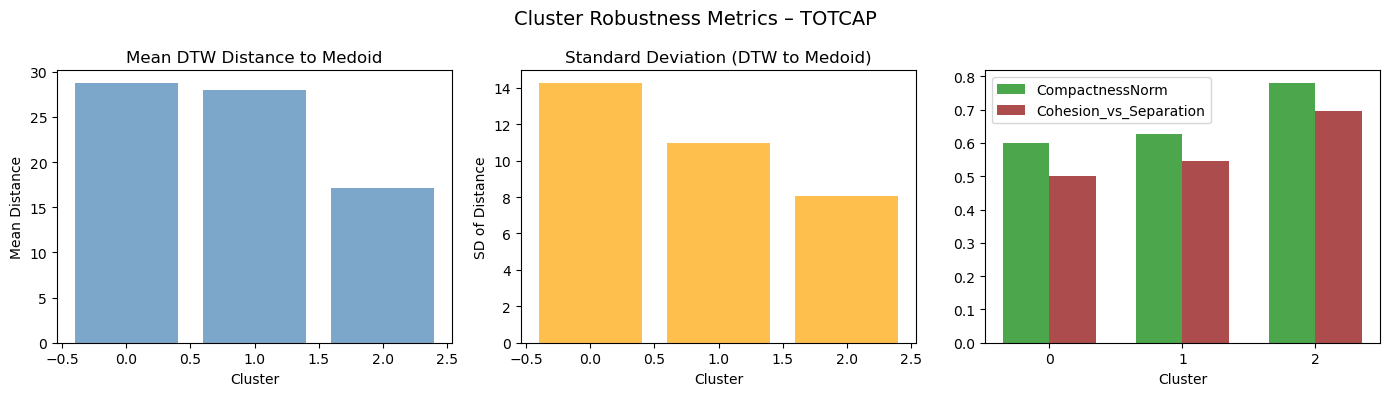

In [18]:
import matplotlib.pyplot as plt

def plot_cluster_metrics(name, out_dir=OUT_DIR):
    fpath = out_dir / f"{name}_cluster_robustness.csv"
    df = pd.read_csv(fpath)
    if df.empty:
        print(f"No data for {name}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Cluster Robustness Metrics – {name.upper()}", fontsize=14)

    # Mean DTW to Medoid
    axes[0].bar(df["Cluster"], df["Mean_DTW_to_Medoid"], color="steelblue", alpha=0.7)
    axes[0].set_title("Mean DTW Distance to Medoid")
    axes[0].set_xlabel("Cluster")
    axes[0].set_ylabel("Mean Distance")

    # Standard deviation
    axes[1].bar(df["Cluster"], df["SD_DTW_to_Medoid"], color="orange", alpha=0.7)
    axes[1].set_title("Standard Deviation (DTW to Medoid)")
    axes[1].set_xlabel("Cluster")
    axes[1].set_ylabel("SD of Distance")

    width = 0.35
    x = np.arange(len(df["Cluster"]))

    axes[2].bar(x - width/2, df["CompactnessNorm"], width, color="green", alpha=0.7, label="CompactnessNorm")
    axes[2].bar(x + width/2, df["Cohesion_vs_Separation"], width, color="darkred", alpha=0.7, label="Cohesion_vs_Separation")

    axes[2].set_xticks(x)
    axes[2].set_xticklabels(df["Cluster"])
    axes[2].set_xlabel("Cluster")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Loop through each variable (mode)
for mode in RESULTS.keys():
    plot_cluster_metrics(mode, out_dir=OUT_DIR)

## Mean Pathways per Cluster
For each cluster, we compute the mean time series (and optionally ±1σ range) of total capacity or investment flows across all scenarios assigned to that cluster.
This shows the "typical" evolution pattern within each cluster — effectively, the archetypal pathway.


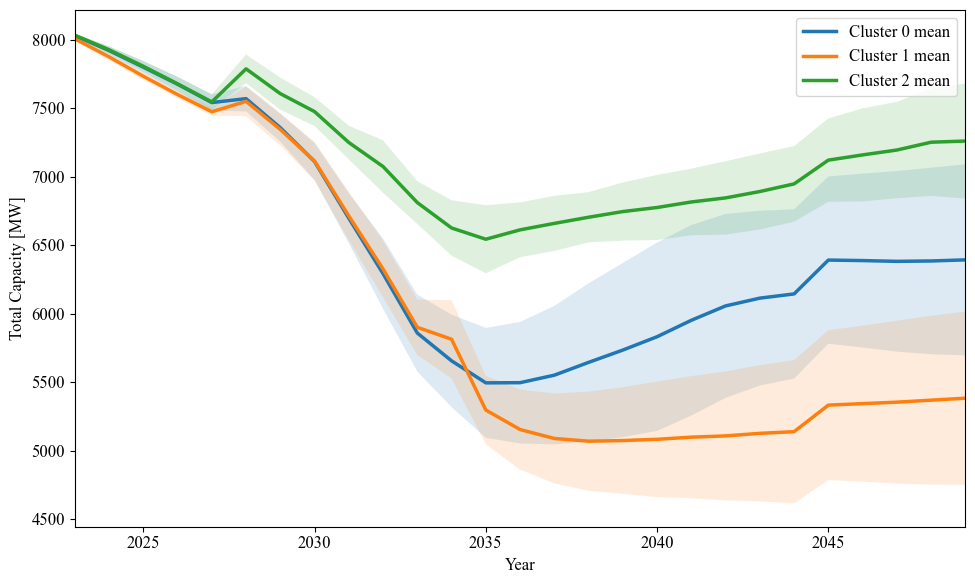

✅ Saved mean pathways → C:\Paper 4\Outputs\Raw\DTW_results\totcap_mean_pathways.csv


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
def compute_mean_pathways(X3, years, labels, prefix, out_dir=OUT_DIR, variable_name="Total Capacity"):
    """
    Compute and plot mean and ±1σ per cluster for total or new capacity trajectories.
    X3: (N, T, F) time-series cube (scenarios × years × techs)
    years: list of years
    labels: cluster labels
    prefix: e.g., 'totcap' or 'newcap'
    variable_name: descriptive label for y-axis (e.g., "Total Capacity [MW]")
    """
    # Collapse across technologies to total per scenario per year
    Y = np.sum(X3, axis=2) if X3.shape[2] > 1 else X3[:, :, 0]
    years = np.asarray(years)

    results = []
    plt.figure(figsize=(10, 6))

    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue
        mu = Y[idx, :].mean(axis=0)
        sd = Y[idx, :].std(axis=0)
        results.append(pd.DataFrame({
            "Year": years,
            "Mean": mu,
            "SD": sd,
            "Cluster": c
        }))

        plt.plot(years, mu, linewidth=2.5, label=f"Cluster {c} mean")
        plt.fill_between(years, mu - sd, mu + sd, alpha=0.15)

    # Plot styling
    plt.xlabel("Year")
    plt.ylabel(f"{variable_name} [MW]")   # Add units
    plt.grid(False)                       # Turn off grid
    plt.legend()
    plt.tight_layout()

    # --- Trick: show full data but limit tick labels to 2045 ---
    
    plt.xlim(min(years), max(years))     # keep the full range visible
    tick_years = [y for y in years if y <= 2045]
    plt.xticks(tick_years)                # only label ticks up to 2045
    plt.xticks(np.arange(2025, 2050, 5))
    plt.show()

    # Save combined dataframe
    df_mean = pd.concat(results, ignore_index=True)
    fpath = out_dir / f"{prefix}_mean_pathways.csv"
    df_mean.to_csv(fpath, index=False)
    print(f"✅ Saved mean pathways → {fpath.resolve()}")
    return df_mean


# Example call for total capacity
df_mean_tot = compute_mean_pathways(X3_tot, years_tot, labels_tot, "totcap", variable_name="Total Capacity")


## Technology-Specific Mean Pathways (Total Capacity)
This section visualizes the mean total capacity per technology for each cluster (archetype).
Each panel shows a stackplot of mean capacities over time across all technologies within that archetype.


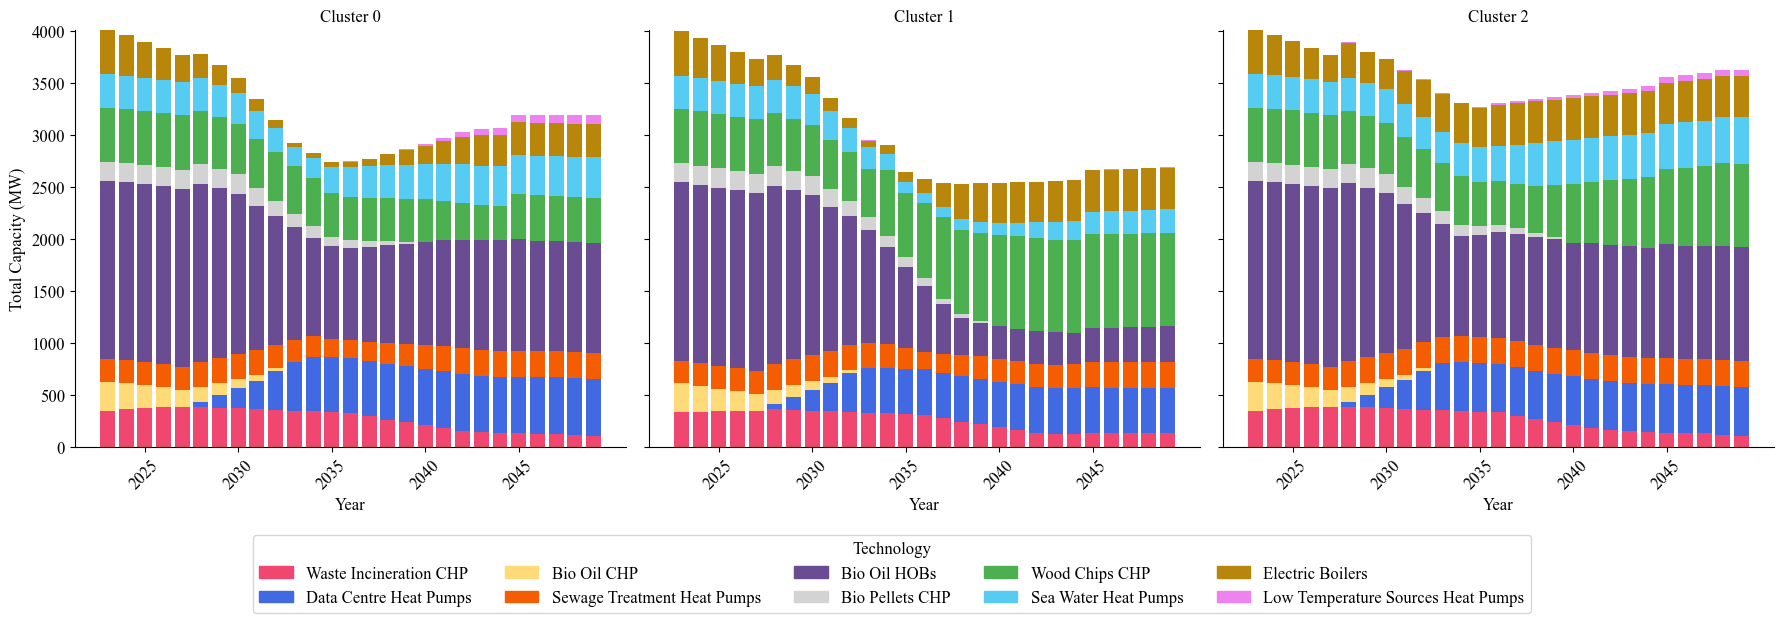

✅ Saved stacked-bar mean total capacity pathways (wide layout, bottom legend) → DTW_results\totcap_mean_paths_by_tech_stacked_row_wide.csv


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
# --- Prepare data ---
df_plot = df_tot.copy()
df_plot["Archetype"] = df_plot["Scenario"].map(dict(zip(scenarios_tot, labels_tot)))

mean_paths_tot = (
    df_plot.groupby(["Archetype", "Year"])[tech_cols_tot]
    .mean()
    .reset_index()
)

# --- Color mapping ---
technology_colors_tot = {
    'Electric Boilers': '#B8860B',
    'Data Centre Heat Pumps': '#4169E1',
    'Bio Oil CHP': '#FFDA79',
    'Bio Oil HOBs': '#6A4C93',
    'Bio Pellets CHP': '#D3D3D3',
    'Sea Water Heat Pumps': '#56CCF2',
    'Sewage Treatment Heat Pumps': '#F45D01',
    'Low Temperature Sources Heat Pumps': '#EE82EE',
    'Waste Incineration CHP': '#EF476F',
    'Wood Chips CHP': '#4CAF50'
}

# --- Single-row subplot layout ---
archetypes = sorted(mean_paths_tot["Archetype"].unique())
n_arch = len(archetypes)

fig, axes = plt.subplots(1, n_arch, figsize=(6 * n_arch, 6), sharey=True)

if n_arch == 1:
    axes = [axes]  # ensure iterable if only one subplot

for i, (arch, ax) in enumerate(zip(archetypes, axes)):
    sub = mean_paths_tot[mean_paths_tot["Archetype"] == arch].sort_values("Year")
    bottom = np.zeros(len(sub))
    for tech in tech_cols_tot:
        vals = sub[tech].to_numpy()
        ax.bar(sub["Year"], vals, bottom=bottom,
               color=technology_colors_tot.get(tech, "#999999"), label=tech)
        bottom += vals

    ax.set_title(f"Cluster {arch}", fontsize=12)
    ax.set_xlabel("Year")
    if i == 0:
        ax.set_ylabel("Total Capacity (MW)")

    # Clean up axes
    ax.set_xticks([y for y in sub["Year"].unique() if y % 5 == 0 and y <= 2045])
    ax.tick_params(axis='x', rotation=45)
    ax.set_facecolor("white")
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(False)

# --- Shared legend at bottom ---
handles = [plt.Rectangle((0, 0), 1, 1, color=technology_colors_tot.get(t, "#999999")) for t in tech_cols_tot]
fig.legend(handles, tech_cols_tot, loc="lower center", ncol=min(len(tech_cols_tot), 5),
           title="Technology", bbox_to_anchor=(0.5, -0.1))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# --- Save output ---
mean_paths_tot.to_csv(OUT_DIR / "totcap_mean_paths_by_tech_stacked_row_wide.csv", index=False)
print(f"✅ Saved stacked-bar mean total capacity pathways (wide layout, bottom legend) → {OUT_DIR / 'totcap_mean_paths_by_tech_stacked_row_wide.csv'}")


## One graph for each cluster

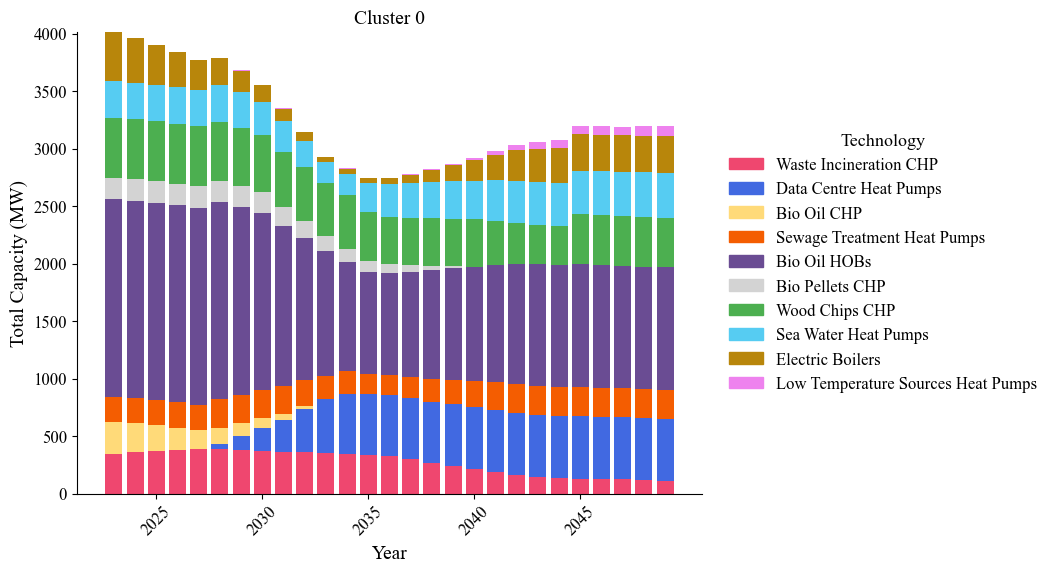

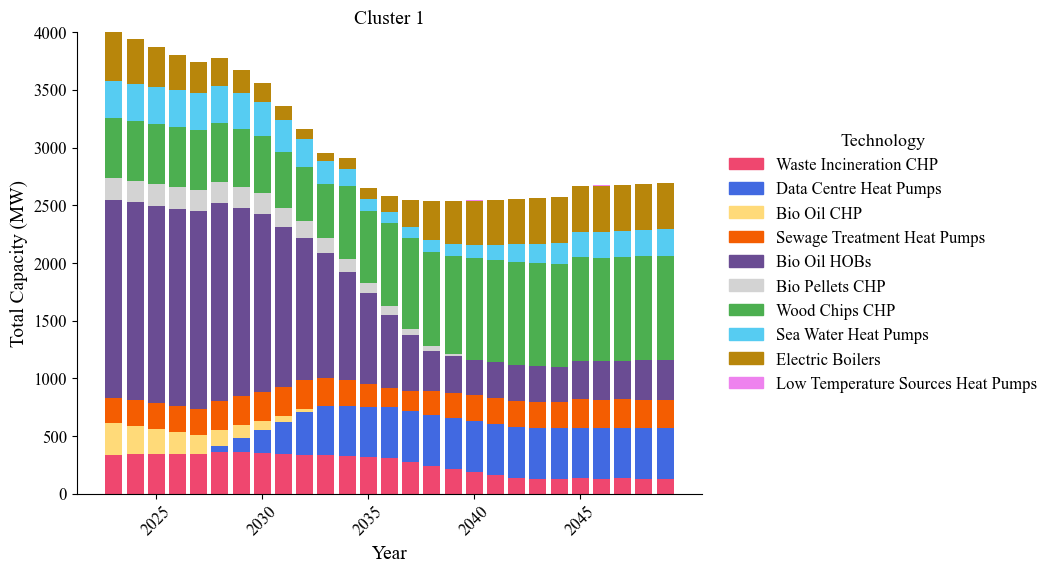

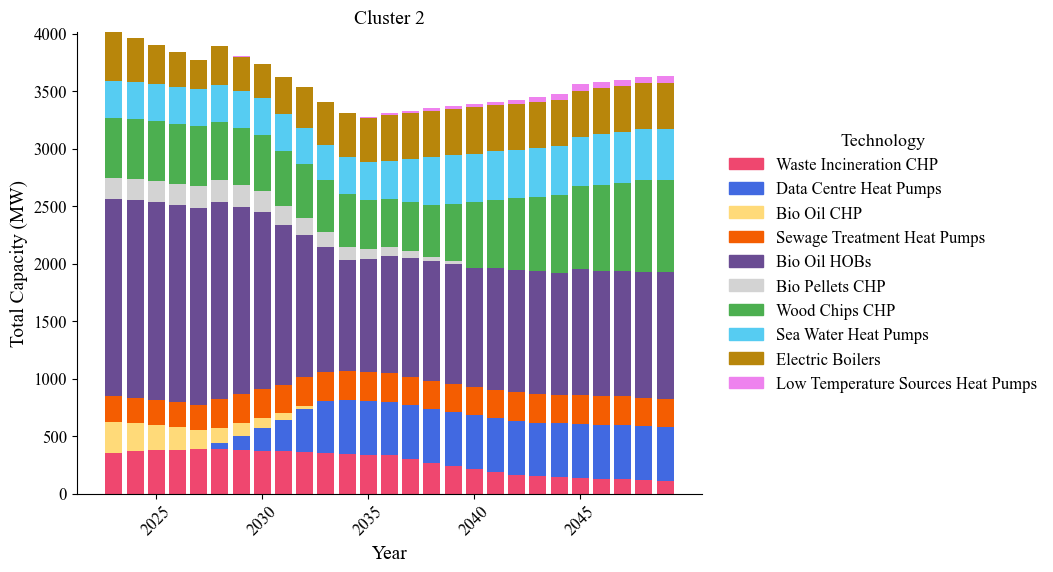

✅ Saved mean total capacity pathways (one figure per cluster, right legend) → DTW_results\totcap_mean_paths_by_tech_stacked_onefig_per_cluster_rightlegend.csv


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Prepare data ---
df_plot = df_tot.copy()
df_plot["Archetype"] = df_plot["Scenario"].map(dict(zip(scenarios_tot, labels_tot)))

mean_paths_tot = (
    df_plot.groupby(["Archetype", "Year"])[tech_cols_tot]
    .mean()
    .reset_index()
)

# --- Color mapping ---
technology_colors_tot = {
    'Electric Boilers': '#B8860B',
    'Data Centre Heat Pumps': '#4169E1',
    'Bio Oil CHP': '#FFDA79',
    'Bio Oil HOBs': '#6A4C93',
    'Bio Pellets CHP': '#D3D3D3',
    'Sea Water Heat Pumps': '#56CCF2',
    'Sewage Treatment Heat Pumps': '#F45D01',
    'Low Temperature Sources Heat Pumps': '#EE82EE',
    'Waste Incineration CHP': '#EF476F',
    'Wood Chips CHP': '#4CAF50'
}

# --- Plot settings (bigger fonts for axes + legend) ---
AXIS_TITLE_FONTSIZE = 14
TICK_FONTSIZE = 12
LEGEND_FONTSIZE = 12
LEGEND_TITLE_FONTSIZE = 13

# --- One figure per cluster, legend aligned vertically on the right ---
archetypes = sorted(mean_paths_tot["Archetype"].unique())

for arch in archetypes:
    sub = mean_paths_tot[mean_paths_tot["Archetype"] == arch].sort_values("Year")

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))  # single plot per cluster

    bottom = np.zeros(len(sub))
    for tech in tech_cols_tot:
        vals = sub[tech].to_numpy()
        ax.bar(
            sub["Year"], vals, bottom=bottom,
            color=technology_colors_tot.get(tech, "#999999"),
            label=tech
        )
        bottom += vals

    # Titles and labels (keep as requested)
    ax.set_title(f"Cluster {arch}", fontsize=AXIS_TITLE_FONTSIZE)
    ax.set_xlabel("Year", fontsize=AXIS_TITLE_FONTSIZE)
    ax.set_ylabel("Total Capacity (MW)", fontsize=AXIS_TITLE_FONTSIZE)

    # X ticks (same logic as your cell)
    ax.set_xticks([y for y in sub["Year"].unique() if y % 5 == 0 and y <= 2045])
    ax.tick_params(axis="x", rotation=45, labelsize=TICK_FONTSIZE)
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

    # Clean up axes
    ax.set_facecolor("white")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(False)

    # Legend: vertical on the right, bigger font
    # Make room on the right for the legend
    fig.subplots_adjust(right=0.75)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=technology_colors_tot.get(t, "#999999"))
        for t in tech_cols_tot
    ]
    ax.legend(
        handles, tech_cols_tot,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        ncol=1,
        title="Technology",
        fontsize=LEGEND_FONTSIZE,
        title_fontsize=LEGEND_TITLE_FONTSIZE
    )

    plt.show()

# --- Save output (same as before) ---
mean_paths_tot.to_csv(OUT_DIR / "totcap_mean_paths_by_tech_stacked_onefig_per_cluster_rightlegend.csv", index=False)
print(
    "✅ Saved mean total capacity pathways (one figure per cluster, right legend) → "
    f"{OUT_DIR / 'totcap_mean_paths_by_tech_stacked_onefig_per_cluster_rightlegend.csv'}"
)

## Technology-Specific Mean Pathways (Accumulated New Capacity – Single Row, Bottom Legend)
This visualization shows mean accumulated new capacity by technology for each cluster (archetype),
displayed as stacked bar charts side by side. 
The figure includes a bottom legend and x-axis labels every 5 years up to 2045.


## Build Accumulated new capacity investment plans wide and long

In [22]:
# === Paths and file setup ===
ROOT = Path(".")
FILES = {
    "accumulated": "AccumulatedNewCapacity.csv",
    "newcap": "NewCapacity.csv"
}
PATTERNS = ["LTLE_Scenario_*", "LTLE_scenario_*"]

# === Mapping of detailed technology names to aggregated categories ===
NAMES = {
    'Waste Incineration CHP': ['BristaB2', 'HgldP3468', 'LSVTACHP'],
    'Data Centre Heat Pumps': ['DCACC'],
    'Bio Oil CHP': ['KVV1'],
    'Sewage Treatment Heat Pumps': ['HmrbySEWHP'],
    'Bio Oil HOBs': ['DECFOHOB', 'CSBOHOB'],
    'Bio Pellets CHP': ['HslbyP1toP3'],
    'Wood Chips CHP': ['BristaB1', 'KVV8'],
    'Sea Water Heat Pumps': ['VVNHP'],
    'Electric Boilers': ['VVHVELHOB'],
    'Low Temperature Sources Heat Pumps': ['SUPACC'],
}

# === Helper function to load and group one file per scenario ===
def load_and_group(scen_dir: Path, fname: str):
    csv_path = scen_dir / fname
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    if not {"YEAR", "TECHNOLOGY", "VALUE"}.issubset(df.columns):
        return None
    tech_keep = {t for ts in NAMES.values() for t in ts}
    df = df[df["TECHNOLOGY"].isin(tech_keep)].copy()
    if df.empty:
        return None

    # Pivot: technology columns per year
    piv = df.pivot_table(values="VALUE", index="YEAR", columns="TECHNOLOGY", aggfunc="sum").fillna(0.0)

    # Group by broader technology categories
    grouped = pd.DataFrame(index=piv.index)
    for cat, techs in NAMES.items():
        cols_present = [c for c in techs if c in piv.columns]
        grouped[cat] = piv[cols_present].sum(axis=1) if cols_present else 0.0

    grouped = grouped.reset_index().rename(columns={"YEAR": "Year"})
    grouped["Scenario"] = scen_dir.name
    return grouped

# === Find all scenario directories ===
scen_dirs = []
for pat in PATTERNS:
    scen_dirs += [d for d in ROOT.glob(pat) if d.is_dir()]
scen_dirs = sorted(scen_dirs)

if not scen_dirs:
    raise RuntimeError("No scenario directories found. Check LTLE_Scenario_* folders.")

# === Process both Accumulated and NewCapacity for each scenario ===
results = {"accumulated": [], "newcap": []}

for scen in scen_dirs:
    for key, fname in FILES.items():
        g = load_and_group(scen, fname)
        if g is not None:
            results[key].append(g)

# === Save outputs ===
out_dir = ROOT / "aggregates"
out_dir.mkdir(exist_ok=True)

for key in ["accumulated", "newcap"]:
    if not results[key]:
        print(f"No data found for {key} files — skipping.")
        continue

    df_wide = pd.concat(results[key], ignore_index=True)
    df_long = df_wide.melt(id_vars=["Scenario", "Year"], var_name="Category", value_name="Capacity_MW")

    idx = df_wide.groupby("Scenario")["Year"].idxmax()
    snapshot_last = df_wide.loc[idx].reset_index(drop=True)

    suffix = "" if key == "accumulated" else "_newcap"

    df_wide.to_csv(out_dir / f"investment_plans_wide{suffix}.csv", index=False)
    df_long.to_csv(out_dir / f"investment_plans_long{suffix}.csv", index=False)
    snapshot_last.to_csv(out_dir / f"investment_snapshot_lastyear{suffix}.csv", index=False)

    print(f"Saved {key} data → investment_plans_wide{suffix}.csv, investment_long{suffix}.csv, snapshot{suffix}.csv")

print(f"\n✅ Processed {len(scen_dirs)} scenario folders successfully.")


Saved accumulated data → investment_plans_wide.csv, investment_long.csv, snapshot.csv
Saved newcap data → investment_plans_wide_newcap.csv, investment_long_newcap.csv, snapshot_newcap.csv

✅ Processed 408 scenario folders successfully.


In [23]:
from pathlib import Path
import pandas as pd

# Path to your accumulated new capacity file
ACCUM_PATH = Path("aggregates/investment_plans_wide.csv")

def load_accum_df(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Accumulated new capacity file not found: {path}")
    df = pd.read_csv(path)
    if not {"Scenario", "Year"}.issubset(df.columns):
        raise ValueError("File must contain 'Scenario' and 'Year' columns.")
    tech_cols = [c for c in df.columns if c not in ("Scenario", "Year")]
    return df, tech_cols

# Load data
df_acc, tech_cols_acc = load_accum_df(ACCUM_PATH)

# Load clustering results (from your DTW outputs)
labels_acc = pd.read_csv(OUT_DIR / "accumulated_dtw_labels.csv")["Cluster"].to_numpy()
scenarios_acc = pd.read_csv(OUT_DIR / "accumulated_dtw_labels.csv")["Scenario"].to_numpy()

print(f"✅ Loaded accumulated new capacity dataset with {len(scenarios_acc)} scenarios and {len(tech_cols_acc)} technologies.")


✅ Loaded accumulated new capacity dataset with 153 scenarios and 10 technologies.


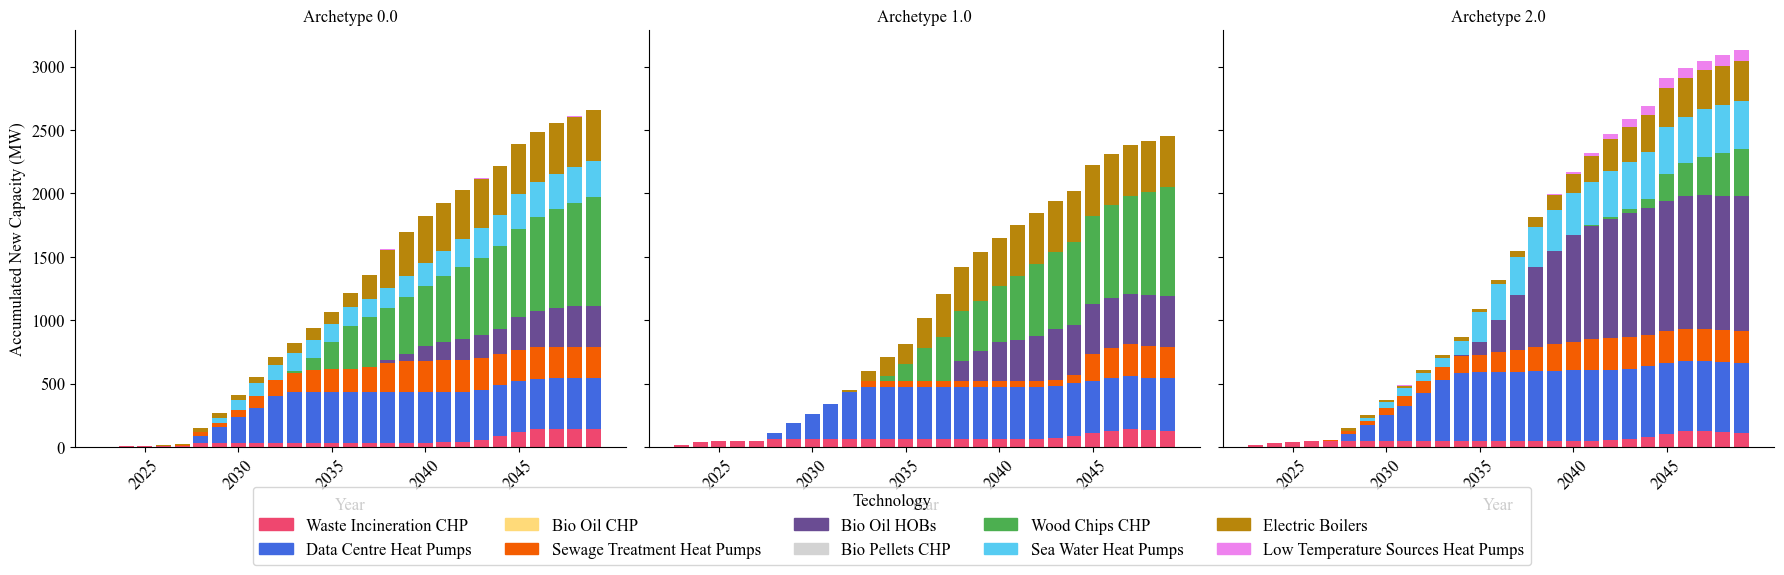

✅ Saved stacked-bar mean accumulated new capacity pathways (wide layout, bottom legend) → DTW_results\accumulated_newcap_mean_paths_by_tech_stacked_row.csv


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Prepare data ---
df_plot = df_acc.copy()
df_plot["Archetype"] = df_plot["Scenario"].map(dict(zip(scenarios_acc, labels_acc)))

mean_paths_acc = (
    df_plot.groupby(["Archetype", "Year"])[tech_cols_acc]
    .mean()
    .reset_index()
)

# --- Color mapping (same as before for consistency) ---
technology_colors_acc = {
    'Electric Boilers': '#B8860B',
    'Data Centre Heat Pumps': '#4169E1',
    'Bio Oil CHP': '#FFDA79',
    'Bio Oil HOBs': '#6A4C93',
    'Bio Pellets CHP': '#D3D3D3',
    'Sea Water Heat Pumps': '#56CCF2',
    'Sewage Treatment Heat Pumps': '#F45D01',
    'Low Temperature Sources Heat Pumps': '#EE82EE',
    'Waste Incineration CHP': '#EF476F',
    'Wood Chips CHP': '#4CAF50'
}

# --- Single-row subplot layout ---
archetypes = sorted(mean_paths_acc["Archetype"].unique())
n_arch = len(archetypes)

fig, axes = plt.subplots(1, n_arch, figsize=(6 * n_arch, 6), sharey=True)

if n_arch == 1:
    axes = [axes]

for i, (arch, ax) in enumerate(zip(archetypes, axes)):
    sub = mean_paths_acc[mean_paths_acc["Archetype"] == arch].sort_values("Year")
    bottom = np.zeros(len(sub))
    for tech in tech_cols_acc:
        vals = sub[tech].to_numpy()
        ax.bar(sub["Year"], vals, bottom=bottom,
               color=technology_colors_acc.get(tech, "#999999"), label=tech)
        bottom += vals

    ax.set_title(f"Archetype {arch}", fontsize=12)
    ax.set_xlabel("Year")
    if i == 0:
        ax.set_ylabel("Accumulated New Capacity (MW)")

    # Show ticks only every 5 years up to 2045
    ax.set_xticks([y for y in sub["Year"].unique() if y % 5 == 0 and y <= 2045])
    ax.tick_params(axis='x', rotation=45)

    ax.set_facecolor("white")
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(False)

# --- Shared legend at bottom ---
handles = [plt.Rectangle((0, 0), 1, 1, color=technology_colors_acc.get(t, "#999999")) for t in tech_cols_acc]
fig.legend(handles, tech_cols_acc, loc="lower center", ncol=min(len(tech_cols_acc), 5),
           title="Technology", bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# --- Save output ---
mean_paths_acc.to_csv(OUT_DIR / "accumulated_newcap_mean_paths_by_tech_stacked_row.csv", index=False)
print(f"✅ Saved stacked-bar mean accumulated new capacity pathways (wide layout, bottom legend) → {OUT_DIR / 'accumulated_newcap_mean_paths_by_tech_stacked_row.csv'}")

## Annual Heat Generation: Data Preparation
This section loads annual heat generation (`ProdByTechAnn.csv`) from all scenario folders,
maps detailed technologies to consistent categories, and constructs a long-format dataframe
(`Scenario`, `Year`, `Technology`, `GWh`).


In [25]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

# --- Paths and configuration ---
ROOT = Path(".")  # base directory containing LTLE_scenario_* folders
FNAME = "ProdByTechAnn.csv"
OUT_PATH = Path("aggregates/heat_generation_long.csv")
YEARS = list(range(2023, 2050))
GWH_FACTOR = 0.27777778  # TJ -> GWh

# Mapping of detailed technologies to categories
TECH_MAP = {
    'Waste Incineration CHP': ['BristaB2', 'HgldP3468', 'LSVTACHP'],
    'Data Centre Heat Pumps': ['DCACC'],
    'Bio Oil CHP': ['KVV1'],
    'Bio Oil HOBs': ['DECFOHOB', 'CSBOHOB'],
    'Bio Pellets CHP': ['HslbyP1toP3'],
    'Wood Chips CHP': ['BristaB1', 'KVV8'],
    'Sea Water Heat Pumps': ['VVNHP'],
    'Sewage Treatment Heat Pumps': ['HmrbySEWHP', 'SEWACC'],
    'Electric Boilers': ['VVHVELHOB'],
    'Low Temperature Sources Heat Pumps': ['SUPACC'],
}

# --- Helper to read and map each scenario ---
def load_one_heat_csv(path_csv: Path, scen_name: str) -> pd.DataFrame:
    df = pd.read_csv(path_csv)
    if not {"YEAR", "TECHNOLOGY", "FUEL", "VALUE"}.issubset(df.columns):
        raise ValueError(f"{path_csv.name} missing required columns.")
    
    df = df[df["FUEL"].str.contains("CONVHEAT", case=False, na=False)].copy()
    df = df[~df["TECHNOLOGY"].str.contains("DHN", na=False)].copy()

    # pivot to wide format (Year × Technology)
    piv = df.pivot_table(values="VALUE", index="YEAR", columns="TECHNOLOGY", aggfunc="sum").fillna(0.0)
    piv *= GWH_FACTOR  # convert TJ to GWh

    # aggregate by mapped categories
    grouped = pd.DataFrame(index=piv.index)
    for cat, techs in TECH_MAP.items():
        existing = [t for t in techs if t in piv.columns]
        grouped[cat] = piv[existing].sum(axis=1) if existing else 0.0

    grouped = grouped.reindex(YEARS).fillna(0.0).reset_index().rename(columns={"YEAR": "Year"})
    grouped["Scenario"] = scen_name
    return grouped

# --- Loop over scenario folders ---
scen_dirs = sorted([p for p in ROOT.glob("LTLE_scenario_*") if p.is_dir()])
if not scen_dirs:
    raise RuntimeError("⚠️ No LTLE_scenario_* folders found under current directory.")

heat_dfs = []
for scen_dir in scen_dirs:
    csv_path = scen_dir / FNAME
    if not csv_path.exists():
        print(f"⚠️ Skipping {scen_dir.name}: missing {FNAME}")
        continue
    try:
        df_one = load_one_heat_csv(csv_path, scen_dir.name)
        heat_dfs.append(df_one)
    except Exception as e:
        print(f"⚠️ Error reading {scen_dir.name}: {e}")

if not heat_dfs:
    raise RuntimeError("⚠️ No valid ProdByTechAnn.csv files found.")

# --- Combine & save ---
heat_all = pd.concat(heat_dfs, ignore_index=True)
heat_long = heat_all.melt(id_vars=["Scenario", "Year"], var_name="Technology", value_name="GWh") \
                    .sort_values(["Scenario", "Year", "Technology"])
Path("aggregates").mkdir(exist_ok=True)
heat_long.to_csv(OUT_PATH, index=False)

print(f"✅ Saved: {OUT_PATH.resolve()}")
print(f"Scenarios: {heat_long['Scenario'].nunique()} | Technologies: {heat_long['Technology'].nunique()} | Years: {heat_long['Year'].nunique()}")

✅ Saved: C:\Paper 4\Outputs\Raw\aggregates\heat_generation_long.csv
Scenarios: 204 | Technologies: 10 | Years: 27


## Mean Annual Heat Generation Pathways by Archetype
This section visualizes the mean annual heat generation by technology 
for each DTW-based cluster (archetype). Each cluster’s average trajectory 
is shown as a stacked area plot, highlighting the evolving contribution 
of each technology to total heat generation over time.

In [26]:
# --- STRUCTURE MEAN ANNUAL HEAT GENERATION BY CLUSTER (FROM TOTAL CAPACITY CLUSTERS) ---
import pandas as pd
from pathlib import Path

# Paths
HEAT_PATH = Path("aggregates/heat_generation_long.csv")
LABEL_PATH = Path("DTW_results/totcap_dtw_labels.csv")
OUT_MEAN_HEAT = Path("DTW_results/mean_heat_pathways_archetype_wide.csv")

# Load data
df_heat = pd.read_csv(HEAT_PATH)
labels = pd.read_csv(LABEL_PATH)

# Map clusters (reuse total capacity DTW clusters)
scen_to_cluster = dict(zip(labels["Scenario"], labels["Cluster"]))
df_heat["Archetype"] = df_heat["Scenario"].map(scen_to_cluster)

# Group by archetype, year, and technology
mean_heat = (
    df_heat.groupby(["Archetype", "Year", "Technology"])["GWh"]
    .mean()
    .reset_index()
)

# Pivot to wide format: Archetype × Year × Technology
mean_wide = mean_heat.pivot_table(
    index=["Archetype", "Year"], columns="Technology", values="GWh", aggfunc="mean"
).fillna(0.0)

desired_order = [tech for tech in TECH_MAP.keys() if tech in mean_wide.columns]
mean_wide = mean_wide[desired_order]

# Save for plotting
OUT_MEAN_HEAT.parent.mkdir(exist_ok=True, parents=True)
mean_wide.to_csv(OUT_MEAN_HEAT)

print(f"✅ Saved mean annual heat generation per cluster → {OUT_MEAN_HEAT}")
print(f"Shape: {mean_wide.shape[0]} rows × {mean_wide.shape[1]} technologies")


✅ Saved mean annual heat generation per cluster → DTW_results\mean_heat_pathways_archetype_wide.csv
Shape: 81 rows × 10 technologies


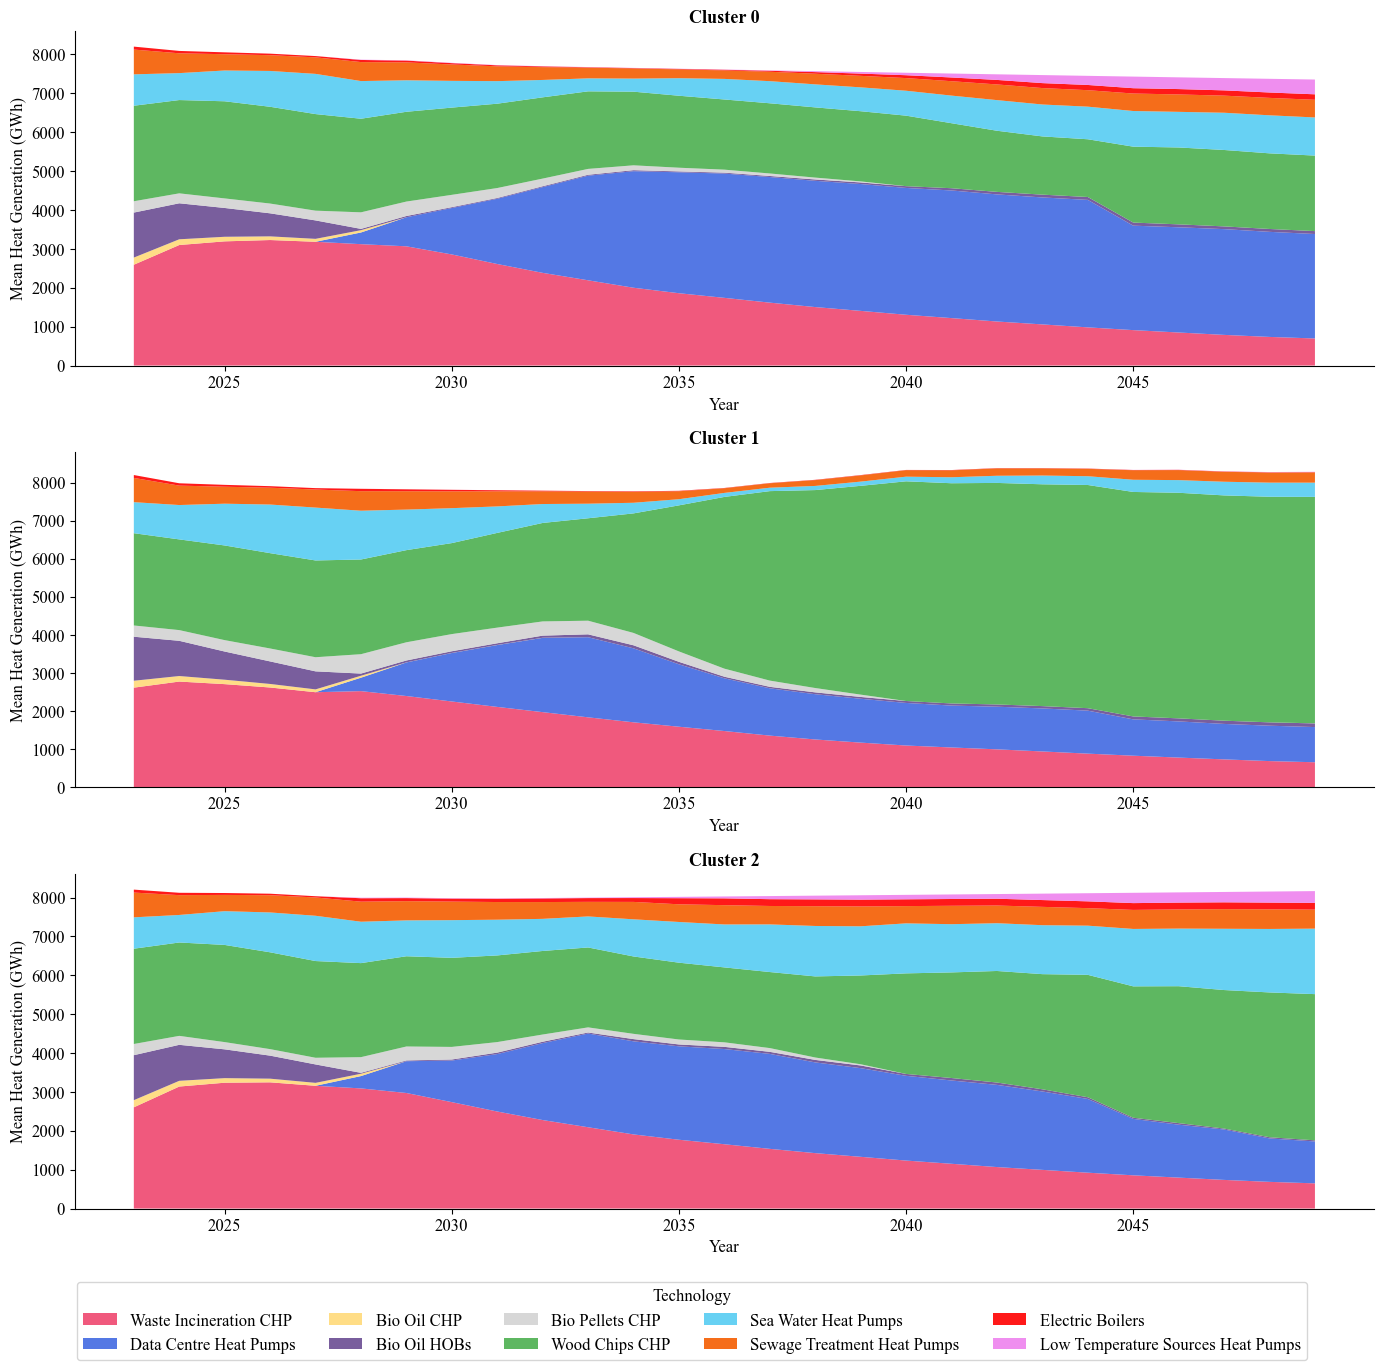

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
# Load aggregated data
mean_wide = pd.read_csv("DTW_results/mean_heat_pathways_archetype_wide.csv", index_col=[0,1])

# Color palette
technology_colors = {
    'Electric Boilers': '#FF0000',
    'Data Centre Heat Pumps': '#4169E1',
    'Bio Oil CHP': '#FFDA79',
    'Bio Oil HOBs': '#6A4C93',
    'Bio Pellets CHP': '#D3D3D3',
    'Sea Water Heat Pumps': '#56CCF2',
    'Sewage Treatment Heat Pumps': '#F45D01',
    'Low Temperature Sources Heat Pumps': '#EE82EE',
    'Waste Incineration CHP': '#EF476F',
    'Wood Chips CHP': '#4CAF50'
}

# Desired plotting order (bottom → top)
TECH_MAP = {
    'Waste Incineration CHP': ['BristaB2', 'HgldP3468', 'LSVTACHP'],
    'Data Centre Heat Pumps': ['DCACC'],
    'Bio Oil CHP': ['KVV1'],
    'Bio Oil HOBs': ['DECFOHOB', 'CSBOHOB'],
    'Bio Pellets CHP': ['HslbyP1toP3'],
    'Wood Chips CHP': ['BristaB1', 'KVV8'],
    'Sea Water Heat Pumps': ['VVNHP'],
    'Sewage Treatment Heat Pumps': ['HmrbySEWHP', 'SEWACC'],
    'Electric Boilers': ['VVHVELHOB'],
    'Low Temperature Sources Heat Pumps': ['SUPACC'],
}

# Reorder dataframe columns
desired_order = [tech for tech in TECH_MAP.keys() if tech in mean_wide.columns]
mean_wide = mean_wide[desired_order]

# Extract archetypes
archetypes = mean_wide.index.get_level_values(0).unique()
n_arch = len(archetypes)

# --- Create vertical subplots (1 column, multiple rows) ---
fig, axes = plt.subplots(n_arch, 1, figsize=(14, 4.5 * n_arch), sharex=False)
if n_arch == 1:
    axes = [axes]

for ax, arch in zip(axes, archetypes):
    sub = mean_wide.loc[arch].sort_index()

    ax.stackplot(
        sub.index,
        *[sub[c] for c in desired_order if c in sub.columns],
        colors=[technology_colors[c] for c in desired_order if c in sub.columns],
        alpha=0.9
    )

    # Classic x-axis with years on EACH subplot
    year_ticks = [y for y in sub.index if y % 5 == 0 and y <= 2045]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([str(y) for y in year_ticks])
    ax.set_xlabel("Year")  # label on each axis

    # (keep your existing styling)
    ax.set_title(f"Cluster {arch}", fontsize=13, weight="bold")
    ax.set_ylabel("Mean Heat Generation (GWh)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor("white")

# Legend unchanged
fig.legend(
    desired_order,
    loc="lower center",
    ncol=5,
    title="Technology",
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


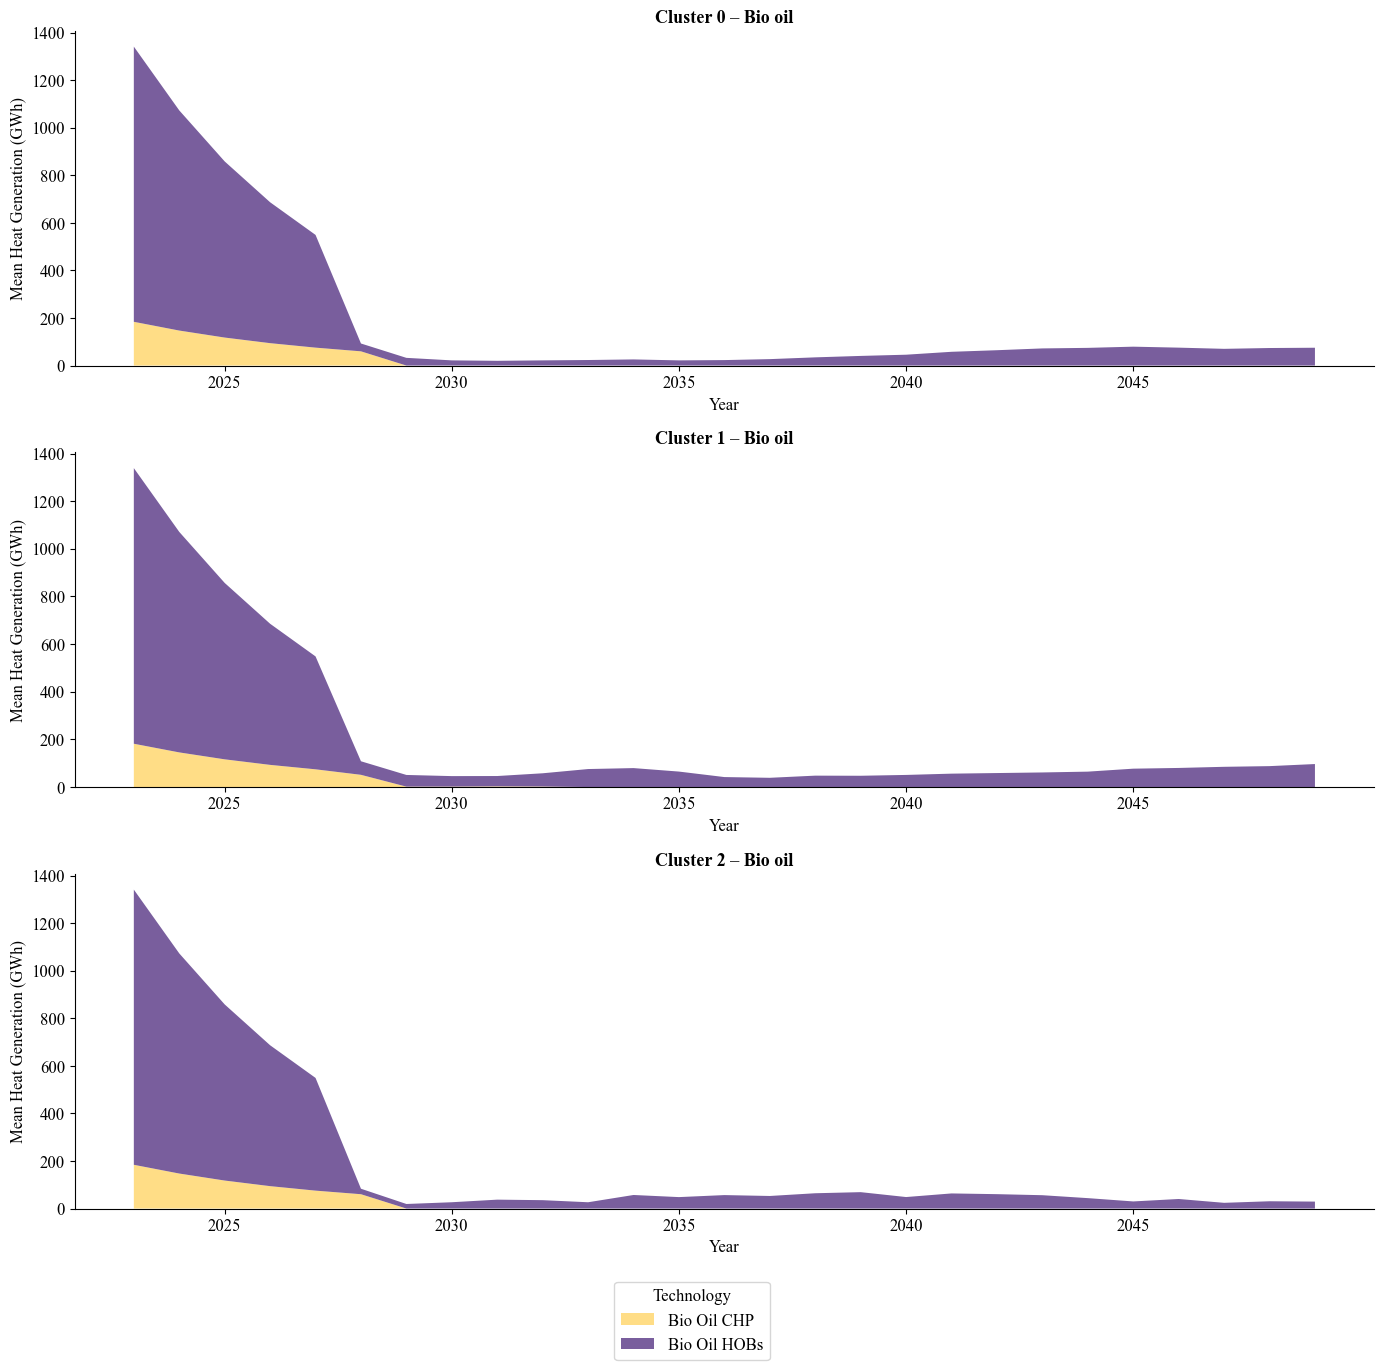

In [28]:
# Filter to only include "bio oil"
desired_order = [c for c in mean_wide.columns if "bio oil" in c.lower()]

# Extract archetypes
archetypes = mean_wide.index.get_level_values(0).unique()
n_arch = len(archetypes)

# --- Create vertical subplots (1 column, multiple rows) ---
fig, axes = plt.subplots(n_arch, 1, figsize=(14, 4.5 * n_arch), sharex=False)
if n_arch == 1:
    axes = [axes]

for ax, arch in zip(axes, archetypes):
    sub = mean_wide.loc[arch].sort_index()

    # Plot only "bio oil"
    ax.stackplot(
        sub.index,
        *[sub[c] for c in desired_order if c in sub.columns],
        colors=[technology_colors[c] for c in desired_order if c in sub.columns],
        alpha=0.9
    )

    # X-axis ticks (years)
    year_ticks = [y for y in sub.index if y % 5 == 0 and y <= 2045]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([str(y) for y in year_ticks])
    ax.set_xlabel("Year")

    # Styling
    ax.set_title(f"Cluster {arch} – Bio oil", fontsize=13, weight="bold")
    ax.set_ylabel("Mean Heat Generation (GWh)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor("white")

# Legend for Bio oil only
fig.legend(
    desired_order,
    loc="lower center",
    ncol=1,
    title="Technology",
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## Data Structuring for LCOH distribution by existing total-capacity clusters

In [29]:
# --- Generate LCOH time series per scenario (MSEK/TJ → SEK/kWh) ---
from pathlib import Path
import pandas as pd
import re

PROJECT_ROOT = Path(".")          # folder that contains LTLE_scenario_001, _002, ...
OUT_DIR = Path("analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# robust match for folder names like LTLE_scenario_001 (tolerates minor typos)
_SCEN_RE = re.compile(r"""
    ^ltle[_\-\s]?
    (?:s(?:c(?:e|a)?a?n?a?r?i?o)|scenario) # tolerate typos
    [_\-\s]?(\d+)$
""", re.IGNORECASE | re.VERBOSE)

def scenario_id_from_path(p: Path):
    m = _SCEN_RE.search(p.name)
    return int(m.group(1)) if m else p.name

def is_scenario_dir(p: Path) -> bool:
    return p.is_dir() and _SCEN_RE.search(p.name) is not None

rows = []
scen_dirs = sorted([p for p in PROJECT_ROOT.iterdir() if is_scenario_dir(p)],
                   key=lambda p: scenario_id_from_path(p))

for sdir in scen_dirs:
    sid = scenario_id_from_path(sdir)

    prod_path = sdir / "ProdByTechAnn.csv"
    cost_path = sdir / "TotDiscCostByTech.csv"
    if not (prod_path.exists() and cost_path.exists()):
        print(f"• skip {sdir.name}: missing required CSV(s)")
        continue

    # --- Load costs: sum positive discounted cost per YEAR ---
    cost = pd.read_csv(cost_path)
    cost["YEAR"] = pd.to_numeric(cost["YEAR"], errors="coerce")
    cost["VALUE"] = pd.to_numeric(cost["VALUE"], errors="coerce")
    cost = cost.dropna(subset=["YEAR", "VALUE"])
    cost_pos = cost.loc[cost["VALUE"] > 0]
    cost_by_year = (
        cost_pos.groupby("YEAR", as_index=False)["VALUE"]
        .sum()
        .rename(columns={"VALUE": "COST_MSEK"})
    )

    # --- Load production: filter heat rows (FUEL contains 'CONVHEAT'), sum per YEAR ---
    prod = pd.read_csv(prod_path)
    prod["YEAR"] = pd.to_numeric(prod["YEAR"], errors="coerce")
    prod["VALUE"] = pd.to_numeric(prod["VALUE"], errors="coerce")
    prod = prod.dropna(subset=["YEAR", "VALUE"])

    fuel_col = "FUEL" if "FUEL" in prod.columns else None
    if fuel_col is None:
        print(f"• warn {sdir.name}: no FUEL column, cannot isolate DHN heat; skipping")
        continue

    mask_heat = prod[fuel_col].astype(str).str.contains("CONVHEAT", case=False, na=False)
    heat_by_year = (
        prod.loc[mask_heat]
            .groupby("YEAR", as_index=False)["VALUE"]
            .sum()
            .rename(columns={"VALUE": "HEAT_TJ"})
    )

    # --- Join & compute LCOH (MSEK/TJ → SEK/kWh; factor = 3.6) ---
    df = pd.merge(cost_by_year, heat_by_year, on="YEAR", how="inner")
    if df.empty:
        print(f"• warn {sdir.name}: no overlapping YEAR between cost & heat; skipping")
        continue

    df["LCOH_SEK_per_kWh"] = (df["COST_MSEK"] / df["HEAT_TJ"]) * 3.6
    df.insert(0, "Scenario", sid)
    rows.append(df[["Scenario", "YEAR", "LCOH_SEK_per_kWh"]])

if not rows:
    print("No per-year LCOH could be computed from any scenario.")
else:
    out = (pd.concat(rows, ignore_index=True)
             .sort_values(["Scenario", "YEAR"])
             .reset_index(drop=True))
    out_path = OUT_DIR / "lcoh_timeseries.csv"
    out.to_csv(out_path, index=False)
    print(f"✅ Saved per-year LCOH time series → {out_path.resolve()}")


✅ Saved per-year LCOH time series → C:\Paper 4\Outputs\Raw\analysis\lcoh_timeseries.csv


In [30]:
# --- STRUCTURE LCOH TIME SERIES BY EXISTING TOTAL-CAPACITY CLUSTERS ---
import pandas as pd
from pathlib import Path

# Paths
LCOH_PATH = Path("analysis/lcoh_timeseries.csv")
LABEL_PATH = Path("DTW_results/totcap_dtw_labels.csv")
OUT_MERGED = Path("DTW_results/lcoh_by_cluster.csv")
OUT_STATS = Path("DTW_results/lcoh_cluster_summary.csv")

# --- Load data ---
df_lcoh = pd.read_csv(LCOH_PATH)
labels = pd.read_csv(LABEL_PATH)

# --- Clean and align column names ---
df_lcoh.columns = [c.strip() for c in df_lcoh.columns]
df_lcoh.rename(columns={"YEAR": "Year"}, inplace=True)

# Normalize scenario IDs in labels
labels["Scenario"] = labels["Scenario"].astype(str).str.extract(r"(\d+)").astype(int)

scen_to_cluster = dict(zip(labels["Scenario"], labels["Cluster"]))

# --- Merge cluster labels ---
scen_to_cluster = dict(zip(labels["Scenario"], labels["Cluster"]))
df_lcoh["Cluster"] = df_lcoh["Scenario"].map(scen_to_cluster)

# Drop scenarios not in clusters
df_lcoh = df_lcoh.dropna(subset=["Cluster"])

# --- Compute statistics per cluster per year ---
summary = (
    df_lcoh.groupby(["Cluster", "Year"])["LCOH_SEK_per_kWh"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
summary["cv"] = summary["std"] / summary["mean"]

# --- Save ---
OUT_MERGED.parent.mkdir(parents=True, exist_ok=True)
df_lcoh.to_csv(OUT_MERGED, index=False)
summary.to_csv(OUT_STATS, index=False)

print(f"✅ Saved merged LCOH-by-cluster data → {OUT_MERGED}")
print(f"✅ Saved LCOH cluster summary stats → {OUT_STATS}")
print(f"Shape: {summary.shape[0]} rows × {summary.shape[1]} columns")

✅ Saved merged LCOH-by-cluster data → DTW_results\lcoh_by_cluster.csv
✅ Saved LCOH cluster summary stats → DTW_results\lcoh_cluster_summary.csv
Shape: 81 rows × 7 columns


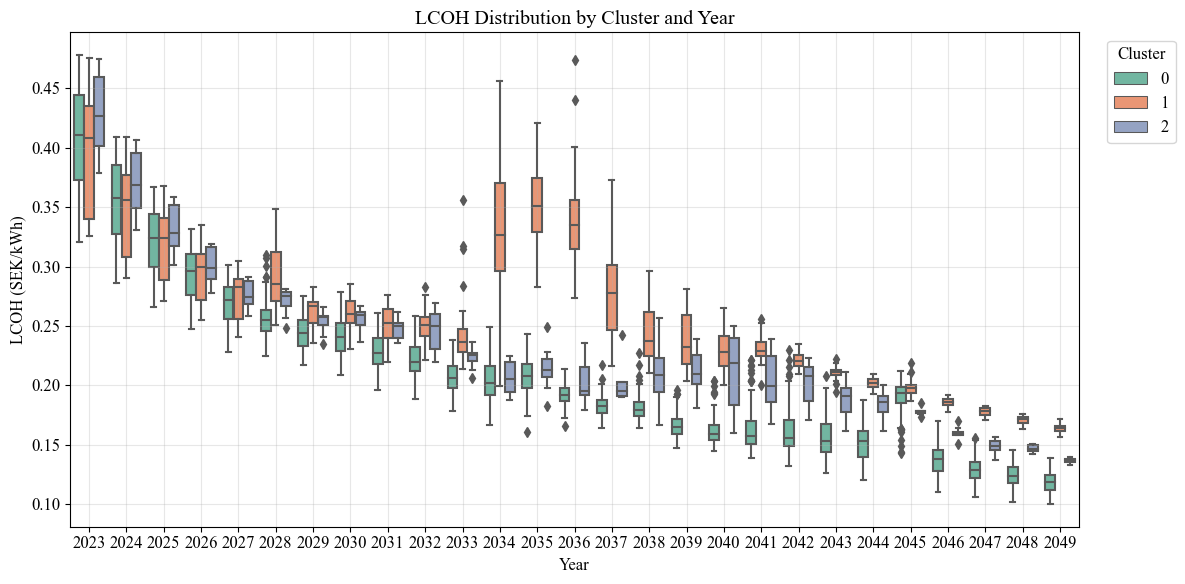

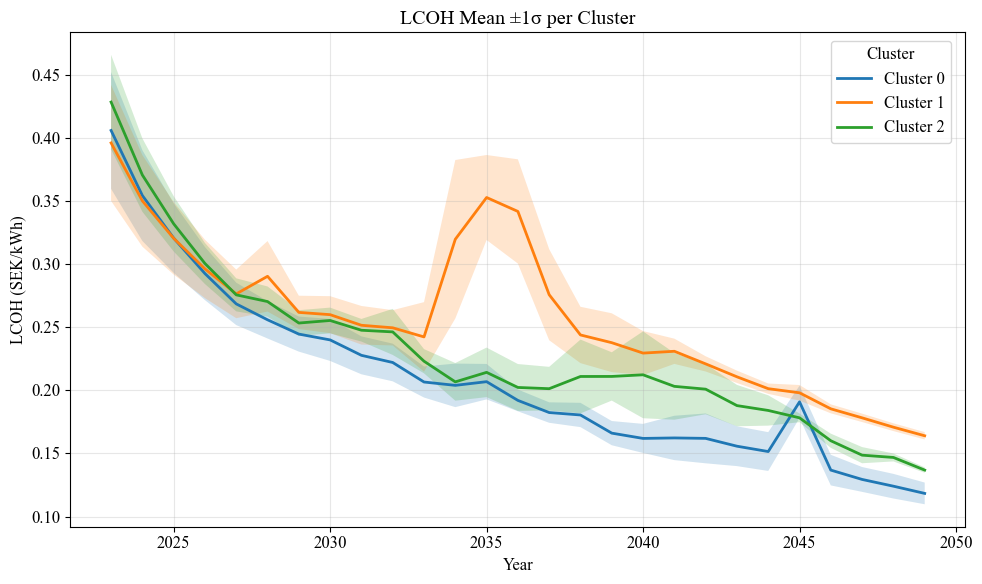

✅ Saved LCOH visualisations → DTW_results/


In [31]:
# --- VISUALISE LCOH DISTRIBUTION ACROSS CLUSTERS ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
# Paths
OUT_MERGED = Path("DTW_results/lcoh_by_cluster.csv")
OUT_STATS = Path("DTW_results/lcoh_cluster_summary.csv")
OUT_DIR = Path("DTW_results")

# Load merged data
df_lcoh = pd.read_csv(OUT_MERGED)
summary = pd.read_csv(OUT_STATS)

if df_lcoh.empty:
    raise RuntimeError("No LCOH data found. Please rerun the structuring step first.")

# --- Boxplot: LCOH distribution per cluster per year ---
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_lcoh,
    x="Year",
    y="LCOH_SEK_per_kWh",
    hue="Cluster",
    palette="Set2"
)
plt.title("LCOH Distribution by Cluster and Year")
plt.ylabel("LCOH (SEK/kWh)")
plt.xlabel("Year")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.savefig(OUT_DIR / "lcoh_boxplot_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()


# --- Mean ±1σ line plot per cluster ---
plt.figure(figsize=(10, 6))
for c in sorted(summary["Cluster"].unique()):
    sub = summary[summary["Cluster"] == c]
    plt.plot(sub["Year"], sub["mean"], label=f"Cluster {c}", linewidth=2)
    plt.fill_between(sub["Year"], sub["mean"] - sub["std"], sub["mean"] + sub["std"], alpha=0.2)

plt.title("LCOH Mean ±1σ per Cluster")
plt.xlabel("Year")
plt.ylabel("LCOH (SEK/kWh)")
plt.grid(alpha=0.3)
plt.legend(title="Cluster", bbox_to_anchor=(0.84, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "lcoh_mean_std_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved LCOH visualisations → DTW_results/")


In [32]:
# --- LCOH SUMMARY INSIGHTS (PRINT + OVERALL TABLE) ---
import pandas as pd
from pathlib import Path
import numpy as np

OUT_STATS = Path("DTW_results/lcoh_cluster_summary.csv")
OUT_DIR = Path("DTW_results")

# Load per-year/per-cluster stats if not in memory
try:
    summary
except NameError:
    summary = pd.read_csv(OUT_STATS)

if summary.empty:
    raise RuntimeError("LCOH summary is empty. Re-run the structuring cell.")

# Per-cluster OVERALL metrics (aggregating across years)
overall = (
    summary
    .groupby("Cluster")
    .agg(
        Mean_LCOH_over_years=("mean", "mean"),
        Median_LCOH_over_years=("mean", "median"),
        Min_Yearly_Mean_LCOH=("mean", "min"),
        Max_Yearly_Mean_LCOH=("mean", "max"),
        # temporal volatility of the mean across years
        Temporal_SD_of_Mean=("mean", "std"),
        # average cross-scenario dispersion across years
        Avg_SD_across_years=("std", "mean"),
        # coefficient of variation of the cluster mean across years
        CV_of_Mean_over_years=("mean", lambda x: float(np.std(x, ddof=0) / (np.mean(x) + 1e-12))),
        # best-case / worst-case bands across years
        Avg_Lower_Band=("mean", lambda x: float(np.mean(x))),
        Avg_Upper_Band=("mean", lambda x: float(np.mean(x))),  # kept for structure; bands visualized earlier
        N_years=("Year", "nunique"),
    )
    .reset_index()
)

# Rank clusters on a few useful axes
overall["Rank_Lowest_Average_LCOH"] = overall["Mean_LCOH_over_years"].rank(method="min")
overall["Rank_Most_Stable_Temporal"] = overall["Temporal_SD_of_Mean"].rank(ascending=True, method="min")
overall["Rank_Most_Consistent_Across_Scenarios"] = overall["Avg_SD_across_years"].rank(ascending=True, method="min")

# Save table
overall_path = OUT_DIR / "lcoh_cluster_summary_overall.csv"
overall.to_csv(overall_path, index=False)

# ---- Print concise insights ----
print("\n=== LCOH Cluster Insights (aggregated across years) ===")
print(overall[[
    "Cluster",
    "Mean_LCOH_over_years",
    "Median_LCOH_over_years",
    "Temporal_SD_of_Mean",
    "Avg_SD_across_years",
    "CV_of_Mean_over_years",
    "N_years"
]].round(4).to_string(index=False))

best_cost = overall.sort_values("Mean_LCOH_over_years").iloc[0]
best_stability_time = overall.sort_values("Temporal_SD_of_Mean").iloc[0]
best_consistency_cross = overall.sort_values("Avg_SD_across_years").iloc[0]

print("\n— Lowest average LCOH:")
print(f"  Cluster {int(best_cost.Cluster)} with mean {best_cost.Mean_LCOH_over_years:.4f} SEK/kWh")

print("\n— Most temporally stable (smallest SD of mean over years):")
print(f"  Cluster {int(best_stability_time.Cluster)} with temporal SD {best_stability_time.Temporal_SD_of_Mean:.4f}")

print("\n— Most consistent across scenarios (smallest average SD across years):")
print(f"  Cluster {int(best_consistency_cross.Cluster)} with avg SD {best_consistency_cross.Avg_SD_across_years:.4f}")

print(f"\n✅ Saved overall LCOH cluster summary → {overall_path}")


=== LCOH Cluster Insights (aggregated across years) ===
 Cluster  Mean_LCOH_over_years  Median_LCOH_over_years  Temporal_SD_of_Mean  Avg_SD_across_years  CV_of_Mean_over_years  N_years
       0                0.2098                  0.1921               0.0712               0.0161                 0.3329       27
       1                0.2578                  0.2497               0.0606               0.0203                 0.2308       27
       2                0.2300                  0.2111               0.0676               0.0161                 0.2884       27

— Lowest average LCOH:
  Cluster 0 with mean 0.2098 SEK/kWh

— Most temporally stable (smallest SD of mean over years):
  Cluster 1 with temporal SD 0.0606

— Most consistent across scenarios (smallest average SD across years):
  Cluster 0 with avg SD 0.0161

✅ Saved overall LCOH cluster summary → DTW_results\lcoh_cluster_summary_overall.csv


## Structure emission-intensity time series by existing clusters

In [33]:
# --- Build Emission Intensity (kg/kWh) Time Series from scenario folders ---
import pandas as pd
import numpy as np
from pathlib import Path
import re

# =========================
# Config
# =========================
ROOT = Path(".")                       # parent containing LTLE_scenario_* folders
EMISS_FILE = "AnnTechEmission.csv"   # emissions per technology per year (VALUE in kton)
PROD_FILE  = "ProdByTechAnn.csv"       # annual production by technology (VALUE in TJ)
OUT_FILE   = Path("analysis/emissions_timeseries.csv")

# DHN production filter
HEAT_FUEL_TOKEN = "CONVHEAT"           # restrict to heat rows in production file
DHN_TECHS = {"DHNNV", "DHNCS"}         # tech codes that feed DHN totals (case-insensitive)

# =========================
# Helpers
# =========================
_SCEN_RE = re.compile(r"^LTLE[_\- ]?scenario[_\- ]?(\d+)$", re.IGNORECASE)

def scenario_id_from_path(p: Path):
    m = _SCEN_RE.search(p.name)
    return int(m.group(1)) if m else p.name

def is_scenario_dir(p: Path) -> bool:
    return p.is_dir() and _SCEN_RE.search(p.name) is not None

def _read_csv_flex(path: Path):
    """
    Flexible CSV reader that standardizes VALUE and YEAR, and keeps TECHNOLOGY/FUEL if present.
    Returns DataFrame with standardized columns among: VALUE, YEAR, TECHNOLOGY, FUEL
    or None if file missing / unusable.
    """
    if not path.exists():
        return None
    try:
        df = pd.read_csv(path)
        cl = {c.lower(): c for c in df.columns}

        # required VALUE + YEAR
        val_col  = cl.get("value") or next((c for c in df.columns if c.lower().startswith("val")), None)
        year_col = cl.get("year")  or cl.get("yyyy") or cl.get("yr") or None
        if val_col is None or year_col is None:
            return None

        keep = [val_col, year_col]
        out_cols = ["VALUE", "YEAR"]

        # optional TECHNOLOGY
        tech_col = cl.get("technology") or next((c for c in df.columns if c.lower().startswith("tech")), None)
        if tech_col is not None:
            keep.append(tech_col); out_cols.append("TECHNOLOGY")

        # optional FUEL/COMMODITY
        for k in ("fuel", "commodity", "outputcommodity", "carrier"):
            if k in cl:
                keep.append(cl[k]); out_cols.append("FUEL")
                break

        out = df[keep].copy()
        out.columns = out_cols
        out["YEAR"]  = pd.to_numeric(out["YEAR"], errors="coerce")
        out["VALUE"] = pd.to_numeric(out["VALUE"], errors="coerce")
        return out.dropna(subset=["YEAR","VALUE"])
    except Exception:
        return None

# =========================
# 1) Loop scenarios and compute per-year emission intensity
# =========================
rows = []
scen_dirs = sorted([p for p in ROOT.iterdir() if is_scenario_dir(p)], key=lambda p: scenario_id_from_path(p))

if not scen_dirs:
    raise SystemExit("No LTLE_scenario_* folders found. Check ROOT path.")

for sdir in scen_dirs:
    sid = scenario_id_from_path(sdir)

    # Emissions: sum across technologies per YEAR (kton)
    emiss_df = _read_csv_flex(sdir / EMISS_FILE)
    if emiss_df is None:
        print(f"⚠️  {sdir.name}: missing/unreadable {EMISS_FILE}; skipping scenario.")
        continue
    emiss_by_year = emiss_df.groupby("YEAR", as_index=False)["VALUE"].sum().rename(columns={"VALUE":"EMISS_KTON"})

    # Production: filter to heat CONVHEAT and DHN technologies; sum per YEAR (TJ)
    prod_df = _read_csv_flex(sdir / PROD_FILE)
    if prod_df is None:
        print(f"⚠️  {sdir.name}: missing/unreadable {PROD_FILE}; skipping scenario.")
        continue

    p = prod_df.copy()
    if "FUEL" in p.columns:
        p = p[p["FUEL"].astype(str).str.contains(HEAT_FUEL_TOKEN, case=False, na=False)]
    if "TECHNOLOGY" in p.columns:
        tech_up = p["TECHNOLOGY"].astype(str).str.upper()
        p = p[tech_up.isin({t.upper() for t in DHN_TECHS})]

    heat_by_year = p.groupby("YEAR", as_index=False)["VALUE"].sum().rename(columns={"VALUE":"HEAT_TJ"})

    # Join and compute intensity
    df_y = pd.merge(emiss_by_year, heat_by_year, on="YEAR", how="inner")
    if df_y.empty:
        print(f"⚠️  {sdir.name}: no overlapping years for emissions/heat; skipping scenario.")
        continue

    # Emission intensity in kg/kWh:
    # 1 kton = 1e6 kg; 1 TJ = 277,777.78 kWh → kg/kWh = (kton/TJ) * 1e6 / 277,777.78 = 3.6 * (kton/TJ)
    df_y["Emission_Intensity_kg_per_kWh"] = 3.6 * (df_y["EMISS_KTON"] / df_y["HEAT_TJ"])

    df_y.insert(0, "Scenario", sid)
    df_y.rename(columns={"YEAR":"Year"}, inplace=True)
    rows.append(df_y[["Scenario","Year","Emission_Intensity_kg_per_kWh"]])

# =========================
# 2) Concatenate and save tidy time series
# =========================
if not rows:
    raise SystemExit("No emission intensity could be computed. Check input files and folder structure.")

emiss_ts = pd.concat(rows, ignore_index=True).sort_values(["Scenario","Year"]).reset_index(drop=True)
OUT_FILE.parent.mkdir(parents=True, exist_ok=True)
emiss_ts.to_csv(OUT_FILE, index=False)

print(f"✅ Saved emission intensity time series → {OUT_FILE.resolve()}")
print(f"Scenarios: {emiss_ts['Scenario'].nunique()} | Years: {emiss_ts['Year'].nunique()} | Rows: {len(emiss_ts):,}")


⚠️  LTLE_scenario_114: missing/unreadable AnnTechEmission.csv; skipping scenario.
✅ Saved emission intensity time series → C:\Paper 4\Outputs\Raw\analysis\emissions_timeseries.csv
Scenarios: 203 | Years: 27 | Rows: 5,481


In [34]:
# --- EMISSIONS × CLUSTERS: MERGE & SUMMARIZE (creates the files the plots need) ---
import pandas as pd
import numpy as np
from pathlib import Path
import re
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
OUT_DIR = Path("DTW_results")
EMISS_TS_PATH = Path("analysis/emissions_timeseries.csv")   # from the previous emissions-intensity build step
LABELS_PATH   = OUT_DIR / "totcap_dtw_labels.csv"           # reuse total-capacity DTW clusters

EMISS_MERGED  = OUT_DIR / "emissions_by_cluster.csv"
EMISS_STATS   = OUT_DIR / "emissions_cluster_summary.csv"

# --- Load data ---
df_emiss = pd.read_csv(EMISS_TS_PATH)           # expects: Scenario, Year, Emission_Intensity_kg_per_kWh
df_lbl   = pd.read_csv(LABELS_PATH)             # expects: Scenario, Cluster

# --- Normalize scenario IDs to integers if possible (handles 'LTLE_scenario_12' vs 12) ---
def norm_scen(x):
    if pd.isna(x): 
        return np.nan
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else x

df_emiss["Scenario_norm"] = df_emiss["Scenario"].apply(norm_scen)
df_lbl["Scenario_norm"]   = df_lbl["Scenario"].apply(norm_scen)

# Use normalized key to merge
df_emiss = df_emiss.rename(columns={"Year":"Year_raw"})  # avoid accidental collisions
df_merged = (
    df_emiss.merge(df_lbl[["Scenario_norm","Cluster"]], on="Scenario_norm", how="left")
            .rename(columns={"Year_raw":"Year"})
)

# Keep only rows with a mapped cluster
df_merged = df_merged.dropna(subset=["Cluster"]).copy()
df_merged["Cluster"] = df_merged["Cluster"].astype(int)
df_merged["Year"]    = pd.to_numeric(df_merged["Year"], errors="coerce")
df_merged = df_merged.dropna(subset=["Year"]).copy()
df_merged["Year"]    = df_merged["Year"].astype(int)

# Verify expected emissions column exists; alias to a simple name
emiss_cols = [c for c in df_merged.columns if "emission" in c.lower() and "per" in c.lower()]
if not emiss_cols:
    raise ValueError("Could not find emission-intensity column in emissions_timeseries.csv. "
                     "Expected something like 'Emission_Intensity_kg_per_kWh'.")
EMISS_COL = emiss_cols[0]
df_merged = df_merged.rename(columns={EMISS_COL: "EmissionIntensity"})

# Save merged tidy file for further analysis/plots
OUT_DIR.mkdir(parents=True, exist_ok=True)
df_merged_out = df_merged[["Scenario","Year","Cluster","EmissionIntensity"]].copy()
df_merged_out.to_csv(EMISS_MERGED, index=False)

# --- Per-cluster per-year summary (mean, std, min, max, cv) ---
summary = (
    df_merged_out
      .groupby(["Cluster","Year"])["EmissionIntensity"]
      .agg(mean="mean", std="std", min="min", max="max")
      .reset_index()
)
summary["cv"] = summary["std"] / summary["mean"]
summary.to_csv(EMISS_STATS, index=False)

print(f"✅ Saved merged emissions-by-cluster → {EMISS_MERGED.resolve()}")
print(f"✅ Saved emissions cluster summary   → {EMISS_STATS.resolve()}")
print(f"Rows in merged: {len(df_merged_out):,} | Rows in summary: {len(summary):,}")

✅ Saved merged emissions-by-cluster → C:\Paper 4\Outputs\Raw\DTW_results\emissions_by_cluster.csv
✅ Saved emissions cluster summary   → C:\Paper 4\Outputs\Raw\DTW_results\emissions_cluster_summary.csv
Rows in merged: 5,481 | Rows in summary: 81


<Figure size 800x600 with 0 Axes>

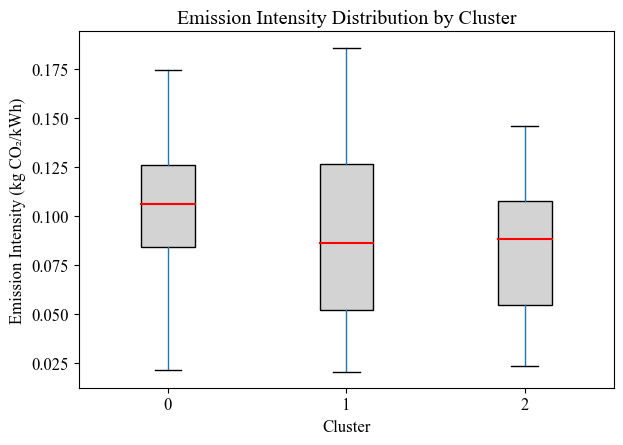

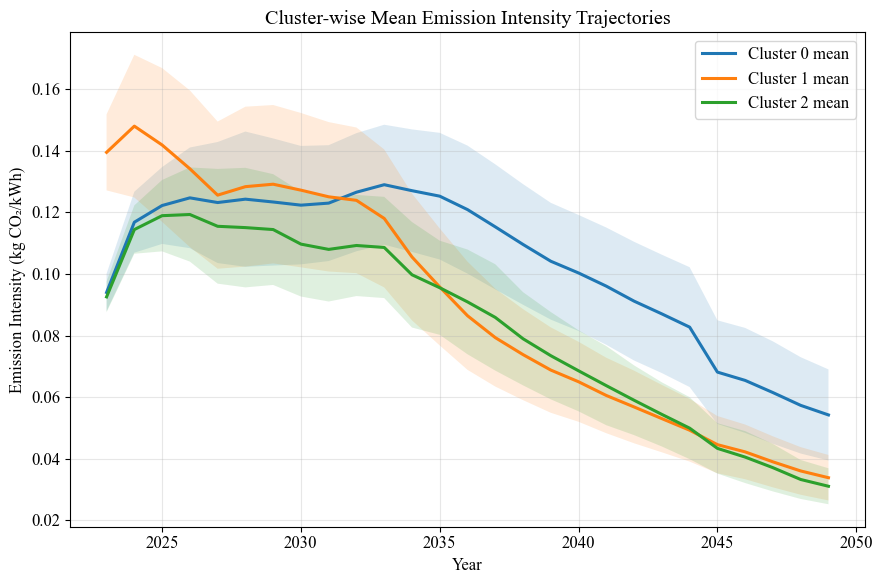

In [35]:
# --- Visualize Emission Intensity (kg/kWh) per Cluster ---
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
# Paths
OUT_DIR = Path("DTW_results")
EMISS_MERGED = OUT_DIR / "emissions_by_cluster.csv"
EMISS_STATS  = OUT_DIR / "emissions_cluster_summary.csv"

# Load data
df_emiss = pd.read_csv(EMISS_MERGED)
df_stats = pd.read_csv(EMISS_STATS)

# === 1. Boxplot: Overall distribution across clusters ===
plt.figure(figsize=(8,6))
df_emiss.boxplot(column="EmissionIntensity", by="Cluster", grid=False, patch_artist=True,
                 boxprops=dict(facecolor="lightgray", color="black"),
                 medianprops=dict(color="red", linewidth=1.5))
plt.title("Emission Intensity Distribution by Cluster")
plt.suptitle("")  # remove auto title
plt.xlabel("Cluster")
plt.ylabel("Emission Intensity (kg CO₂/kWh)")
plt.tight_layout()
plt.savefig(OUT_DIR / "emission_intensity_boxplot.png", dpi=300)
plt.show()

# === 2. Mean ±1σ trajectories per cluster over time ===
plt.figure(figsize=(9,6))
for c in sorted(df_stats["Cluster"].unique()):
    sub = df_stats[df_stats["Cluster"] == c].sort_values("Year")
    plt.plot(sub["Year"], sub["mean"], label=f"Cluster {c} mean", linewidth=2.2)
    plt.fill_between(sub["Year"], sub["mean"]-sub["std"], sub["mean"]+sub["std"], alpha=0.15)

plt.title("Cluster-wise Mean Emission Intensity Trajectories")
plt.xlabel("Year")
plt.ylabel("Emission Intensity (kg CO₂/kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "emission_intensity_trajectories.png", dpi=300)
plt.show()


In [36]:
# --- TECHNOLOGY SHARES OF HEAT GENERATION BY CLUSTER (USING EXISTING TOTCAP CLUSTERS) ---
import pandas as pd
import numpy as np
import re
from pathlib import Path

OUT_DIR = Path("DTW_results")
HEAT_LONG = Path("aggregates/heat_generation_long.csv")   # columns: Scenario, Year, Technology, GWh
LABELS    = OUT_DIR / "totcap_dtw_labels.csv"             # columns: Scenario, Cluster

OUT_LONG  = OUT_DIR / "tech_shares_by_cluster.csv"        # Cluster, Year, Technology, Share
OUT_WIDE  = OUT_DIR / "tech_shares_by_cluster_wide.csv"   # index=[Cluster,Year], cols=Technology, values=Share

# Load
df_heat = pd.read_csv(HEAT_LONG)
df_lbl  = pd.read_csv(LABELS)

# Normalize scenario IDs to match (handles 'LTLE_scenario_12' vs 12)
def norm_scen(x):
    if pd.isna(x): 
        return np.nan
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else x

df_heat["Scenario_norm"] = df_heat["Scenario"].apply(norm_scen)
df_lbl["Scenario_norm"]  = df_lbl["Scenario"].apply(norm_scen)

# Merge cluster labels
df = (
    df_heat.merge(df_lbl[["Scenario_norm","Cluster"]], on="Scenario_norm", how="left")
           .dropna(subset=["Cluster"])
           .rename(columns={"Year":"Year_raw"})
)
df["Cluster"] = df["Cluster"].astype(int)
df["Year"] = pd.to_numeric(df["Year_raw"], errors="coerce").astype("Int64")
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)

# Sum generation per Cluster-Year-Technology
agg = (
    df.groupby(["Cluster","Year","Technology"], as_index=False)["GWh"]
      .sum()
)

# Compute shares within each Cluster-Year
totals = agg.groupby(["Cluster","Year"], as_index=False)["GWh"].sum().rename(columns={"GWh":"Total_GWh"})
shares = agg.merge(totals, on=["Cluster","Year"], how="left")
shares["Share"] = np.where(shares["Total_GWh"] > 0, shares["GWh"] / shares["Total_GWh"], 0.0)

# Save long format
OUT_DIR.mkdir(parents=True, exist_ok=True)
shares_long = shares[["Cluster","Year","Technology","Share"]].copy()
shares_long.to_csv(OUT_LONG, index=False)

# Save wide format (for stacked plots)
shares_wide = shares_long.pivot_table(index=["Cluster","Year"], columns="Technology", values="Share", aggfunc="mean").fillna(0.0)
shares_wide.to_csv(OUT_WIDE)

print(f"✅ Saved tech shares (long)  → {OUT_LONG.resolve()}")
print(f"✅ Saved tech shares (wide)  → {OUT_WIDE.resolve()}")
print(f"Rows (long): {len(shares_long):,}  |  Rows (wide): {len(shares_wide):,}")

✅ Saved tech shares (long)  → C:\Paper 4\Outputs\Raw\DTW_results\tech_shares_by_cluster.csv
✅ Saved tech shares (wide)  → C:\Paper 4\Outputs\Raw\DTW_results\tech_shares_by_cluster_wide.csv
Rows (long): 810  |  Rows (wide): 81


✅ Saved fuel-type shares (long) → C:\Paper 4\Outputs\Raw\DTW_results\fueltype_shares_by_cluster.csv
✅ Saved fuel-type shares (wide) → C:\Paper 4\Outputs\Raw\DTW_results\fueltype_shares_by_cluster_wide.csv


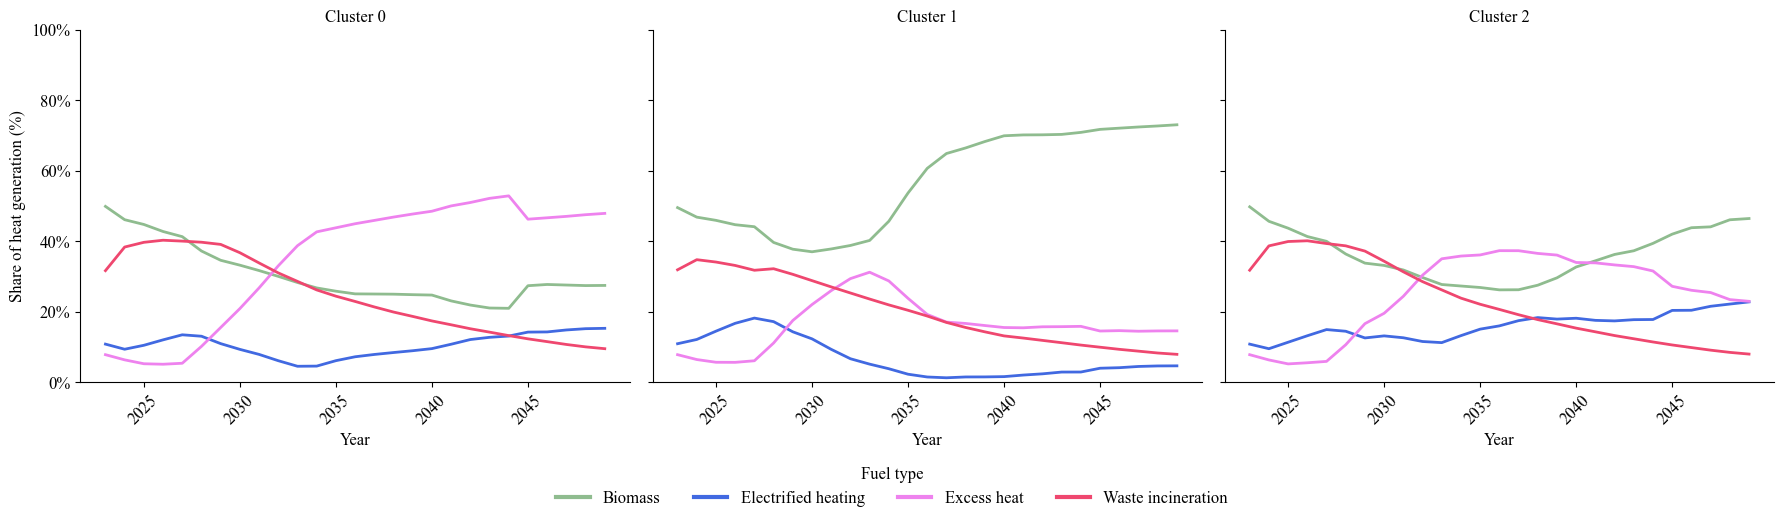

In [37]:
# --- Aggregate tech shares -> fuel-type shares (save new CSVs) + dynamic line plots ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12

OUT_DIR = Path("DTW_results")
IN_LONG  = OUT_DIR / "tech_shares_by_cluster.csv"              # existing long file
OUT_LONG = OUT_DIR / "fueltype_shares_by_cluster.csv"          # NEW aggregated long
OUT_WIDE = OUT_DIR / "fueltype_shares_by_cluster_wide.csv"     # NEW aggregated wide

# Load existing long shares (Cluster, Year, Technology, Share)
df = pd.read_csv(IN_LONG)

# --- Mapping rules (case-insensitive substring checks) ---
def map_fueltype(tech: str) -> str:
    t = str(tech).lower()
    if ("bio" in t) or ("wood" in t):
        return "Biomass"
    if ("sea water heat pump" in t) or ("sea water heat pumps" in t) or ("electric boiler" in t) or ("electric boilers" in t):
        return "Electrified heating"
    if ("data centre" in t) or ("data center" in t) or ("sewage" in t) or ("low temperature" in t):
        return "Excess heat"
    if ("waste" in t):
        return "Waste incineration"
    return "Other"

df["FuelType"] = df["Technology"].apply(map_fueltype)

# --- Aggregate shares within Cluster-Year-FuelType ---
agg = (
    df.groupby(["Cluster","Year","FuelType"], as_index=False)["Share"]
      .sum()
)

# Clip minor numerical noise and cap within [0,1]
agg["Share"] = agg["Share"].clip(lower=0, upper=1)

# Ensure shares per Cluster-Year sum to <= 1 (floating-point safety)
tot = agg.groupby(["Cluster","Year"], as_index=False)["Share"].sum().rename(columns={"Share":"SumShare"})
agg = agg.merge(tot, on=["Cluster","Year"], how="left")
# If SumShare > 1 by tiny epsilon, renormalize
eps = 1e-9
mask = agg["SumShare"] > 1 + 1e-6
if mask.any():
    agg.loc[mask, "Share"] = agg.loc[mask, "Share"] / agg.loc[mask, "SumShare"]
# Drop helper
agg = agg.drop(columns=["SumShare"])

# Save aggregated CSVs
OUT_DIR.mkdir(parents=True, exist_ok=True)
agg.to_csv(OUT_LONG, index=False)
wide = agg.pivot_table(index=["Cluster","Year"], columns="FuelType", values="Share", aggfunc="mean").fillna(0.0)
wide.to_csv(OUT_WIDE)
print(f"✅ Saved fuel-type shares (long) → {OUT_LONG.resolve()}")
print(f"✅ Saved fuel-type shares (wide) → {OUT_WIDE.resolve()}")

# =========================
# Dynamic plotting (lines, not area)
# =========================

# User-selectable levers:
# - which clusters to show; leave None to include all
# - which fuel-type categories to show; leave None to include all present
CLUSTERS_TO_PLOT    = [0, 1, 2]       # e.g., [0, 1, 2]
CATEGORIES_TO_PLOT  = ["Biomass", "Electrified heating", "Excess heat", "Waste incineration"]       # e.g., ["Biomass", "Electrified heating", "Excess heat", "Waste incineration"]

# Prepare data for plotting
wide = pd.read_csv(OUT_WIDE, index_col=[0,1])
wide.index = wide.index.set_names(["Cluster","Year"])

all_clusters = sorted(wide.index.get_level_values(0).unique())
clusters = all_clusters if CLUSTERS_TO_PLOT is None else [c for c in CLUSTERS_TO_PLOT if c in all_clusters]

all_cats = list(wide.columns)
cats = all_cats if CATEGORIES_TO_PLOT is None else [c for c in CATEGORIES_TO_PLOT if c in all_cats]

if not clusters:
    raise RuntimeError("No clusters selected/found to plot.")
if not cats:
    raise RuntimeError("No categories selected/found to plot.")

# Single-row subplot: one subplot per cluster
fig, axes = plt.subplots(1, len(clusters), figsize=(6*len(clusters), 5), sharey=True)
if len(clusters) == 1:
    axes = [axes]

# Color palette per category
palette = {
    "Biomass": "#8FBC8F",
    "Electrified heating": "#4169E1",
    "Excess heat": "#EE82EE",
    "Waste incineration": "#EF476F",
    "Other": "#808080",
}
# Fallback color in case new categories appear
def color_for(cat):
    return palette.get(cat, "#999999")

for ax, c in zip(axes, clusters):
    sub = wide.loc[c].copy().sort_index()
    # Keep only requested categories
    sub = sub[[k for k in cats if k in sub.columns]]

    # Plot each category as a line
    for cat in sub.columns:
        ax.plot(sub.index, sub[cat], label=cat, linewidth=2.0, color=color_for(cat))

    # Style
    ax.set_title(f"Cluster {c}", fontsize=12)
    ax.set_xlabel("Year")
    if ax is axes[0]:
        ax.set_ylabel("Share of heat generation (%)")
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

    
    ax.set_facecolor("white")
    for spine in ("top","right"):
        ax.spines[spine].set_visible(False)

    # 5-year ticks up to 2049 (treat 2049 as 2050 for now)
    years_min = int(sub.index.min())
    xticks = np.arange(years_min - (years_min % 5), 2050, 5)
    xticks = xticks[(xticks >= years_min) & (xticks <= 2049)]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(x)) for x in xticks], rotation=45)

# Shared legend at the bottom with only the categories actually plotted
legend_labels = cats
legend_handles = [plt.Line2D([0],[0], color=color_for(cat), lw=3) for cat in legend_labels]
fig.legend(legend_handles, legend_labels, loc="lower center", ncol=min(5, len(legend_labels)),
           frameon=False, bbox_to_anchor=(0.5, -0.06), title="Fuel type")

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(OUT_DIR / "fueltype_shares_clusters_lines.png", dpi=300, bbox_inches="tight")
plt.show()


In [38]:
# --- Compute annual utilization rates by technology group per scenario ---

import pandas as pd, numpy as np
from pathlib import Path

ROOT = Path(".")
PROD_FILE = "ProdByTechAnn.csv"
CAP_FILE = "TotCapacityAnn.csv"
OUT_UTIL = Path("DTW_results/utilization_raw.csv")
OUT_UTIL.parent.mkdir(exist_ok=True)

# Mapping of detailed technologies to categories
TECH_MAP = {
    'Waste Incineration CHP': ['BristaB2', 'HgldP3468', 'LSVTACHP'],
    'Data Centre Heat Pumps': ['DCACC'],
    'Bio Oil CHP': ['KVV1'],
    'Bio Oil HOBs': ['DECFOHOB', 'CSBOHOB'],
    'Bio Pellets CHP': ['HslbyP1toP3'],
    'Wood Chips CHP': ['BristaB1', 'KVV8'],
    'Sea Water Heat Pumps': ['VVNHP'],
    'Sewage Treatment Heat Pumps': ['HmrbySEWHP', 'SEWACC'],
    'Electric Boilers': ['VVHVELHOB'],
    'Low Temperature Sources Heat Pumps': ['SUPACC'],
}

GWH_FACTOR = 0.27777778  # TJ → GWh conversion
HOURS_YEAR = 8760

rows = []
scen_dirs = sorted([d for d in ROOT.glob("LTLE_scenario_*") if d.is_dir()])

for scen_dir in scen_dirs:
    scen = scen_dir.name
    prod_path = scen_dir / PROD_FILE
    cap_path = scen_dir / CAP_FILE

    if not (prod_path.exists() and cap_path.exists()):
        print(f"⚠️ Skipping {scen} (missing files)")
        continue

    try:
        prod = pd.read_csv(prod_path)
        cap = pd.read_csv(cap_path)

        # Basic cleaning
        for df in (prod, cap):
            df.columns = df.columns.str.upper()

        if not {"YEAR", "TECHNOLOGY", "VALUE"}.issubset(prod.columns):
            raise ValueError("Production file missing required columns.")
        if not {"YEAR", "TECHNOLOGY", "VALUE"}.issubset(cap.columns):
            raise ValueError("Capacity file missing required columns.")

        # Filter production for heat only
        prod = prod[prod["FUEL"].str.contains("CONVHEAT", case=False, na=False)].copy()

        # Pivot both to YEAR × TECH
        P = prod.pivot_table(index="YEAR", columns="TECHNOLOGY", values="VALUE", aggfunc="sum").fillna(0.0)
        C = cap.pivot_table(index="YEAR", columns="TECHNOLOGY", values="VALUE", aggfunc="sum").fillna(0.0)

        # Aggregate according to TECH_MAP
        for tech_group, techs in TECH_MAP.items():
            techs_present_p = [t for t in techs if t in P.columns]
            techs_present_c = [t for t in techs if t in C.columns]
            if not techs_present_p or not techs_present_c:
                continue

            prod_TJ = P[techs_present_p].sum(axis=1)  # TJ
            cap_MW = C[techs_present_c].sum(axis=1)   # MW

            TJ_TO_MWh = 277.77778
            util = (prod_TJ * TJ_TO_MWh) / (cap_MW * HOURS_YEAR) * 100  # %
            util = util.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0, upper=100)

            df_tmp = pd.DataFrame({
                "Scenario": scen,
                "Year": prod_TJ.index,
                "Technology": tech_group,
                "UtilizationRate_%": util.values
            })
            rows.append(df_tmp)

    except Exception as e:
        print(f"⚠️ Error in {scen}: {e}")
        continue

if not rows:
    raise RuntimeError("No valid scenarios processed for utilization calculation.")

util_all = pd.concat(rows, ignore_index=True)
util_all.to_csv(OUT_UTIL, index=False)
print(f"✅ Saved raw utilization data → {OUT_UTIL.resolve()}")
print(util_all.head())

✅ Saved raw utilization data → C:\Paper 4\Outputs\Raw\DTW_results\utilization_raw.csv
            Scenario  Year              Technology  UtilizationRate_%
0  LTLE_scenario_001  2023  Waste Incineration CHP          83.619016
1  LTLE_scenario_001  2024  Waste Incineration CHP          96.760154
2  LTLE_scenario_001  2025  Waste Incineration CHP          97.172048
3  LTLE_scenario_001  2026  Waste Incineration CHP          97.762818
4  LTLE_scenario_001  2027  Waste Incineration CHP          98.540255


In [39]:
# --- Merge utilization data with clusters & summarize by cluster ---

import pandas as pd
from pathlib import Path

OUT_DIR = Path("DTW_results")
RAW_UTIL = OUT_DIR / "utilization_raw.csv"
CLUST_PATH = OUT_DIR / "totcap_dtw_labels.csv"
OUT_UTIL_BYCLUST = OUT_DIR / "utilization_by_cluster.csv"
OUT_UTIL_STATS = OUT_DIR / "utilization_cluster_summary.csv"

# Load data
df_util = pd.read_csv(RAW_UTIL)
df_labels = pd.read_csv(CLUST_PATH)

if "Scenario" not in df_util.columns or "Scenario" not in df_labels.columns:
    raise ValueError("Both utilization and cluster label files must contain a 'Scenario' column.")

# Clean up scenario identifiers (strip possible prefixes)
df_util["Scenario"] = df_util["Scenario"].astype(str).str.extract(r"(\d+)")[0].astype(int)
df_labels["Scenario"] = df_labels["Scenario"].astype(str).str.extract(r"(\d+)")[0].astype(int)

# Merge
df_util = df_util.merge(df_labels, on="Scenario", how="left")
df_util.rename(columns={"Cluster": "ClusterID"}, inplace=True)

# Compute mean and std per cluster, year, technology
util_summary = (
    df_util.groupby(["ClusterID", "Year", "Technology"], as_index=False)
    .agg(mean_util=("UtilizationRate_%", "mean"),
         sd_util=("UtilizationRate_%", "std"))
)

# Save outputs
df_util.to_csv(OUT_UTIL_BYCLUST, index=False)
util_summary.to_csv(OUT_UTIL_STATS, index=False)

print(f"✅ Saved merged utilization-by-cluster data → {OUT_UTIL_BYCLUST}")
print(f"✅ Saved utilization summary stats → {OUT_UTIL_STATS}")
print(util_summary.head())

✅ Saved merged utilization-by-cluster data → DTW_results\utilization_by_cluster.csv
✅ Saved utilization summary stats → DTW_results\utilization_cluster_summary.csv
   ClusterID  Year              Technology  mean_util       sd_util
0          0  2023             Bio Oil CHP   7.635489  2.376381e-02
1          0  2023            Bio Oil HOBs   7.705813  5.259261e-14
2          0  2023         Bio Pellets CHP  17.960182  5.296449e-01
3          0  2023  Data Centre Heat Pumps   0.000000  0.000000e+00
4          0  2023        Electric Boilers   2.017628  5.316720e-16


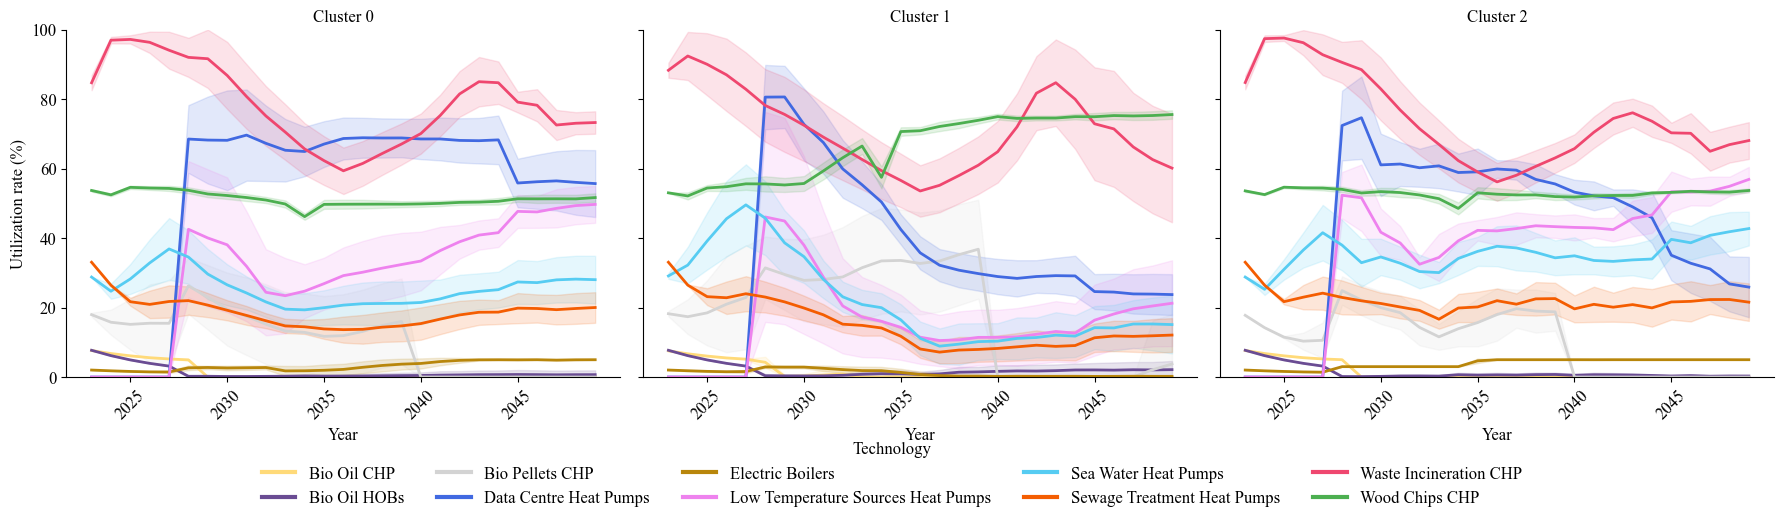

In [40]:
# --- Plot utilization rates by cluster (lines, %, 5-year ticks to 2049) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12

OUT_DIR = Path("DTW_results")
UTIL_STATS = OUT_DIR / "utilization_cluster_summary.csv"  # from previous cell

# Load summarized utilization (ClusterID, Year, Technology, mean_util, sd_util)
util = pd.read_csv(UTIL_STATS)

# --- Levers (edit if you want to filter) ---
CLUSTERS_TO_PLOT   = None  # e.g., [0,1,2]
TECHS_TO_PLOT      = None  # e.g., ["Waste Incineration CHP","Electric Boilers", ...]

# Filter
clusters = sorted(util["ClusterID"].unique()) if CLUSTERS_TO_PLOT is None else CLUSTERS_TO_PLOT
util_f = util[util["ClusterID"].isin(clusters)].copy()

if TECHS_TO_PLOT is not None:
    util_f = util_f[util_f["Technology"].isin(TECHS_TO_PLOT)]

# Colors for tech groups (extend as needed)
tech_colors = {
    'Waste Incineration CHP': '#EF476F',
    'Data Centre Heat Pumps': '#4169E1',
    'Bio Oil CHP': '#FFDA79',
    'Bio Oil HOBs': '#6A4C93',
    'Bio Pellets CHP': '#D3D3D3',
    'Wood Chips CHP': '#4CAF50',
    'Sea Water Heat Pumps': '#56CCF2',
    'Sewage Treatment Heat Pumps': '#F45D01',
    'Electric Boilers': '#B8860B',
    'Low Temperature Sources Heat Pumps': '#EE82EE',
}
def color_for(t): return tech_colors.get(t, "#999999")

# Figure: single row, one axes per cluster
nC = len(clusters)
fig, axes = plt.subplots(1, nC, figsize=(6*nC, 5), sharey=True)
if nC == 1:
    axes = [axes]

for ax, c in zip(axes, clusters):
    sub = util_f[util_f["ClusterID"] == c].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    # plot each technology line with band ±1σ
    for tech in sorted(sub["Technology"].unique()):
        s = sub[sub["Technology"] == tech].sort_values("Year")
        ax.plot(s["Year"], s["mean_util"], label=tech, linewidth=2.0, color=color_for(tech))
        # optional uncertainty band
        ax.fill_between(s["Year"], (s["mean_util"] - s["sd_util"]).clip(lower=0),
                        (s["mean_util"] + s["sd_util"]).clip(upper=100),
                        alpha=0.15, color=color_for(tech))

    # style
    ax.set_title(f"Cluster {c}", fontsize=12)
    ax.set_xlabel("Year")
    if ax is axes[0]:
        ax.set_ylabel("Utilization rate (%)")
    ax.set_ylim(0, 100)
    ax.set_facecolor("white")
    for spine in ("top","right"):
        ax.spines[spine].set_visible(False)

    # 5-year ticks up to 2049 (treat as 2050 for now)
    y_min = int(sub["Year"].min())
    start_tick = y_min - (y_min % 5)
    xticks = np.arange(start_tick, 2050, 5)
    xticks = xticks[(xticks >= y_min) & (xticks <= 2049)]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(x)) for x in xticks], rotation=45)

# Shared legend at bottom (only technologies present)
present_techs = sorted(util_f["Technology"].unique())
handles = [plt.Line2D([0],[0], color=color_for(t), lw=3) for t in present_techs]
fig.legend(handles, present_techs, loc="lower center", ncol=min(5, len(present_techs)),
           frameon=False, bbox_to_anchor=(0.5, -0.06), title="Technology")

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(OUT_DIR / "utilization_clusters_lines.png", dpi=300, bbox_inches="tight")
plt.show()


✅ Saved ranked driver importances → DTW_results\input_driver_importance_filtered.csv
            Driver    ANOVA_F  Mutual_Info  RF_Importance  Blended_Score
          n_spikes 126.439628     0.314166       0.165139       0.987845
         n_outages 131.774176     0.308263       0.156740       0.962068
       n_shutdowns 117.842696     0.285076       0.163175       0.932929
biomass_multiplier   1.800282     0.000000       0.096264       0.138989
     hp_multiplier   0.572295     0.000000       0.088040       0.104567
        MSW_AF2030   0.214831     0.000000       0.075528       0.055639
    msw_multiplier   0.408256     0.000000       0.066537       0.021505
        MSW_AF2050   0.114850     0.000000       0.063313       0.008440


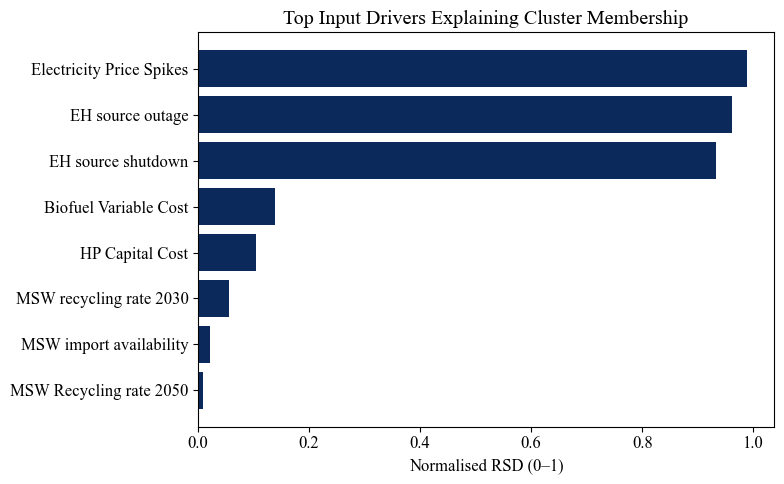

In [41]:
# --- INPUT DRIVER IMPORTANCE (filtered & optimized) ---
import pandas as pd, numpy as np, re, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12

# ---------------- PATHS ----------------
IN_DRIVERS = Path("scenario_log.csv")           
LABELS     = Path("DTW_results/totcap_dtw_labels.csv")    
OUT_DIR    = Path("DTW_results"); OUT_DIR.mkdir(exist_ok=True)
OUT_CSV    = OUT_DIR / "input_driver_importance_filtered.csv"
OUT_PNG    = OUT_DIR / "input_driver_importance_top_filtered.png"

# ---------------- LOAD ----------------
dfX = pd.read_csv(IN_DRIVERS)
dfL = pd.read_csv(LABELS)

def norm_scen(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else np.nan

dfX["Scenario_norm"] = dfX["Scenario"].apply(norm_scen)
dfL["Scenario_norm"] = dfL["Scenario"].apply(norm_scen)
df = dfX.merge(dfL[["Scenario_norm","Cluster"]], on="Scenario_norm", how="inner").dropna(subset=["Cluster"])
y = df["Cluster"].astype(int).values

# ---------------- FILTER ----------------
drop_pat = re.compile(r"(demand|seed)", re.IGNORECASE)
keep_cols = [c for c in df.columns 
             if c not in {"Scenario","Scenario_norm","Cluster"} and not drop_pat.search(c)]
df = df[["Scenario","Scenario_norm","Cluster"] + keep_cols]

# ---------------- DERIVE MSW FEATURES ----------------
def find_any(name_parts):
    for c in df.columns:
        lc = c.lower()
        if all(p in lc for p in name_parts): return c
    return None

col_mcv   = find_any(["msw","cv"]) or find_any(["waste","cv"])
col_r2050 = find_any(["msw","2050"]) or find_any(["waste","2050"])
col_k     = find_any(["msw","k"]) or find_any(["waste","k"])

if col_mcv and col_r2050:
    mcv   = pd.to_numeric(df[col_mcv], errors="coerce")
    R2050 = pd.to_numeric(df[col_r2050], errors="coerce")
    df["MSW_AF2050"] = (R2050 / 39.0) * (1.0 / mcv)
    if col_k:
        k = pd.to_numeric(df[col_k], errors="coerce")
        frac = (2030 - 2023) / (2050 - 2023)
        R2030 = 39 + (R2050 - 39) * np.power(frac, k)
        df["MSW_AF2030"] = (R2030 / 39.0) * (1.0 / mcv)
        df["MSW_k"] = k
    df.drop(columns=[col_mcv, col_r2050], inplace=True, errors="ignore")

# ---------------- SELECT NUMERIC ----------------
exclude = {"Scenario","Scenario_norm","Cluster"}
num_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
if not num_cols: raise ValueError("No numeric driver columns found.")
X = df[num_cols].astype(float).values
X = SimpleImputer(strategy="median").fit_transform(X)

# ---------------- IMPORTANCE METRICS ----------------
F_vals, _ = f_classif(X, y)
MI_vals = mutual_info_classif(X, y, random_state=42)

rf_imp = np.zeros(X.shape[1])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr, te in skf.split(X, y):
    rf = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42, class_weight="balanced")
    rf.fit(X[tr], y[tr])
    rf_imp += rf.feature_importances_
rf_imp /= skf.get_n_splits()

# ---------------- COMBINE & NORMALIZE ----------------
def mm(s): rng = s.max()-s.min(); return (s-s.min())/rng if rng>0 else np.zeros_like(s)
rank = pd.DataFrame({
    "Driver": num_cols,
    "ANOVA_F": F_vals,
    "Mutual_Info": MI_vals,
    "RF_Importance": rf_imp
})
rank["Blended_Score"] = 0.3*mm(rank["ANOVA_F"]) + 0.3*mm(rank["Mutual_Info"]) + 0.4*mm(rank["RF_Importance"])
rank = rank.sort_values("Blended_Score", ascending=False).reset_index(drop=True)

# Rename driver labels for presentation
rename_map = {
    "n_spikes": "Electricity Price Spikes",
    "n_shutdowns": "EH source shutdown",
    "n_outages": "EH source outage",
    "hp_multiplier": "HP Capital Cost",
    "biomass_multiplier": "Biofuel Variable Cost",
    "MSW_AF2050": "MSW Recycling rate 2050",
    "MSW_AF2030": "MSW recycling rate 2030",
    "msw_multiplier": "MSW import availability",
}

# ---------------- SAVE & PLOT ----------------
rank = rank[~rank["Driver"].str.lower().eq("msw_k")]
rank.to_csv(OUT_CSV, index=False)
print(f"✅ Saved ranked driver importances → {OUT_CSV}")
print(rank.head(15).to_string(index=False))

top = rank.head(10).iloc[::-1]
top["Driver"] = top["Driver"].map(lambda x: rename_map.get(x, x))

plt.figure(figsize=(8, 0.5*len(top)+1))
plt.barh(top["Driver"], top["Blended_Score"], color="#0B2A5B")
plt.xlabel("Normalised RSD (0–1)")
plt.title("Top Input Drivers Explaining Cluster Membership")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

## Robust strategy identification

## 🧩 Step 1 – Data Preparation and Setup

This cell loads and prepares the total installed capacity data for all scenarios.

**Purpose**

To create a single, tidy DataFrame (`df_cap`) containing the installed capacity of each technology
(`tech`) for every scenario (`scenario`) and year (`year`).  
This table will serve as the foundation for computing cluster-mean investment trajectories,
technology presence, and robustness metrics in later steps.

**Data sources**

We use the *long-format* total capacity file:

- `Scenario` — scenario identifier (e.g., `LTLE_scenario_001`)
- `Year` — model year
- `Category` — technology or heat-source category  
  → renamed to `tech` for consistency
- `Capacity_MW` — installed capacity in MW  
  → renamed to `mw`

Each row therefore represents one `(scenario, year, technology)` observation.

**Processing steps**

1. **Load data**  
   Read the `totalcapacity_plans_long.csv` file (or equivalent DataFrame already in memory).

2. **Standardize column names**  
   - Rename `Category` → `tech`  
   - Rename `Capacity_MW` → `mw`  
   - Ensure columns are lowercase and stripped of whitespace.

3. **Type conversion and cleaning**  
   Convert `year` to integer and `mw` to numeric; replace any missing or non-numeric values with 0.

4. **Compute total capacity per scenario–year**  
   Add a column `total_mw` as the sum of all technologies in each scenario-year combination.
   This allows calculation of relative shares (e.g., technology % of total).

5. **Define analysis horizon and threshold**  
   - `YEARS` → sorted list of all unique model years.  
   - `PRES_REL` = 0.05 → technologies representing at least 5 % of total system capacity
     are considered “present” in a given year.

**Outputs**

- `df_cap`: tidy DataFrame with columns  
  `scenario | year | tech | mw | total_mw`
- `YEARS`: list of model years (used in plotting and grouping)
- `PRES_REL`: relative presence threshold (used later for classifying technologies)

**Outcome**

After this cell, the dataset is standardized and ready for per-cluster aggregation and
identification of robust (no-regret) technologies in subsequent steps.


In [42]:
# --- Cell 1: Setup (constants + tidy capacity table) ---

import pandas as pd
import numpy as np

# ---- Config / constants ----
PRES_REL = 0.15  # 5% relative presence threshold
DEFAULT_CAP_PATH = "aggregates/totcap_plans_long.csv"  # adjust if needed

# ---- Load or reuse TotCapacityAnn ----
if "TotCapacityAnn" in globals():
    _cap = TotCapacityAnn.copy()
else:
    _cap = pd.read_csv(DEFAULT_CAP_PATH)

_cap = _cap.rename(columns={"Category": "tech"})
# ---- Standardize columns ----
_cap.columns = [c.strip().lower() for c in _cap.columns]

# common renames
rename_map = {
    "scenario": "scenario",
    "scen": "scenario",
    "scen_id": "scenario",
    "case": "scenario",
    "year": "year",
    "tech": "tech",
    "technology": "tech",
    "technology_name": "tech",
    "mw": "mw",
    "capacity_mw": "mw",
    "capacity": "mw",
    "value": "mw",
}
_cap = _cap.rename(columns={k: v for k, v in rename_map.items() if k in _cap.columns})

# ---- Handle wide format (years as columns) -> melt to long ----
if "year" not in _cap.columns:
    # infer year-like columns (integers or strings of integers)
    year_cols = [c for c in _cap.columns if str(c).isdigit()]
    id_cols = [c for c in _cap.columns if c not in year_cols]
    _cap = _cap.melt(id_vars=id_cols, value_vars=year_cols, var_name="year", value_name="mw")

# ---- Minimum required columns ----
_required = {"scenario", "year", "tech", "mw"}
missing = _required - set(_cap.columns)
if missing:
    raise ValueError(f"TotCapacityAnn is missing required columns: {missing}")

# ---- Clean types & filter ----
_cap = _cap.assign(
    year=_cap["year"].astype(int),
    mw=pd.to_numeric(_cap["mw"], errors="coerce").fillna(0.0)
)
# strip tech names
_cap["tech"] = _cap["tech"].astype(str).str.strip()

# ---- Tidy capacity & totals per (scenario, year) ----
df_cap = _cap.loc[:, ["scenario", "year", "tech", "mw"]].copy()
totals = df_cap.groupby(["scenario", "year"], as_index=False)["mw"].sum().rename(columns={"mw": "total_mw"})
df_cap = df_cap.merge(totals, on=["scenario", "year"], how="left")

# ---- Analysis horizon ----
YEARS = sorted(df_cap["year"].unique().tolist())

# (light sanity print — safe to keep)
print(f"Prepared df_cap with {len(df_cap):,} rows; years {YEARS[0]}–{YEARS[-1]}. Presence threshold = {PRES_REL*100:.0f}% of total MW.")


Prepared df_cap with 110,160 rows; years 2023–2049. Presence threshold = 15% of total MW.


## 🔹 Step 2 – Compute Cluster-Mean Capacity Profiles

**Purpose**

Aggregate all scenario results within each cluster to obtain the *representative (mean) investment trajectory*
for every technology over time.  
These averaged trajectories define the **archetypal investment patterns** of each cluster, forming the
basis for subsequent analyses on robust and flexible technologies.

**Inputs**

- `df_cap`: tidy DataFrame from Step 1 with  
  `scenario | year | tech | mw | total_mw`
- `cluster_labels`: vector or DataFrame mapping each scenario to its assigned cluster
  (derived from the DTW clustering step performed earlier)

**Processing steps**

1. **Merge cluster labels**
   - Attach cluster identifiers to each scenario in `df_cap`
   - Ensures each observation (scenario-year-tech) knows which cluster it belongs to.

2. **Group by cluster, year, and technology**
   - Compute the *mean installed capacity (MW)* across all scenarios in that cluster.
   - Optionally, also compute median or standard deviation for robustness checking later.

3. **Result structure**
   The resulting DataFrame (`cap_mean`) will have columns:

where `mw_mean` represents the average capacity of that technology in that year for that cluster.

4. **Purpose of the output**
- Provides a concise summary of typical capacity evolution per cluster.
- Used to identify no-regret and flexible technologies (by comparing presence across clusters).
- Enables plotting of cluster-mean capacity trajectories.

**Outputs**

- `cap_mean` — aggregated cluster-mean capacity table  
- Optional: quick summary check (number of clusters, technologies, and years)

**Outcome**

After this cell, each cluster has a clean, interpretable profile of how total capacity
is distributed across technologies and years.  
This serves as the foundation for classifying technologies as *no-regret*, *flexible*, or *cluster-specific* in Step 3.


In [43]:
# --- Cell 2: Cluster-mean capacity profiles (compact) ---

import pandas as pd

# --- Load cluster_map directly from DTW results folder ---

cluster_map = pd.read_csv("DTW_results/totcap_dtw_labels.csv")
cluster_map = cluster_map.rename(columns={"Scenario": "scenario", "Cluster": "cluster"})
cluster_map["scenario"] = cluster_map["scenario"].astype(str).str.strip()
cluster_map["cluster"] = pd.to_numeric(cluster_map["cluster"], errors="raise").astype(int)

print(f"Loaded {cluster_map.shape[0]} scenarios from DTW_results/totcap_dtw_labels.csv "
      f"→ clusters = {sorted(cluster_map['cluster'].unique())}")


# Expect either:
# - cluster_map: DataFrame with columns ['scenario','cluster'], OR
# - cluster_labels: Series/DataFrame mapping scenarios to clusters.

if "cluster_map" in globals():
    cmap = cluster_map.copy()
elif "cluster_labels" in globals():
    if isinstance(cluster_labels, pd.Series):
        cmap = (cluster_labels.rename("cluster")
                .reset_index()
                .rename(columns={"index": "scenario"}))
    elif isinstance(cluster_labels, pd.DataFrame):
        # try to pick sensible columns
        cols = {c.lower(): c for c in cluster_labels.columns}
        sc = cols.get("scenario", list(cluster_labels.columns)[0])
        cl = cols.get("cluster",  list(cluster_labels.columns)[-1])
        cmap = cluster_labels[[sc, cl]].rename(columns={sc: "scenario", cl: "cluster"})
    else:
        raise ValueError("Provide cluster_map DataFrame or cluster_labels as Series/DataFrame.")
else:
    raise ValueError("Missing cluster mapping: define 'cluster_map' or 'cluster_labels'.")

# normalize types
cmap["scenario"] = cmap["scenario"].astype(str).str.strip()
cmap["cluster"]  = pd.to_numeric(cmap["cluster"], errors="raise").astype(int)

# merge labels onto capacity rows
df_cap_c = df_cap.merge(cmap, on="scenario", how="inner")

# aggregate mean capacity per cluster-year-tech
cap_mean = (df_cap_c
            .groupby(["cluster", "year", "tech"], as_index=False)["mw"]
            .mean()
            .rename(columns={"mw": "mw_mean"}))

print(f"cap_mean ready: {cap_mean.shape[0]:,} rows; "
      f"{cap_mean['cluster'].nunique()} clusters, "
      f"{cap_mean['tech'].nunique()} techs, "
      f"years {cap_mean['year'].min()}–{cap_mean['year'].max()}.")


Loaded 204 scenarios from DTW_results/totcap_dtw_labels.csv → clusters = [0, 1, 2]
cap_mean ready: 810 rows; 3 clusters, 10 techs, years 2023–2049.


## 🔹 Step 3 – Technology Presence & Strategic Classification

**Purpose**

Determine, for each technology and year, whether it is **present** in each cluster (≥ 5% of total capacity for that cluster–year), and classify technologies into:
- **No-regret**: present in *all* clusters
- **Flexible**: present in *more than one but not all* clusters
- **Cluster-specific**: present in *only one* cluster

**Inputs**
- `cap_mean` from Step 2: `cluster | year | tech | mw_mean`
- `PRES_REL` (5%) from Step 1

**Method**
1. Compute each cluster–year’s total capacity (sum of `mw_mean` over tech).
2. Compute per-tech share: `share = mw_mean / total_mean`.
3. Mark **present = 1** if `share ≥ PRES_REL`, else 0.
4. Pivot to a presence matrix (tech×year by cluster).
5. Classify per (tech, year) using the number of clusters with presence = 1.

**Outputs**
- `presence_mat` — binary presence matrix (rows: tech×year; cols: clusters)
- `class_table` — table with columns: `tech, year, class, clusters_present, present_in` (list of clusters)


In [44]:
# --- Cell 3: Presence matrix & strategic classification (compact) ---

import pandas as pd
import numpy as np

# totals per (cluster, year)
tot_cy = (cap_mean.groupby(["cluster", "year"], as_index=False)["mw_mean"]
          .sum()
          .rename(columns={"mw_mean": "total_mean"}))

cap_mean_aug = cap_mean.merge(tot_cy, on=["cluster", "year"], how="left")
cap_mean_aug["share"] = np.where(cap_mean_aug["total_mean"] > 0,
                                 cap_mean_aug["mw_mean"] / cap_mean_aug["total_mean"], 0.0)

# binary presence by threshold
cap_mean_aug["present"] = (cap_mean_aug["share"] >= PRES_REL).astype(int)

# pivot to presence matrix (tech×year by clusters)
presence_mat = (cap_mean_aug
                .pivot_table(index=["tech", "year"], columns="cluster", values="present", fill_value=0)
                .sort_index())

# classification per (tech, year)
n_clusters = cap_mean["cluster"].nunique()
clust_cols = list(presence_mat.columns)

clusters_present_count = presence_mat.sum(axis=1)
present_in_list = presence_mat.apply(lambda r: [int(c) for c in clust_cols if r[c] == 1], axis=1)

def classify(k):
    if k == n_clusters:
        return "No-regret"
    if k >= 2:
        return "Flexible"
    if k == 1:
        return "Cluster-specific"
    return "Absent"

class_table = (pd.DataFrame({
                    "tech": presence_mat.index.get_level_values("tech"),
                    "year": presence_mat.index.get_level_values("year"),
                    "clusters_present": clusters_present_count.values,
                    "present_in": present_in_list.values
               })
               .assign(cls=lambda d: d["clusters_present"].map(classify))
               .rename(columns={"cls": "class"})
               .sort_values(["tech", "year"])
               .reset_index(drop=True))

print(f"Presence matrix shape: {presence_mat.shape} (rows=tech×year, cols=clusters={n_clusters})")
print(class_table["class"].value_counts().to_string())

Presence matrix shape: (270, 3) (rows=tech×year, cols=clusters=3)
Absent              204
Flexible             42
No-regret            15
Cluster-specific      9


## 🔹 Step 4 – Safe Commitment Timing for No-Regret Technologies

**Purpose**

Identify the **latest year** when each *no-regret* technology first becomes
present across *all clusters*.  
This represents the **“latest safe commitment” year** — the latest time
by which investment in that technology is justified under all futures.

**Inputs**
- `class_table` from Step 3 (with `class`, `tech`, `year`, and presence info)
- `presence_mat` (binary matrix for presence in each cluster)

**Method**
1. Filter `class_table` for `No-regret` technologies.
2. For each technology, find the **maximum** of its first-appearance
   years across all clusters where presence = 1.
3. Record this as the *safe_commit_year* for that technology.
4. Produce a concise summary table showing:
   - `tech`
   - `safe_commit_year`
   - `first_year_present` (min presence year)
   - `clusters_present` (count, should = all)

**Outputs**
- `commit_timing` — table of no-regret technologies with commitment years
- Basis for creating a staged investment roadmap in Step 5


In [45]:
# --- Cell 4: Safe commitment timing for no-regret technologies (compact) ---

import pandas as pd

# Number of clusters and their column names in the presence matrix
n_clusters = presence_mat.shape[1]
clust_cols = list(presence_mat.columns)

# Long form (tech, year, cluster, present) and keep only present==1
pres_long = (presence_mat
             .reset_index()
             .melt(id_vars=["tech", "year"], value_vars=clust_cols,
                   var_name="cluster", value_name="present"))
pres_long = pres_long[pres_long["present"] == 1].copy()
pres_long["cluster"] = pres_long["cluster"].astype(int)

# First year present per (tech, cluster)
first_year_tc = (pres_long
                 .groupby(["tech", "cluster"], as_index=False)["year"]
                 .min()
                 .rename(columns={"year": "first_year_in_cluster"}))

# Aggregate per tech: latest of first-appearance years across clusters = safe commit year
agg = first_year_tc.groupby("tech")["first_year_in_cluster"]
safe_commit_year = agg.max().rename("safe_commit_year")
first_year_present = agg.min().rename("first_year_present")
clusters_present = first_year_tc.groupby("tech")["cluster"].nunique().rename("clusters_present")

commit_timing = (pd.concat([safe_commit_year, first_year_present, clusters_present], axis=1)
                 .reset_index()
                 .sort_values(["safe_commit_year", "tech"]))

# Keep only true no-regret technologies (present in all clusters)
commit_timing = commit_timing[commit_timing["clusters_present"] == n_clusters].reset_index(drop=True)

print(f"Computed safe commitment years for {commit_timing.shape[0]} no-regret technologies "
      f"(K={n_clusters} clusters).")
commit_timing.head(10)

Computed safe commitment years for 2 no-regret technologies (K=3 clusters).


,tech,safe_commit_year,first_year_present,clusters_present
0,Bio Oil HOBs,2023,2023,3
1,Wood Chips CHP,2040,2033,3


## 🔹 Step 5 – Staged Robust Investment Plan (Roadmap)

**Purpose**  
Translate the safe commitment results into a **staged investment roadmap** showing:
- Early (immediate) commitments — techs appearing in all clusters from the start  
- Mid-term commitments — techs that become universal later  
- Late/monitoring phase — optional, speculative, or delayed capacity

**Inputs**
- `commit_timing` (from Step 4)
- `PRES_REL` (current 5 %)
- User-defined stage boundaries (e.g. 2023–2025, 2026–2030, >2030)

**Method**
1. Define 3–4 temporal stages based on modelling horizon.  
2. Assign each technology to the earliest stage whose upper year ≥ its `safe_commit_year`.  
3. Summarize per stage which technologies are “commit” (no-regret), “monitor” (yet to reach threshold), or “defer”.  
4. Output a concise stage table and plot (timeline or Gantt).

**Outputs**
- `staged_plan` — compact roadmap table for reporting

In [46]:
# --- Cell 5: Staged robust investment plan ---

# Define stage boundaries (adjust as needed)
stages = {
    "Stage 1: Immediate (2023–2025)": (2023, 2025),
    "Stage 2: Mid-term (2026–2030)": (2026, 2030),
    "Stage 3: Long-term (>2030)": (2031, 2100)
}

def assign_stage(year):
    for name, (y0, y1) in stages.items():
        if y0 <= year <= y1:
            return name
    return "Beyond Horizon"

commit_timing["stage"] = commit_timing["safe_commit_year"].apply(assign_stage)

staged_plan = (commit_timing.groupby("stage")["tech"]
               .apply(list)
               .reset_index()
               .rename(columns={"tech": "commit_techs"}))

print("Staged robust investment plan:\n")
for _, row in staged_plan.iterrows():
    print(f"{row['stage']}: {', '.join(row['commit_techs'])}")


Staged robust investment plan:

Stage 1: Immediate (2023–2025): Bio Oil HOBs
Stage 3: Long-term (>2030): Wood Chips CHP


## 🔹 Step 6 – Cross-Cluster Regret Analysis

**Purpose**  
Quantify the “regret” (cost penalty) incurred if you implement the investment plan
from one cluster but reality follows another cluster’s conditions.

**Inputs**  
- `cap_mean` — mean capacities (the plan for each cluster).  
- Cluster-level performance metric (use `LCOH` or `SystemCost` per scenario).  
- `cluster_map` linking scenarios to clusters.

**Method (conceptual)**  
1. Compute the **representative cost** for each cluster (mean or median `LCOH`).  
2. Build a matrix where entry (i,j) =  
   `Cost(plan_i evaluated in cluster_j) – OptimalCost(cluster_j)`.  
3. Derive:  
   - `max_regret` (worst-case penalty)  
   - `weighted_regret` (if cluster likelihoods are known)  
4. Identify the **minimax plan** (lowest maximum regret).

**Outputs**  
- `regret_matrix` (clusters × clusters)  
- `regret_summary` (max/mean/weighted regret per plan)

In [47]:
# --- Load and prepare feature_heat_kpi for regret analysis ---

import pandas as pd

# Load the KPI dataset
kpi = pd.read_csv("features_heat_kpis.csv")

# Standardize column names
kpi.columns = [c.strip().lower() for c in kpi.columns]

# Keep only relevant columns
cols_keep = ["scenario", "lcoh_sek_per_mwh", "emission_intensity_kg_per_kwh"]
kpi = kpi[cols_keep].rename(columns={
    "lcoh_sek_per_mwh": "LCOH",
    "emission_intensity_kg_per_kwh": "EmissionsIntensity"
})

# Convert types
kpi["scenario"] = kpi["scenario"].astype(str).str.strip()
kpi["LCOH"] = pd.to_numeric(kpi["LCOH"], errors="coerce")
kpi["LCOH"] = kpi["LCOH"] / 1000.0  # SEK/MWh → SEK/kWh
kpi["EmissionsIntensity"] = pd.to_numeric(kpi["EmissionsIntensity"], errors="coerce")


# 1) From cluster_map: extract numeric id from strings like "LTLE_scenario_001"
cm_fix = cluster_map.copy()
cm_fix["scen_num"] = (cm_fix["scenario"]
                      .astype(str)
                      .str.extract(r"(\d+)", expand=False)
                      .astype(int))

# 2) From KPI: ensure numeric id (it's already numbers like 1,2,...)
kpi_fix = kpi.copy()
kpi_fix["scen_num"] = pd.to_numeric(kpi_fix["scenario"], errors="coerce").astype(int)

# 3) Merge on the numeric id; keep the pretty LTLE_* label from cluster_map
perf = (kpi_fix
        .merge(cm_fix[["scen_num", "scenario", "cluster"]].drop_duplicates(),
               on="scen_num", how="left")
        .rename(columns={"scenario": "scenario_label"}))

# quick diagnostics
n_total = len(kpi_fix)
n_matched = perf["cluster"].notna().sum()
print(f"Merged KPI ↔ clusters: {n_matched}/{n_total} matched "
      f"({n_total - n_matched} unmatched).")

# show any unmatched scenarios so you can spot gaps
if n_matched < n_total:
    display(perf[perf["cluster"].isna()][["scen_num"]].head(10))

# 4) Aggregate by cluster for regret inputs
cluster_perf = (perf.dropna(subset=["cluster"])
                   .groupby("cluster", as_index=False)
                   .agg({"LCOH": "mean", "EmissionsIntensity": "mean"}))

print("Cluster-level performance summary:")
display(cluster_perf)


Merged KPI ↔ clusters: 204/204 matched (0 unmatched).
Cluster-level performance summary:


,cluster,LCOH,EmissionsIntensity
0,0,0.531117,0.106792
1,1,0.573475,0.091474
2,2,0.523237,0.084163


In [48]:
missing_scen = sorted(set(kpi_fix["scen_num"]) - set(cm_fix["scen_num"]))
print(f"Unmatched scenario numbers: {missing_scen}")

Unmatched scenario numbers: []


## 🔹 Step 6 – Cross-Cluster Regret Analysis

**Purpose**  
Evaluate how robust each cluster’s plan is across alternative futures by
computing a *regret matrix* for cost and (optionally) emissions.

**Concept**  
Regret = Performance(plan _i_ in cluster _j_) − OptimalPerformance(cluster _j_)

A smaller (closer to 0) regret → more robust plan.

**Inputs**
- `cluster_perf` → mean `LCOH` and `EmissionsIntensity` per cluster  
- cluster list from `cluster_map`  
- Optional cluster probabilities (if you have them later)

**Method**
1. Build an _n×n_ matrix (`clusters × clusters`): rows = plans, cols = realised futures.  
2. Each entry = plan _i_ cost − optimal cost _j_.  
3. Compute `max_regret` and `mean_regret` per plan.  
4. Identify the **minimax** plan (lowest worst-case regret).  
5. Optionally repeat for emissions.

**Outputs**
- `regret_cost` and `regret_emis` matrices  
- `regret_summary` (table of max/mean regret per cluster)

In [49]:
# --- Cell 6: Cross-cluster regret analysis (cost + emissions) ---

import pandas as pd
import numpy as np

clusters = sorted(cluster_perf["cluster"].unique())

# convenience dicts
cost_dict = cluster_perf.set_index("cluster")["LCOH"].to_dict()
emis_dict = cluster_perf.set_index("cluster")["EmissionsIntensity"].to_dict()

# cost regret
regret_cost = pd.DataFrame(index=clusters, columns=clusters, dtype=float)
for i in clusters:  # plan from cluster i
    for j in clusters:  # reality = cluster j
        regret_cost.loc[i, j] = cost_dict[i] - cost_dict[j]

# emissions regret
regret_emis = pd.DataFrame(index=clusters, columns=clusters, dtype=float)
for i in clusters:
    for j in clusters:
        regret_emis.loc[i, j] = emis_dict[i] - emis_dict[j]

# summarise (minimax)
regret_summary = (
    pd.DataFrame({
        "cluster": clusters,
        "max_regret_cost": regret_cost.max(axis=1).values,
        "mean_regret_cost": regret_cost.mean(axis=1).values,
        "max_regret_emis": regret_emis.max(axis=1).values,
        "mean_regret_emis": regret_emis.mean(axis=1).values
    })
    .sort_values("max_regret_cost")
    .reset_index(drop=True)
)

print("ΔLCOH relative to optimal per cluster (SEK/kWh):")
display(regret_cost.round(2))

print("ΔEmissionsIntensity relative to optimal (kg CO₂/kWh):")
display(regret_emis.round(4))

print("\nRegret summary (minimax order):")
display(regret_summary.round(3))

# --- Normalize regrets (relative %) ---
regret_cost_norm = 100 * regret_cost.div(cluster_perf.set_index("cluster")["LCOH"], axis=1)
regret_emis_norm = 100 * regret_emis.div(cluster_perf.set_index("cluster")["EmissionsIntensity"], axis=1)

regret_summary_norm = (
    pd.DataFrame({
        "cluster": clusters,
        "max_regret_cost_%": regret_cost_norm.max(axis=1).values,
        "mean_regret_cost_%": regret_cost_norm.mean(axis=1).values,
        "max_regret_emis_%": regret_emis_norm.max(axis=1).values,
        "mean_regret_emis_%": regret_emis_norm.mean(axis=1).values
    })
    .sort_values("max_regret_cost_%")
    .reset_index(drop=True)
)

print("Normalized regret summary (% over optimal):")
display(regret_summary_norm.round(2))



ΔLCOH relative to optimal per cluster (SEK/kWh):


,0,1,2
0,0.00,-0.04,0.01
1,0.04,0.00,0.05
2,-0.01,-0.05,0.00


ΔEmissionsIntensity relative to optimal (kg CO₂/kWh):


,0,1,2
0,0.0000,0.0153,0.0226
1,-0.0153,0.0000,0.0073
2,-0.0226,-0.0073,0.0000



Regret summary (minimax order):


,cluster,max_regret_cost,mean_regret_cost,max_regret_emis,mean_regret_emis
0,2,0.000,-0.019,0.000,-0.010
1,0,0.008,-0.011,0.023,0.013
2,1,0.050,0.031,0.007,-0.003


Normalized regret summary (% over optimal):


,cluster,max_regret_cost_%,mean_regret_cost_%,max_regret_emis_%,mean_regret_emis_%
0,2,0.00,-3.41,0.00,-9.73
1,0,1.51,-1.96,26.89,14.54
2,1,9.60,5.86,8.69,-1.89


## 🔹 Step 7 – Cost–Regret Frontier Visualization

**Purpose**  
Display how each cluster performs on the trade-off between **average performance** (LCOH)
and **robustness** (maximum normalized regret).  
This “robustness frontier” highlights which clusters are both efficient and resilient.

**Inputs**
- `cluster_perf` → mean LCOH per cluster (y-axis baseline)
- `regret_summary_norm` → normalized max cost regret (x-axis)
- Optional: color/size by emissions for multi-criteria context.

**Method**
1. Merge `cluster_perf` with `regret_summary_norm` on `cluster`.  
2. Plot:
   - x-axis → `max_regret_cost_%` (robustness; lower = better)
   - y-axis → `LCOH` (performance; lower = better)
   - color → `EmissionsIntensity`
   - annotate cluster IDs.
3. The **lower-left corner** = most desirable (low cost & low regret).

## 🔹 Step 7 – Cost–Regret Frontier Visualization

**Purpose**  
Display how each cluster performs on the trade-off between **average performance** (LCOH)
and **robustness** (maximum normalized regret).  
This “robustness frontier” highlights which clusters are both efficient and resilient.

**Inputs**
- `cluster_perf` → mean LCOH per cluster (y-axis baseline)
- `regret_summary_norm` → normalized max cost regret (x-axis)
- Optional: color/size by emissions for multi-criteria context.

**Method**
1. Merge `cluster_perf` with `regret_summary_norm` on `cluster`.  
2. Plot:
   - x-axis → `max_regret_cost_%` (robustness; lower = better)
   - y-axis → `LCOH` (performance; lower = better)
   - color → `EmissionsIntensity`
   - annotate cluster IDs.
3. The **lower-left corner** = most desirable (low cost & low regret).

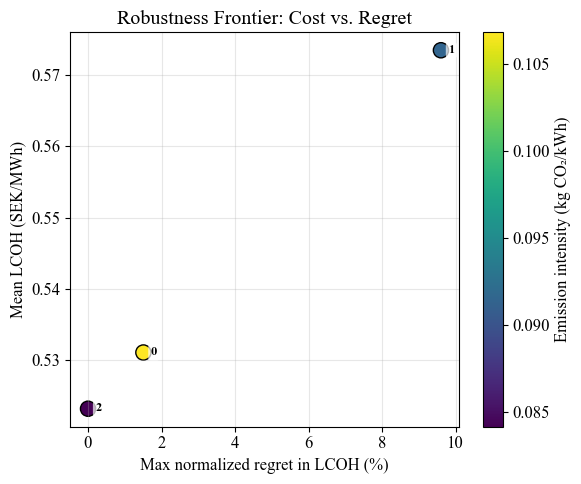

In [50]:
# --- Cell 7: Robustness frontier scatter plot ---

import matplotlib.pyplot as plt

# merge for plotting
frontier = (regret_summary_norm
            .merge(cluster_perf, on="cluster", how="left"))

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(frontier["max_regret_cost_%"],
                frontier["LCOH"],
                c=frontier["EmissionsIntensity"],
                s=120,
                cmap="viridis",
                edgecolor="black")

# --- Improved label placement for better readability ---
for _, r in frontier.iterrows():
    ax.text(r["max_regret_cost_%"] + 0.2,   # horizontal offset
            r["LCOH"],                  # vertical offset
            str(int(r["cluster"])),
            fontsize=9,
            weight="bold",
            va="center",
            ha="left",
            color="black",
            path_effects=[],
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

ax.set_xlabel("Max normalized regret in LCOH (%)")
ax.set_ylabel("Mean LCOH (SEK/MWh)")
ax.set_title("Robustness Frontier: Cost vs. Regret")
plt.colorbar(sc, label="Emission intensity (kg CO₂/kWh)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔹 Step 8 – Build Annual KPI Timeseries for Adaptive Triggers

**Purpose**  
Create a per–scenario × year KPI table combining:
- Cost & emissions: `LCOH`, `EmissionIntensity` (from your existing timeseries files)
- Technology mix signals (computed from heat generation):
  - `hp_share` (all heat pumps)
  - `share_electric_boiler`
  - `biomass_share` (Bio oil/wood/pellet/CHP/HOB)
  - `share_msw` (waste incineration)
  - `share_excess` (data centre / sewage / sea-water / low-temp source HPs)

**Inputs**
- `aggregates/heat_generation_long.csv` with columns: `Scenario, Year, Technology, GWh`
- `analysis/lcoh_timeseries.csv` (Scenario–Year–LCOH)
- `analysis/emissions_timeseries.csv` (Scenario–Year–EmissionIntensity)
- `DTW_results/totcap_dtw_labels.csv` (for optional cluster join later)

**Outputs**
- `analysis/feature_heat_kpi_timeseries.csv`:


In [51]:
# --- Build KPI timeseries (compact & robust) ---

import pandas as pd
import numpy as np
import re
from pathlib import Path

# Paths
HEAT_LONG = Path("aggregates/heat_generation_long.csv")
LCOH_TS   = Path("analysis/lcoh_timeseries.csv")
EMIS_TS   = Path("analysis/emissions_timeseries.csv")
LABELS    = Path("DTW_results/totcap_dtw_labels.csv")  # optional
OUT_PATH  = Path("analysis/feature_heat_kpi_timeseries.csv")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# --- Load heat generation long ---
heat = pd.read_csv(HEAT_LONG)
heat.columns = [c.strip() for c in heat.columns]
heat = heat.rename(columns={"Scenario":"scenario","Year":"year","Technology":"technology","GWh":"GWh"})
heat["scenario"] = heat["scenario"].astype(str).str.strip()
# years like 2023 or 2023.0
heat["year"] = pd.to_numeric(heat["year"], errors="coerce").round().astype("Int64")
heat = heat.dropna(subset=["year"]).copy()
heat["year"] = heat["year"].astype(int)
heat["technology"] = heat["technology"].astype(str).str.strip()
heat["GWh"] = pd.to_numeric(heat["GWh"], errors="coerce").fillna(0.0)

# --- Category mapping via regex (adjust patterns if your labels differ) ---
def is_in(name, patterns):
    s = str(name).lower()
    return any(p.search(s) for p in patterns)

rx = {
    "hp": [
        re.compile(r"heat\s*pump"),
    ],
    "eb": [
        re.compile(r"electric\s*boiler"),
    ],
    "biomass": [
        re.compile(r"\bbio\b"), re.compile(r"wood"), re.compile(r"pellet"), re.compile(r"chips"),
        re.compile(r"bio\s*oil"), re.compile(r"bio\s*pellets"),
    ],
    "msw": [
        re.compile(r"waste\s*incineration"),
    ],
    # excess sources (subset of HPs tied to specific sources)
    "excess_hp": [
        re.compile(r"data\s*centre"), re.compile(r"sewage"), re.compile(r"sea\s*water"),
        re.compile(r"low\s*temperature\s*source"),
    ],
}

# Tag each technology once (booleans)
heat["is_hp"]  = heat["technology"].apply(lambda x: is_in(x, rx["hp"]))
heat["is_eb"]  = heat["technology"].apply(lambda x: is_in(x, rx["eb"]))
heat["is_bm"]  = heat["technology"].apply(lambda x: is_in(x, rx["biomass"]))
heat["is_msw"] = heat["technology"].apply(lambda x: is_in(x, rx["msw"]))
heat["is_excesshp"] = heat["technology"].apply(lambda x: is_in(x, rx["excess_hp"]))

# --- Aggregate per Scenario–Year ---
tot = (heat.groupby(["scenario","year"], as_index=False)["GWh"].sum().rename(columns={"GWh":"total_heat"}))

def share_from_flag(flag_col):
    part = (heat[["scenario","year","GWh",flag_col]]
            .assign(part=lambda d: np.where(d[flag_col], d["GWh"], 0.0))
            .groupby(["scenario","year"], as_index=False)["part"].sum())
    return part

hp   = share_from_flag("is_hp").rename(columns={"part":"hp_gwh"})
eb   = share_from_flag("is_eb").rename(columns={"part":"eb_gwh"})
bm   = share_from_flag("is_bm").rename(columns={"part":"bm_gwh"})
msw  = share_from_flag("is_msw").rename(columns={"part":"msw_gwh"})
exhp = share_from_flag("is_excesshp").rename(columns={"part":"exhp_gwh"})

kpi = tot.merge(hp,  on=["scenario","year"], how="left") \
         .merge(eb,  on=["scenario","year"], how="left") \
         .merge(bm,  on=["scenario","year"], how="left") \
         .merge(msw, on=["scenario","year"], how="left") \
         .merge(exhp,on=["scenario","year"], how="left")

for c in ["hp_gwh","eb_gwh","bm_gwh","msw_gwh","exhp_gwh"]:
    kpi[c] = kpi[c].fillna(0.0)

# shares
den = kpi["total_heat"].replace(0, np.nan)
kpi["hp_share"]                = (kpi["hp_gwh"]   / den).fillna(0.0)
kpi["share_electric_boiler"]   = (kpi["eb_gwh"]   / den).fillna(0.0)
kpi["biomass_share"]           = (kpi["bm_gwh"]   / den).fillna(0.0)
kpi["share_msw"]               = (kpi["msw_gwh"]  / den).fillna(0.0)
kpi["share_excess"]            = (kpi["exhp_gwh"] / den).fillna(0.0)

# --- Merge LCOH timeseries ---
lcoh_ts = pd.read_csv(LCOH_TS)
lcoh_ts.columns = [c.strip().lower() for c in lcoh_ts.columns]
lcoh_ts = lcoh_ts.rename(columns={
    "scenario":"scenario",
    "year":"year",
    # accept common names
    "lcoh_sek_per_kwh":"LCOH", "lcoh_sek_per_mwh":"LCOH", "lcoh":"LCOH"
})
# coerce types
lcoh_ts["scenario"] = lcoh_ts["scenario"].astype(str).str.strip()
lcoh_ts["year"] = pd.to_numeric(lcoh_ts["year"], errors="coerce").round().astype("Int64")
lcoh_ts = lcoh_ts.dropna(subset=["year"]).copy()
lcoh_ts["year"] = lcoh_ts["year"].astype(int)
lcoh_ts["LCOH"] = pd.to_numeric(lcoh_ts["LCOH"], errors="coerce")

# --- Merge Emissions timeseries ---
emis_ts = pd.read_csv(EMIS_TS)
emis_ts.columns = [c.strip().lower() for c in emis_ts.columns]
emis_ts = emis_ts.rename(columns={
    "scenario":"scenario",
    "year":"year",
    "emission_intensity_kg_per_kwh":"EmissionIntensity",
    "emissions_intensity_kg_per_kwh":"EmissionIntensity",
    "emis_intensity":"EmissionIntensity"
})
emis_ts["scenario"] = emis_ts["scenario"].astype(str).str.strip()
emis_ts["year"] = pd.to_numeric(emis_ts["year"], errors="coerce").round().astype("Int64")
emis_ts = emis_ts.dropna(subset=["year"]).copy()
emis_ts["year"] = emis_ts["year"].astype(int)
emis_ts["EmissionIntensity"] = pd.to_numeric(emis_ts["EmissionIntensity"], errors="coerce")

# --- Harmonize scenario IDs (numeric/label) via cluster labels (optional but robust) ---
if LABELS.exists():
    lbl = pd.read_csv(LABELS)
    # numeric key for join
    def scen_num(x):
        m = re.search(r"(\d+)", str(x))
        return int(m.group(1)) if m else np.nan
    lbl["scen_num"] = lbl["Scenario"].apply(scen_num)
    kpi["scen_num"] = kpi["scenario"].apply(scen_num)
    lcoh_ts["scen_num"] = lcoh_ts["scenario"].apply(scen_num)
    emis_ts["scen_num"] = emis_ts["scenario"].apply(scen_num)

    # prefer the pretty label from labels file
    kpi = (kpi.merge(lbl[["scen_num","Scenario"]].drop_duplicates(), on="scen_num", how="left")
              .rename(columns={"Scenario":"scenario_label"}))
    lcoh_ts = (lcoh_ts.merge(lbl[["scen_num","Scenario"]].drop_duplicates(), on="scen_num", how="left")
                      .rename(columns={"Scenario":"scenario_label"}))
    emis_ts = (emis_ts.merge(lbl[["scen_num","Scenario"]].drop_duplicates(), on="scen_num", how="left")
                      .rename(columns={"Scenario":"scenario_label"}))

    # choose a unified scenario id
    for df in (kpi, lcoh_ts, emis_ts):
        df["scenario_u"] = df["scenario_label"].fillna(df["scenario"]).astype(str).str.strip()
else:
    for df in (kpi, lcoh_ts, emis_ts):
        df["scenario_u"] = df["scenario"].astype(str).str.strip()

# --- Merge all KPIs into one timeseries ---
kpi_ts = (kpi.rename(columns={"scenario_u":"Scenario","year":"Year"})
             [["Scenario","Year","total_heat","hp_share","share_electric_boiler",
               "biomass_share","share_msw","share_excess"]]
          .merge(lcoh_ts.rename(columns={"scenario_u":"Scenario","year":"Year","LCOH":"LCOH"}),
                 on=["Scenario","Year"], how="left")
          .merge(emis_ts.rename(columns={"scenario_u":"Scenario","year":"Year","EmissionIntensity":"EmissionIntensity"}),
                 on=["Scenario","Year"], how="left"))

# Save
kpi_ts.to_csv(OUT_PATH, index=False)
print(f"✅ Saved KPI timeseries → {OUT_PATH.resolve()}")
print(kpi_ts.head(8))

✅ Saved KPI timeseries → C:\Paper 4\Outputs\Raw\analysis\feature_heat_kpi_timeseries.csv
            Scenario  Year   total_heat  hp_share  share_electric_boiler  \
0  LTLE_scenario_001  2023  8191.427387  0.176282               0.009278   
1  LTLE_scenario_001  2024  8135.762628  0.147708               0.007473   
2  LTLE_scenario_001  2025  8157.299838  0.149567               0.005963   
3  LTLE_scenario_001  2026  8173.295707  0.167703               0.004761   
4  LTLE_scenario_001  2027  8151.172148  0.184970               0.003819   
5  LTLE_scenario_001  2028  7965.775848  0.218878               0.008223   
6  LTLE_scenario_001  2029  7959.736712  0.256374               0.006811   
7  LTLE_scenario_001  2030  7969.454728  0.317151               0.005387   

   biomass_share  share_msw  share_excess scenario_x      LCOH  scen_num_x  \
0       0.497882   0.316558      0.176282          1  0.443631           1   
1       0.455169   0.389649      0.147708          1  0.381956        

## 🔹 Step 8A — Rank Early Indicators (Years 1–3)

**Purpose**
Find the *earliest* signals that best differentiate clusters — candidates for decision triggers.

**Inputs**
`analysis/feature_heat_kpi_timeseries.csv`, `DTW_results/totcap_dtw_labels.csv`

**Method**
1) Merge KPIs ↔ cluster labels  
2) Keep first 3 years from model start  
3) Rank numeric indicators by between-cluster / overall variance ratio

**Output**
`indicator_rank` (top signals)

In [52]:
# --- Cell 8A: Rank early indicators ---

import pandas as pd
import numpy as np
import re

# load KPI timeseries
kpi_ts = pd.read_csv("analysis/feature_heat_kpi_timeseries.csv")
kpi_ts.columns = [c.strip() for c in kpi_ts.columns]
kpi_ts.rename(columns={"Scenario":"scenario","Year":"year"}, inplace=True)

# merge clusters (via numeric scen id)
lbl = pd.read_csv("DTW_results/totcap_dtw_labels.csv")
lbl["scen_num"] = lbl["Scenario"].str.extract(r"(\d+)").astype(int)
kpi_ts["scen_num"] = kpi_ts["scenario"].str.extract(r"(\d+)").astype(int)
df = kpi_ts.merge(lbl[["scen_num","Cluster"]].rename(columns={"Cluster":"cluster"}), on="scen_num", how="left")
df = df.dropna(subset=["cluster"]).copy()
df["cluster"] = df["cluster"].astype(int)

# early window (first 3 model years)
y0 = int(df["year"].min())
early = df[df["year"].between(y0, y0+2)].copy()

# candidate numeric columns (exclude cost/emissions if you prefer pure operational signals)
exclude = {"scenario_x","year","scen_num_x","cluster","scen_num_y","scenario_y", "scen_num"}
numcols = [c for c in early.columns if early[c].dtype != "object" and c not in exclude]

def var_ratio(col):
    ov = early[col].var()
    bt = early.groupby("cluster")[col].mean().var()
    return float(bt) / (float(ov) + 1e-12)

indicator_rank = (pd.DataFrame({"indicator": numcols,
                                "var_ratio": [var_ratio(c) for c in numcols]})
                  .sort_values("var_ratio", ascending=False, ignore_index=True))

print("Top early indicators (by between/overall variance):")
display(indicator_rank.head(8))

Top early indicators (by between/overall variance):


,indicator,var_ratio
0,EmissionIntensity,0.793998
1,hp_share,0.409966
2,share_excess,0.409966
3,total_heat,0.264624
4,share_msw,0.219577
5,biomass_share,0.051468
6,LCOH,0.049387
7,share_electric_boiler,0.003723


In [53]:
df

,scenario,year,total_heat,hp_share,share_electric_boiler,biomass_share,share_msw,share_excess,scenario_x,LCOH,scen_num_x,scenario_label_x,scenario_y,EmissionIntensity,scen_num_y,scenario_label_y,scen_num,cluster
0,LTLE_scenario_001,2023,8191.427387,0.176282,0.009278,0.497882,0.316558,0.176282,1,0.443631,1,LTLE_scenario_001,1.0,0.092694,1.0,LTLE_scenario_001,1,0
1,LTLE_scenario_001,2024,8135.762628,0.147708,0.007473,0.455169,0.389649,0.147708,1,0.381956,1,LTLE_scenario_001,1.0,0.127896,1.0,LTLE_scenario_001,1,0
2,LTLE_scenario_001,2025,8157.299838,0.149567,0.005963,0.433325,0.411145,0.149567,1,0.339397,1,LTLE_scenario_001,1.0,0.139321,1.0,LTLE_scenario_001,1,0
3,LTLE_scenario_001,2026,8173.295707,0.167703,0.004761,0.405609,0.421927,0.167703,1,0.304679,1,LTLE_scenario_001,1.0,0.145230,1.0,LTLE_scenario_001,1,0
4,LTLE_scenario_001,2027,8151.172148,0.184970,0.003819,0.384774,0.426437,0.184970,1,0.276086,1,LTLE_scenario_001,1.0,0.145770,1.0,LTLE_scenario_001,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5503,LTLE_scenario_378,2045,7603.266300,0.471907,0.021149,0.348966,0.157978,0.471907,378,0.173471,378,LTLE_scenario_378,378.0,0.060250,378.0,LTLE_scenario_378,378,0
5504,LTLE_scenario_378,2046,7589.973227,0.479955,0.023051,0.348149,0.148844,0.479955,378,0.146628,378,LTLE_scenario_378,378.0,0.056506,378.0,LTLE_scenario_378,378,0
5505,LTLE_scenario_378,2047,7576.703395,0.487533,0.023092,0.350086,0.139289,0.487533,378,0.139993,378,LTLE_scenario_378,378.0,0.051658,378.0,LTLE_scenario_378,378,0
5506,LTLE_scenario_378,2048,7563.456763,0.493531,0.023132,0.352152,0.131185,0.493531,378,0.133176,378,LTLE_scenario_378,378.0,0.047862,378.0,LTLE_scenario_378,378,0


## 🔹 Step 8B/C — Triggers, Decision Matrix, and Monitoring Timeline

**Purpose**
Turn the top signals into **numerical triggers**, and map them into a **decision matrix** and a **timeline**.

**Method**
- Take top-3 indicators  
- Compute cluster medians (early years), derive **midpoint thresholds**  
- Build a lightweight **decision matrix** (fill strategy text later)  
- Create a **monitoring timeline** (Y₀–Y₀+2, Y₀+3, Y₀+4–6, Y₀+7)

**Outputs**
- `trigger_table` (indicator, threshold, low→high cluster)  
- `decision_matrix` (cluster, probs, early signals, trigger summary)  
- `monitor_timeline` (window, focus, notes)

In [54]:
# --- Cell 8B/C: Triggers + Decision Matrix + Timeline (compact) ---

# Rebuild from total capacity wide file
totcap_wide = pd.read_csv("aggregates/totcap_plans_wide.csv")
scenarios = totcap_wide["Scenario"].astype(str).tolist()
years = [c for c in totcap_wide.columns if c not in ["Scenario"]]

# Convert to (N, T, 1) for univariate DTW (total capacity trajectories)
X3 = totcap_wide[years].values[:, :, np.newaxis]


# choose top-3 indicators (prefer operational: shares; drop LCOH/Emissions if listed)
prefer = ["hp_share","share_excess","biomass_share","EmissionIntensity","share_msw"]
topk = [ind for ind in indicator_rank["indicator"].tolist() if ind in prefer][:3]
if len(topk) < 3:
    # backfill with next best
    for ind in indicator_rank["indicator"]:
        if ind not in topk:
            topk.append(ind)
        if len(topk) == 3: break

# cluster medians for early window
med = (early.groupby("cluster")[topk].median().sort_index())

# thresholds = midpoints of adjacent cluster medians (per indicator)
def midpoint_rows(series, name):
    s = series.sort_values()
    rows = []
    for (c1, v1), (c2, v2) in zip(s.iloc[:-1].items(), s.iloc[1:].items()):
        rows.append({"indicator": name,
                     "low_cluster": int(c1),
                     "high_cluster": int(c2),
                     "threshold": float((v1+v2)/2)})
    return rows

trigger_table = pd.DataFrame([r for ind in topk for r in midpoint_rows(med[ind], ind)])

# decision matrix scaffold
cl_probs = (df["cluster"].value_counts(normalize=True)
            .rename_axis("cluster").reset_index(name="probability")
            .sort_values("cluster"))

def fmt_signals(c):
    vals = med.loc[c, topk].to_dict()
    return ", ".join([f"{k}≈{v:.3f}" for k,v in vals.items()])

def fmt_trigger_summary(ind):
    sub = trigger_table[trigger_table["indicator"] == ind].sort_values("threshold")
    return "; ".join([f"{ind} ≥ {r.threshold:.3f} → C{r.high_cluster}" for _, r in sub.iterrows()])

decision_matrix = cl_probs.assign(
    core_strategy="",  # fill narrative later (cluster-specific pathway)
    early_signals=lambda d: d["cluster"].map(fmt_signals),
    triggers=" | ".join([fmt_trigger_summary(k) for k in topk])
)

# monitoring timeline
Y0 = int(df["year"].min())
monitor_timeline = pd.DataFrame([
    (f"Years {Y0}-{Y0+2}", "Monitor early indicators",
     f"Track {', '.join(topk)}; validate direction vs cluster medians"),
    (f"Year {Y0+3}", "Decision checkpoint 1",
     "Apply thresholds; align Stage-2 investments to indicated cluster"),
    (f"Years {Y0+4}-{Y0+6}", "Refine staging",
     "Scale/sequence mid-term techs (Pellets CHP, DC HPs) if signals persist"),
    (f"Year {Y0+7}", "Decision checkpoint 2",
     "Re-evaluate regret frontier with updated costs & emissions"),
], columns=["Window","Focus","Notes"])

print("Top-3 indicators used:", topk)
print("\nTrigger table:")
display(trigger_table)

print("\nDecision matrix (fill 'core_strategy' later):")
display(decision_matrix)

print("\nMonitoring & decision timeline:")
display(monitor_timeline)

trigger_table.to_csv("analysis/feature_heat_trigger_table.csv", index=False)
decision_matrix.to_csv("analysis/feature_heat_decision_matrix.csv", index=False)
monitor_timeline.to_csv("analysis/feature_heat_monitoring_timeline.csv", index=False)
print("✅ Saved trigger table and decision matrix CSVs.")

Top-3 indicators used: ['EmissionIntensity', 'hp_share', 'share_excess']

Trigger table:


,indicator,low_cluster,high_cluster,threshold
0,EmissionIntensity,2,0,0.110325
1,EmissionIntensity,0,1,0.127519
2,hp_share,0,2,0.157453
3,hp_share,2,1,0.169356
4,share_excess,0,2,0.157453
5,share_excess,2,1,0.169356



Decision matrix (fill 'core_strategy' later):


,cluster,probability,core_strategy,early_signals,triggers
0,0,0.740196,,"EmissionIntensity≈0.112, hp_share≈0.153, share...",EmissionIntensity ≥ 0.110 → C0; EmissionIntens...
1,1,0.220588,,"EmissionIntensity≈0.143, hp_share≈0.177, share...",EmissionIntensity ≥ 0.110 → C0; EmissionIntens...
2,2,0.039216,,"EmissionIntensity≈0.109, hp_share≈0.162, share...",EmissionIntensity ≥ 0.110 → C0; EmissionIntens...



Monitoring & decision timeline:


,Window,Focus,Notes
0,Years 2023-2025,Monitor early indicators,"Track EmissionIntensity, hp_share, share_exces..."
1,Year 2026,Decision checkpoint 1,Apply thresholds; align Stage-2 investments to...
2,Years 2027-2029,Refine staging,"Scale/sequence mid-term techs (Pellets CHP, DC..."
3,Year 2030,Decision checkpoint 2,Re-evaluate regret frontier with updated costs...


✅ Saved trigger table and decision matrix CSVs.


## 🔹 Step 9A — Cluster Stability Check (k = 2 vs 3 vs 4)

**Purpose**  
Assess how stable your scenario clustering is when changing the number of clusters.

**Method**
1. Re-run DTW clustering on total capacities (same preprocessed cube).  
2. Compare label sets (k = 2, 3, 4) pairwise using **Adjusted Rand Index (ARI)**.  
   - ARI ≈ 1 → highly stable  
   - ARI ≈ 0 → random reassignment (unstable)
3. Visualize transitions (how scenarios move between cluster IDs).

**Outputs**
- `stability_table`: ARI values between (k=2,3,4)
- Transition summary table (how scenarios move)

In [55]:
# --- Step 9A: Cluster stability check ---

import pandas as pd
import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from sklearn.metrics import adjusted_rand_score

# Use the same total capacity cube from your DTW setup (X3, scenarios, years)
# Assuming X3, scenarios already exist in memory
# If not, reload the processed dataset you used earlier for clustering.

# Safety check
assert "X3" in globals(), "X3 (time-series cube) not found; rerun DTW preprocessing cell first."
assert "scenarios" in globals(), "Scenario list missing."

def run_dtw_cluster(X, k, random_state=42):
    model = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=random_state, verbose=False)
    labels = model.fit_predict(X)
    return pd.Series(labels, index=scenarios, name=f"k{k}")

# Compute clustering for k = 2, 3, 4
k_values = [2, 3, 4]
label_df = pd.concat([run_dtw_cluster(X3, k) for k in k_values], axis=1)

# Compare all pairs via Adjusted Rand Index
pairs = [(a,b) for i,a in enumerate(label_df.columns) for b in label_df.columns[i+1:]]
stability = []
for a,b in pairs:
    ari = adjusted_rand_score(label_df[a], label_df[b])
    stability.append({"pair": f"{a} vs {b}", "ARI": ari})

stability_table = pd.DataFrame(stability)
display(stability_table)

# Transition summary (k=3 base)
if "k3" in label_df.columns:
    base = label_df["k3"]
    transitions = pd.crosstab(base, label_df["k4"], normalize="index")
    print("\nTransition matrix (k3 → k4):")
    display(transitions)


,pair,ARI
0,k2 vs k3,0.578952
1,k2 vs k4,0.454592
2,k3 vs k4,0.752055



Transition matrix (k3 → k4):


k4,0,1,2,3
k3,,,,
0,0.890027,0.000000,0.000000,0.109973
1,0.000655,0.703801,0.015072,0.280472
2,0.000000,0.102492,0.897508,0.000000


## 🔹 Step 9B — Feature Influence on Clustering

**Purpose**
Quantify which variables most explain the DTW clusters.

**Method**
1. Merge your cluster labels with a feature dataset (`feature_heat_kpi_timeseries.csv` or `totalcapacity_plans_wide.csv`).
2. Collapse over time by taking mean values per scenario (so each scenario → one feature vector).
3. Train a **Random Forest Classifier** (or other simple model) to predict cluster labels.
4. Extract and rank **feature importances**.

**Outputs**
- `importance_df`: variable importance ranking  
- Bar plot of top drivers (interpretable “cluster fingerprint”)

Top features influencing cluster separation:


,feature,importance
0,hp_share,0.213895
1,lcoh,0.206921
2,share_excess,0.196873
3,biomass_share,0.193621
4,share_electric_boiler,0.141609
5,total_heat,0.020382
6,share_msw,0.015016
7,emissionintensity,0.011682


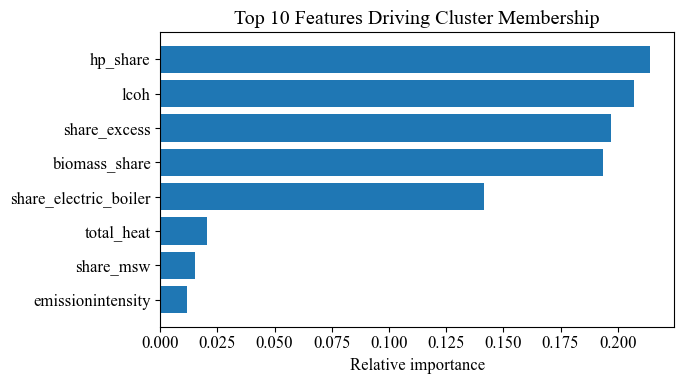

In [56]:
# --- Step 9B: Feature influence on clustering ---

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from matplotlib import rcParams
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12

# --- Load scenario-level features (use annual KPIs for rich info)
feat = pd.read_csv("analysis/feature_heat_kpi_timeseries.csv")
feat.columns = [c.strip().lower() for c in feat.columns]
feat.rename(columns={"scenario":"Scenario","year":"Year"}, inplace=True)

# Merge cluster labels
lbl = pd.read_csv("DTW_results/totcap_dtw_labels.csv")
lbl["scen_num"] = lbl["Scenario"].str.extract(r"(\d+)").astype(int)
feat["scen_num"] = feat["Scenario"].str.extract(r"(\d+)").astype(int)
feat = feat.merge(lbl[["scen_num","Cluster"]].rename(columns={"Cluster":"cluster"}), on="scen_num", how="left")
feat = feat.dropna(subset=["cluster"]).copy()
feat["cluster"] = feat["cluster"].astype(int)

# keep only numeric features for the average
numcols = (feat.select_dtypes(include="number")
              .columns.difference(["Year", "scen_num", "cluster"]))

agg = feat.groupby("Scenario", as_index=False)[numcols].mean()

# add cluster label (one per Scenario)
agg = agg.merge(lbl[["Scenario","Cluster"]].rename(columns={"Cluster":"cluster"}),
                on="Scenario", how="left")

# numeric-only features, no target leakage
X = agg.select_dtypes(include="number").drop(columns=["cluster"], errors="ignore")
y = agg["cluster"].astype(int)


# Drop any feature column whose name includes 'scen' (e.g., scen_num)
X = X.loc[:, ~X.columns.str.contains("scen", case=False)]

# 1) drop columns with too much missing
col_missing = X.isna().mean()
X = X.loc[:, col_missing <= 0.30]  # keep columns with ≤30% missing

# 2) median-impute remaining NaNs
X = X.fillna(X.median(numeric_only=True))

# 3) if any residual NaNs (rare), drop those rows
row_mask = X.isna().any(axis=1)
if row_mask.any():
    X = X.loc[~row_mask].copy()
    y = y.loc[~row_mask].copy()


# --- Train random forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X, y)

importance_df = (pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False, ignore_index=True))

print("Top features influencing cluster separation:")
display(importance_df.head(10))

# --- Plot ---
plt.figure(figsize=(7,4))
plt.barh(importance_df["feature"].head(10)[::-1],
         importance_df["importance"].head(10)[::-1])
plt.xlabel("Relative importance")
plt.title("Top 10 Features Driving Cluster Membership")
plt.tight_layout()
plt.show()

## 🔹 Step 10 — Cluster Summary Dashboard

**Purpose**  
Create a single, tidy table per cluster that you can export and share. It combines:
- Performance: mean **LCOH** and **emission intensity**
- Scale: cluster **probability** (scenario share)
- Early signals (medians in first 3 years): **hp_share**, **share_excess**, **biomass_share**, **share_electric_boiler**, **share_msw**
- Trigger summary (from Step 8B)
- Robust plan staging (Stage 1 & Stage 2 techs)

**Output**
- `DTW_results/cluster_summary_dashboard.csv`


How to read it

- probability = share of scenarios in each cluster

- LCOH / EmissionsIntensity = representative performance

- hp_share / share_excess / biomass_share / … = typical early mix signals (medians over first 3 years)

- triggers = human-readable thresholds you can quote (from Step 8B)

- stage1_robust / stage2_conditional = the staged plan you derived earlier

In [57]:
# --- Step 10: Cluster Summary Dashboard (compact) ---

import pandas as pd
from pathlib import Path

OUT = Path("DTW_results/cluster_summary_dashboard.csv")

# 1) Source data
# - cluster_perf: cluster | LCOH | EmissionsIntensity  (from regret step)
# - cluster_map  : scenario | cluster                  (already loaded)
# - KPI time series: Scenario,Year,hp_share,...        (built earlier)
if "cluster_perf" not in globals():
    raise RuntimeError("cluster_perf not found. Run the regret prep cell first.")

kpi_ts = pd.read_csv("analysis/feature_heat_kpi_timeseries.csv")
kpi_ts = kpi_ts.rename(columns={"Scenario":"scenario","Year":"year"})
lbl = pd.read_csv("DTW_results/totcap_dtw_labels.csv").rename(columns={"Cluster":"cluster"})

# harmonize IDs via numeric key
kpi_ts["scen_num"] = kpi_ts["scenario"].str.extract(r"(\d+)").astype(int)
lbl["scen_num"]    = lbl["Scenario"].str.extract(r"(\d+)").astype(int)

df = (kpi_ts.merge(lbl[["scen_num","cluster"]], on="scen_num", how="left")
             .dropna(subset=["cluster"]).copy())
df["cluster"] = df["cluster"].astype(int)

# 2) Early window (first 3 model years) & early medians per cluster
y0 = int(df["year"].min())
early = df[df["year"].between(y0, y0+2)].copy()

sig_cols = ["hp_share","share_excess","biomass_share","share_electric_boiler","share_msw"]
for c in sig_cols:
    if c not in early.columns:
        early[c] = 0.0  # ensure column exists (failsafe)

early_med = (early.groupby("cluster")[sig_cols].median().reset_index())

# 3) Cluster probabilities
lbl.rename(columns={"Scenario":"scenario", "Cluster":"cluster"}, inplace=True)
# now both dataframes have 'scenario' (lowercase)
cl_probs = (cluster_map.assign(cluster=lambda d: d["cluster"].astype(int))
            ["cluster"]
            .value_counts(normalize=True)
            .rename_axis("cluster")
            .reset_index(name="probability")
            .sort_values("cluster")
            .reset_index(drop=True))

# 4) Trigger summary (from Step 8B). If not present, leave empty.
def trigger_summary_from_table(trigger_table, order=tuple(sig_cols)):
    if "trigger_table" not in globals():
        return ""
    out = []
    tt = trigger_table.copy()
    for ind in order:
        if ind not in tt["indicator"].unique():
            continue
        sub = tt[tt["indicator"]==ind].sort_values("threshold")
        parts = [f"{ind} ≥ {r.threshold:.3f} → C{int(r.high_cluster)}" for _, r in sub.iterrows()]
        if parts:
            out.append("; ".join(parts))
    return " | ".join(out)

trig_text = trigger_summary_from_table(globals().get("trigger_table", None)) if "trigger_table" in globals() else ""

# 5) Robust plan staging (Stage 1 & 2 techs) — reuse staged_plan if available
stage1_list, stage2_list = [], []
if "staged_plan" in globals():
    s1 = staged_plan[staged_plan["stage"].str.contains("Immediate", na=False)]
    s2 = staged_plan[staged_plan["stage"].str.contains("Mid-term", na=False)]
    stage1_list = s1["commit_techs"].iloc[0] if not s1.empty else []
    stage2_list = s2["commit_techs"].iloc[0] if not s2.empty else []

stage1_txt = ", ".join(stage1_list) if stage1_list else ""
stage2_txt = ", ".join(stage2_list) if stage2_list else ""

# 6) Assemble dashboard
dashboard = (
    cl_probs
      .merge(cluster_perf, on="cluster", how="left")
      .merge(early_med, on="cluster", how="left")
      .assign(triggers=trig_text,
              stage1_robust=stage1_txt,
              stage2_conditional=stage2_txt)
      .sort_values("cluster")
)

# 7) Save and show
OUT.parent.mkdir(parents=True, exist_ok=True)
dashboard.to_csv(OUT, index=False)
print(f"✅ Saved cluster summary dashboard → {OUT.resolve()}")
display(dashboard.round(3))


✅ Saved cluster summary dashboard → C:\Paper 4\Outputs\Raw\DTW_results\cluster_summary_dashboard.csv


,cluster,probability,LCOH,EmissionsIntensity,hp_share,share_excess,biomass_share,share_electric_boiler,share_msw,triggers,stage1_robust,stage2_conditional
0,0,0.740,0.531,0.107,0.153,0.153,0.460,0.008,0.380,hp_share ≥ 0.157 → C2; hp_share ≥ 0.169 → C1 |...,Bio Oil HOBs,
1,1,0.221,0.573,0.091,0.177,0.177,0.473,0.008,0.322,hp_share ≥ 0.157 → C2; hp_share ≥ 0.169 → C1 |...,Bio Oil HOBs,
2,2,0.039,0.523,0.084,0.162,0.162,0.455,0.007,0.388,hp_share ≥ 0.157 → C2; hp_share ≥ 0.169 → C1 |...,Bio Oil HOBs,


<Figure size 1000x600 with 0 Axes>

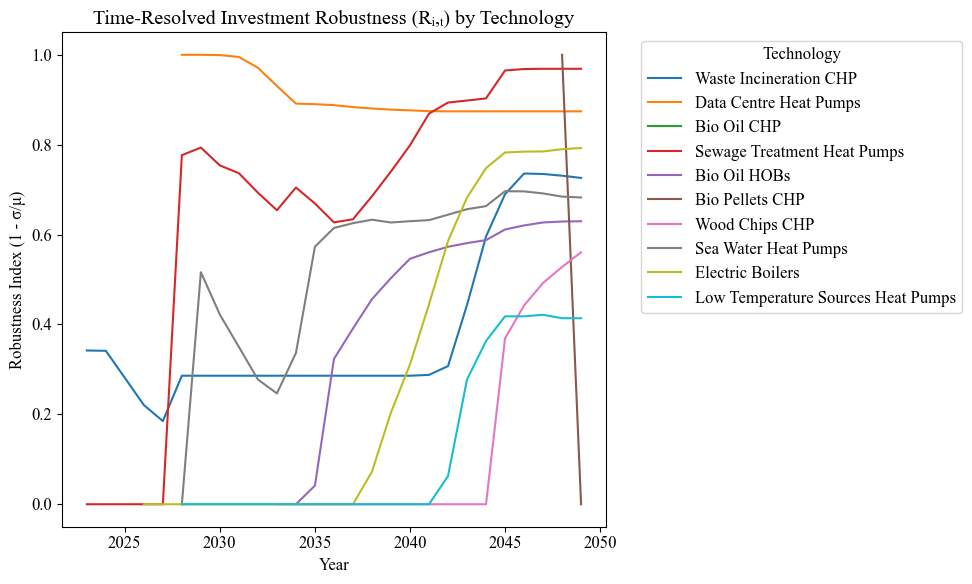

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set global font
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12

# Technology color mapping
tech_colors = {
    'Waste Incineration CHP': '#EF476F',
    'Data Centre Heat Pumps': '#4169E1',
    'Bio Oil CHP': '#FFDA79',
    'Bio Oil HOBs': '#6A4C93',
    'Bio Pellets CHP': '#D3D3D3',
    'Wood Chips CHP': '#4CAF50',
    'Sea Water Heat Pumps': '#56CCF2',
    'Sewage Treatment Heat Pumps': '#F45D01',
    'Electric Boilers': '#B8860B',
    'Low Temperature Sources Heat Pumps': '#EE82EE',
}

# --- Step 11: Time-resolved investment robustness ---

# Load full scenario data (capacity by year)
dfw = pd.read_csv("aggregates/investment_plans_wide.csv")

# Identify technology columns
tech_cols = [c for c in dfw.columns if c not in ["Scenario", "Year"]]

# Compute mean and std per tech per year
mean_by_year = dfw.groupby("Year")[tech_cols].mean()
std_by_year = dfw.groupby("Year")[tech_cols].std()

# Calculate robustness index over time
robustness_by_year = 1 - (std_by_year / mean_by_year.replace(0, float("nan")))

# Clip negatives and upper bound
robustness_by_year = robustness_by_year.clip(lower=0, upper=1)

# Optional: keep only technologies that appear in the color dictionary, in fixed order
ordered_cols = [col for col in tech_colors.keys() if col in robustness_by_year.columns]
remaining_cols = [col for col in robustness_by_year.columns if col not in ordered_cols]
plot_cols = ordered_cols + remaining_cols

robustness_by_year = robustness_by_year[plot_cols]

# Create ordered color list matching plotted columns
colors = [tech_colors.get(col, "#333333") for col in robustness_by_year.columns]

# Save for reference
robustness_by_year.to_csv("aggregates/investment_robustness_by_year.csv")

# Plot
ax = robustness_by_year.plot(figsize=(10, 6), color=colors, linewidth=2)

ax.set_title("Time-Resolved Investment Robustness (Rᵢ,ₜ) by Technology")
ax.set_ylabel("Robustness Index (1 - σ/μ)")
ax.set_xlabel("Year")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Technology')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

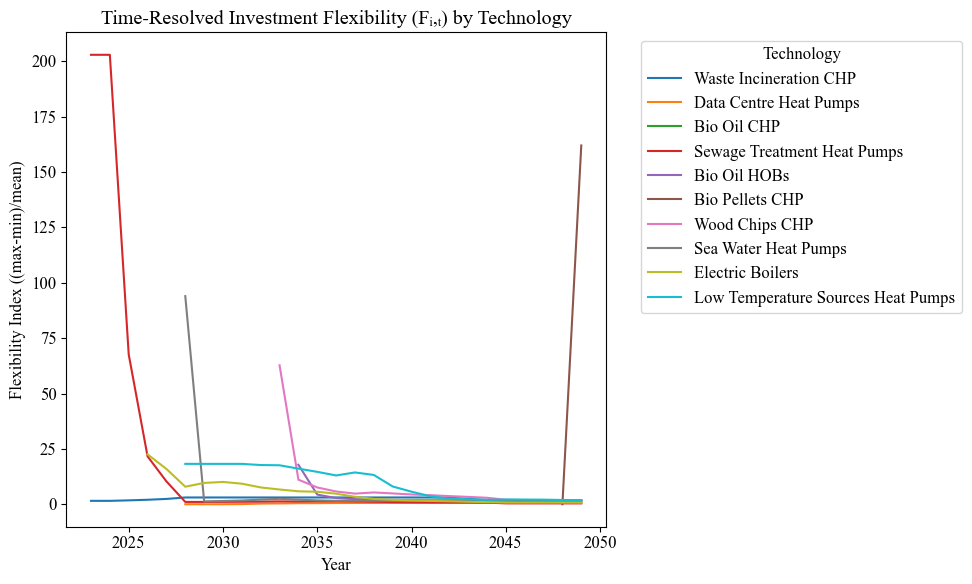

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Load full investment data (all years, all scenarios)
dfw = pd.read_csv("aggregates/investment_plans_wide.csv")

# Identify technology columns
tech_cols = [c for c in dfw.columns if c not in ["Scenario", "Year"]]

# Compute per-year stats across scenarios
mean_by_year = dfw.groupby("Year")[tech_cols].mean()
max_by_year  = dfw.groupby("Year")[tech_cols].max()
min_by_year  = dfw.groupby("Year")[tech_cols].min()

# Compute flexibility index over time
flexibility_by_year = (max_by_year - min_by_year) / mean_by_year.replace(0, float("nan"))

# Clean up numerical issues
flexibility_by_year = flexibility_by_year.replace([float("inf"), -float("inf")], float("nan"))
flexibility_by_year = flexibility_by_year.clip(lower=0)

# Save for reference
flexibility_by_year.to_csv("aggregates/investment_flexibility_by_year.csv")

# Plot
plt.figure(figsize=(10, 6))
flexibility_by_year.plot(figsize=(10,6))
plt.title("Time-Resolved Investment Flexibility (Fᵢ,ₜ) by Technology")
plt.ylabel("Flexibility Index ((max-min)/mean)")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Technology')
plt.tight_layout()
plt.show()

# 🔹 Point 1 — Cross-Technology Robustness (Complementarity vs. Substitution)

**Purpose.**  
Explain *why* the robust mix forms the way it does by quantifying **how technologies co-evolve** across scenarios.  
We treat each **scenario** as a sample, and measure **pairwise correlations** between technologies’ invested capacity (or generation) **within each year**, then average across years to obtain a stable **cross-technology correlation matrix**.

**Intuition.**
- **Positive correlation** → *complements*: technologies tend to be built together (structural synergy).
- **Negative correlation** → *substitutes*: one rises when the other falls (competition for the same role).
- **Near zero** → independent roles or mixed behavior across archetypes.

**What this cell does.**
1. Loads `aggregates/investment_plans_wide.csv` (columns: `Scenario, Year, <tech...>`).  
   *(If you prefer generation, change `SOURCE="capacity"` to `"generation"`; the code supports either.)*
2. For each year, computes the **Pearson correlation** across scenarios between all tech pairs.
3. Averages the yearwise matrices into a **time-averaged correlation matrix** (robust to year-to-year noise).
4. Saves CSV and renders a clean **heatmap** you can cite in the paper.

**Outputs.**
- `DTW_results/cross_tech_corr_capacity.csv` (or `_generation.csv`)
- Heatmap figure: “Cross-Technology Correlation (time-averaged)”

> *Reporting tip:* In Results, cite a few strong positive/negative pairs and relate them to your archetypes (e.g., “HP–EB (+0.62) indicates electrification co-deployment; BioCHP–BioHOBs (−0.48) reveals a transitional substitution.”)

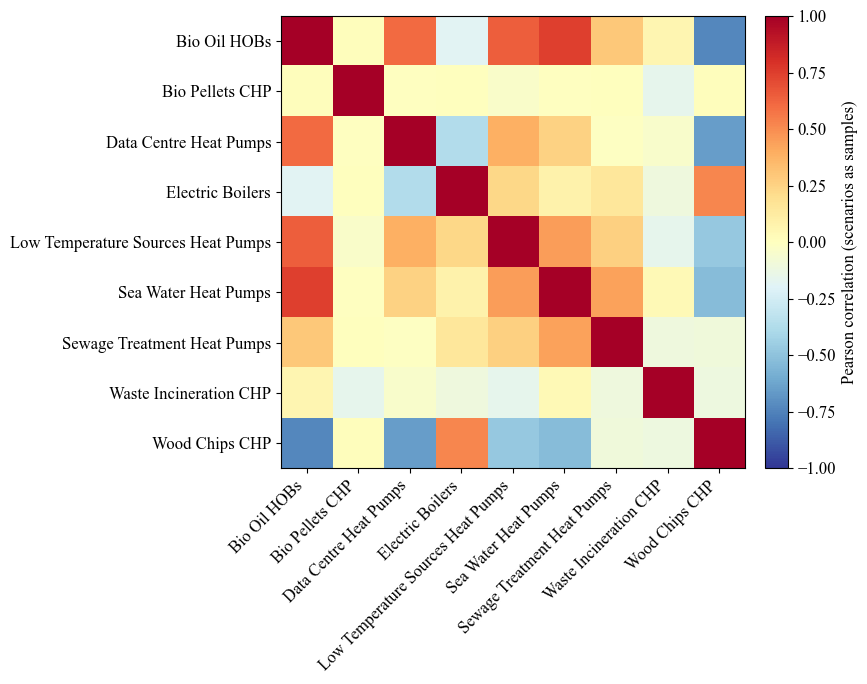

✅ Saved time-averaged cross-technology correlation to: C:\Paper 4\Outputs\Raw\DTW_results\cross_tech_corr_capacity.csv


In [60]:
# --- Point 1: Cross-Technology Robustness (Complementarity vs Substitution) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
from pathlib import Path

# ---------- CONFIG ----------
SOURCE = "capacity"  # "capacity" (investment_plans_wide) or "generation" (heat_generation_wide)
EARLY_WINDOW = None  # e.g., (2023, 2027) to focus on early years; or None for all years
OUT_DIR = Path("DTW_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ---------------------------

if SOURCE == "capacity":
    dfw = pd.read_csv("aggregates/totcap_plans_wide.csv")
    out_csv = OUT_DIR / "cross_tech_corr_capacity.csv"
elif SOURCE == "generation":
    # optional alternative wide file; adapt path if your wide file is named differently
    dfw = pd.read_csv("aggregates/heat_generation_wide.csv")
    out_csv = OUT_DIR / "cross_tech_corr_generation.csv"
else:
    raise ValueError("SOURCE must be 'capacity' or 'generation'.")

# normalize columns
dfw.columns = [c.strip() for c in dfw.columns]
assert {"Scenario", "Year"}.issubset(dfw.columns), "Expected 'Scenario' and 'Year' columns."

# identify technology columns (all non-key columns)
tech_cols = [c for c in dfw.columns if c not in ("Scenario", "Year")]

# remove unwanted techs from correlation analysis
exclude_techs = ["Bio Oil CHP"]
tech_cols = [c for c in tech_cols if c not in exclude_techs]

# restrict to a time window if requested
if EARLY_WINDOW is not None:
    y0, y1 = EARLY_WINDOW
    dfw = dfw[(dfw["Year"] >= y0) & (dfw["Year"] <= y1)].copy()

# compute correlation per year across scenarios (scenarios are samples)
corr_mats = []
years = sorted(dfw["Year"].unique().tolist())

for y in years:
    block = dfw[dfw["Year"] == y]
    # keep only numeric tech columns (defensive) and drop all-NaN columns if any
    X = block[tech_cols].apply(pd.to_numeric, errors="coerce")
    X = X.dropna(axis=1, how="all")
    # if too few scenarios or too few techs, skip this year
    if X.shape[0] < 3 or X.shape[1] < 2:
        continue
    C = X.corr(method="pearson")  # (tech x tech)
    corr_mats.append(C)

if not corr_mats:
    raise RuntimeError("No correlation matrices could be computed. Check input data/window.")

# align and average correlation matrices across years
# (reindex to union of techs to avoid dimension mismatches)
all_techs = sorted(set().union(*[cm.columns for cm in corr_mats]))
corr_stack = []
for C in corr_mats:
    corr_stack.append(C.reindex(index=all_techs, columns=all_techs))

# elementwise mean (ignore NaNs)
corr_avg = pd.concat([c.stack(dropna=False) for c in corr_stack], axis=1).mean(axis=1, skipna=True).unstack()
corr_avg = corr_avg.reindex(index=all_techs, columns=all_techs)

# save
corr_avg.to_csv(out_csv, float_format="%.4f")

# --- Heatmap (matplotlib only, clean, readable) ---
fig, ax = plt.subplots(figsize=(8.8, 7))
im = ax.imshow(corr_avg.values, vmin=-1, vmax=1, cmap="RdYlBu_r", aspect="auto")
ax.set_xticks(range(len(all_techs)))
ax.set_yticks(range(len(all_techs)))
ax.set_xticklabels(all_techs, rotation=45, ha="right")
ax.set_yticklabels(all_techs)
title_src = "Capacity" if SOURCE == "capacity" else "Generation"
win_txt = "" if EARLY_WINDOW is None else f" ({EARLY_WINDOW[0]}–{EARLY_WINDOW[1]})"
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation (scenarios as samples)")
plt.tight_layout()
plt.show()

print(f"✅ Saved time-averaged cross-technology correlation to: {out_csv.resolve()}")

# 🔹 Tech-level LCOH (with 5% discounting) and CVaR

**Goal**  
Compute **technology-level LCOH** per scenario & year using production and cost files, **ignoring negative costs**, **discounting** annual costs at **5%**, then summarize **CVaR** (tail risk) per technology.

**Inputs**
- `ProdByTechAnn.csv` — columns like: `Scenario, Year, Technology, Production_GWh` (name variations handled)
- `TotDiscCostByTech.csv` — columns like: `Scenario, Year, Technology, Cost_SEK` (name variations handled)

**Method**
1. Clean columns, coerce numerics, strip strings.
2. **Ignore negative costs** (`Cost_SEK < 0` → dropped).
3. **Discount** annual costs to the base year \(Y_0=\min(\text{Year})\):  
   \[
   \text{Cost}_{disc} = \frac{\text{Cost}}{(1+0.05)^{(\text{Year}-Y_0)}}
   \]
4. Compute **LCOH\_SEK\_per\_MWh** per `(Scenario, Year, Technology)` as:
   \[
   \text{LCOH} = \frac{\text{Cost}_{disc}}{\text{Production\_GWh} \times 1000}
   \]
5. Export time series and then **aggregate per scenario** (mean across years) to build a distribution per technology.
6. For each technology, compute **CVaR\(_{90}\)** (worst 10% tail) of scenario-level LCOH:
   - VaR\(_{90}\) = 90th percentile of LCOH across scenarios
   - CVaR\(_{90}\) = mean of LCOH values ≥ VaR\(_{90}\)

**Outputs**
- `analysis/lcoh_tech_timeseries.csv` — Scenario × Year × Technology LCOH (SEK/MWh)
- `DTW_results/tech_lcoh_cvar.csv` — per-technology: mean, std, VaR90, CVaR90, n_scenarios

> Tip for the paper: Use CVaR to identify **risk-amplifying** (high CVaR) vs **risk-buffering** (low CVaR) technologies, and cross-reference with robustness/flexibility.


In [61]:
# --- Tech-level LCOH (per scenario, per year) + CVaR(90) per technology ---
# Folder layout:
#   BASE_DIR/
#     LTLE_scenario_001/ProdByTechAnn.csv
#     LTLE_scenario_001/TotDiscCostByTech.csv
#     LTLE_scenario_002/...
#
# Outputs:
#   analysis/lcoh_tech_timeseries.csv
#   DTW_results/tech_lcoh_cvar.csv

import pandas as pd
import numpy as np
from pathlib import Path

# ---------- CONFIG ----------
BASE_DIR = Path(".")  # <-- set this to the parent folder that contains LTLE_scenario_*/
DISCOUNT_RATE = 0.05        # 5% (only applied if costs are not already discounted)
ALPHA = 0.10                # CVaR tail (worst 10%)
OUT_TS  = Path("analysis/lcoh_tech_timeseries.csv")
OUT_SUM = Path("DTW_results/tech_lcoh_cvar.csv")
OUT_TS.parent.mkdir(parents=True, exist_ok=True)
OUT_SUM.parent.mkdir(parents=True, exist_ok=True)
# ---------------------------

# 1) Ingest all scenarios
prod_list, cost_list = [], []
for scen_dir in sorted(BASE_DIR.glob("LTLE_scenario_*")):
    scen_name = scen_dir.name
    f_prod = scen_dir / "ProdByTechAnn.csv"
    f_cost = scen_dir / "TotDiscCostByTech.csv"  # if you have a different cost file name, add elif here
    if not f_prod.exists() or not f_cost.exists():
        continue
    dpp = pd.read_csv(f_prod)
    dpp["__Scenario"] = scen_name
    prod_list.append(dpp)

    dcc = pd.read_csv(f_cost)
    dcc["__Scenario"] = scen_name
    cost_list.append(dcc)

if not prod_list or not cost_list:
    raise RuntimeError("No scenario files found. Check BASE_DIR and file names.")

prod = pd.concat(prod_list, ignore_index=True)
cost = pd.concat(cost_list, ignore_index=True)
print(f"Loaded production rows: {len(prod):,} | cost rows: {len(cost):,} from {len(prod_list)} scenarios")

# 2) Normalize OSeMOSYS-style columns & units
# Keep only the intended records (defensive)
if "NAME" in prod.columns:
    prod = prod[prod["NAME"].astype(str).str.contains("ProdByTechAnn", case=False, na=False)].copy()
if "NAME" in cost.columns:
    # If cost file already totals discounted costs, its NAME typically is 'TotDiscCostByTech'
    cost = cost[cost["NAME"].astype(str).str.contains("Cost", case=False, na=False)].copy()

# Standardize column names
prod = prod.rename(columns={
    "TECHNOLOGY":"Technology", "Year":"YEAR", "year":"YEAR", "YEAR":"Year",
    "VALUE":"Production_TJ", "__Scenario":"Scenario"
})
cost = cost.rename(columns={
    "TECHNOLOGY":"Technology", "Year":"YEAR", "year":"YEAR", "YEAR":"Year",
    "VALUE":"Cost_SEK", "__Scenario":"Scenario"
})

# Coerce types
for df in (prod, cost):
    df["Scenario"]   = df["Scenario"].astype(str).str.strip()
    df["Technology"] = df["Technology"].astype(str).str.strip()
    df["Year"]       = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

prod = prod.dropna(subset=["Year"]).copy(); prod["Year"] = prod["Year"].astype(int)
cost = cost.dropna(subset=["Year"]).copy(); cost["Year"] = cost["Year"].astype(int)

# Units: TJ -> GWh (1 GWh = 3.6 TJ)
prod["Production_TJ"] = pd.to_numeric(prod["Production_TJ"], errors="coerce")
prod["Production_GWh"] = prod["Production_TJ"] / 3.6

# Ignore negative or missing costs
cost["Cost_SEK"] = pd.to_numeric(cost["Cost_SEK"], errors="coerce")
cost = cost[cost["Cost_SEK"].notna() & (cost["Cost_SEK"] >= 0)].copy()

# 3) Discounting (apply only if not already discounted)
# Heuristic: if the cost file path/name contains 'TotDiscCostByTech', treat as already discounted
already_discounted = True  # we loaded TotDiscCostByTech.csv per scenario
Y0 = int(min(prod["Year"].min(), cost["Year"].min()))
if already_discounted:
    cost["Cost_SEK_disc"] = cost["Cost_SEK"]
else:
    cost["Cost_SEK_disc"] = cost["Cost_SEK"] / (1.0 + DISCOUNT_RATE) ** (cost["Year"] - Y0)

# 4) Compute tech-level LCOH per (Scenario, Year, Technology)
df = prod.merge(cost[["Scenario","Year","Technology","Cost_SEK_disc"]],
                on=["Scenario","Year","Technology"], how="left")

# Drop rows without production or with zero production (avoid divide-by-zero)
df = df[df["Production_GWh"].notna() & (df["Production_GWh"] > 0)].copy()

# LCOH in SEK/MWh (GWh→MWh = ×1000)
df["LCOH_SEK_per_MWh"] = df["Cost_SEK_disc"] / (df["Production_GWh"] * 1000.0)

# Tidy output (time series)
lcoh_ts = df[["Scenario","Year","Technology","Production_GWh","Cost_SEK_disc","LCOH_SEK_per_MWh"]].copy()
lcoh_ts.to_csv(OUT_TS, index=False)
print(f"✅ Saved tech-level LCOH time series → {OUT_TS.resolve()}  (rows={len(lcoh_ts):,})")

# 5) Aggregate to scenario-level LCOH per technology (mean over years)
scen_tech = (lcoh_ts.groupby(["Scenario","Technology"], as_index=False)["LCOH_SEK_per_MWh"].mean())

# 6) CVaR(90) per technology across scenarios
rows = []
for tech, sub in scen_tech.groupby("Technology"):
    vals = sub["LCOH_SEK_per_MWh"].dropna().values
    if len(vals) == 0:
        continue
    var90  = np.quantile(vals, 0.90)
    cvar90 = vals[vals >= var90].mean() if (vals >= var90).any() else var90
    rows.append({
        "Technology": tech,
        "n_scenarios": int(len(vals)),
        "mean_LCOH_SEK_per_MWh": float(np.mean(vals)),
        "std_LCOH_SEK_per_MWh":  float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "VaR90_SEK_per_MWh":     float(var90),
        "CVaR90_SEK_per_MWh":    float(cvar90),
    })

tech_cvar = pd.DataFrame(rows).sort_values("CVaR90_SEK_per_MWh").reset_index(drop=True)
tech_cvar.to_csv(OUT_SUM, index=False)
print(f"✅ Saved tech-level CVaR summary → {OUT_SUM.resolve()}")
display(tech_cvar.head(12))

Loaded production rows: 1,812,132 | cost rows: 1,806,624 from 204 scenarios
✅ Saved tech-level LCOH time series → C:\Paper 4\Outputs\Raw\analysis\lcoh_tech_timeseries.csv  (rows=524,850)
✅ Saved tech-level CVaR summary → C:\Paper 4\Outputs\Raw\DTW_results\tech_lcoh_cvar.csv


,Technology,n_scenarios,mean_LCOH_SEK_per_MWh,std_LCOH_SEK_per_MWh,VaR90_SEK_per_MWh,CVaR90_SEK_per_MWh
0,S248,4,0.0,0.0,0.0,0.0
1,S155,5,0.0,0.0,0.0,0.0
2,S72,10,0.0,0.0,0.0,0.0
3,S141,4,0.0,0.0,0.0,0.0
4,S136,4,0.0,0.0,0.0,0.0
5,S208,8,0.0,0.0,0.0,0.0
6,S203,4,0.0,0.0,0.0,0.0
7,S16,7,0.0,0.0,0.0,0.0
8,S109,12,0.0,0.0,0.0,0.0
9,S259,10,0.0,0.0,0.0,0.0


# 🔹 Point 2 — Technology Cost Exposure & Risk (Sensitivity + CVaR)

**Purpose.**  
This analysis quantifies how **vulnerable each technology** is to *system-level cost risk*.  
We combine two complementary indicators:

1. **Marginal Cost Sensitivity** — how much variation in total system cost is statistically explained by the capacity of each technology.  
   → “If this technology’s capacity changes, how much does total cost move?”
2. **Conditional Value-at-Risk (CVaR)** — the *expected loss* (e.g., LCOH) in the worst α% of scenarios, capturing tail risk exposure.

Together, they tell you:
- which technologies **drive or amplify** system risk (high sensitivity, high CVaR),
- which ones **buffer or hedge** risk (low sensitivity, low CVaR),
- and which are **neutral or low-impact**.

**What this cell does.**
1. Loads `aggregates/totalcosts_by_scenario.csv` (or equivalent LCOH dataframe).
2. Loads `aggregates/investment_plans_wide.csv` to get technology capacities per scenario.
3. Calculates:
   - Pearson correlation between each technology’s capacity and system cost → *sensitivity*.
   - CVaR of cost distribution per technology → *risk exposure*.
4. Visualizes both metrics in a **bubble plot**, where:
   - x-axis = sensitivity,
   - y-axis = CVaR,
   - bubble size = mean investment magnitude.

**Outputs.**
- `DTW_results/tech_risk_exposure.csv`
- “Technology Risk Map” figure

> *Interpretation tip:* Technologies in the **top-right** are “risk amplifiers” — high cost impact and tail exposure (e.g., volatile fuel CHPs).  
> Those in the **bottom-left** are “risk stabilizers” — flexible or distributed assets (e.g., heat pumps, EB).  
> This figure fits well right after the robustness heatmap.


posx and posy should be finite values
posx and posy should be finite values


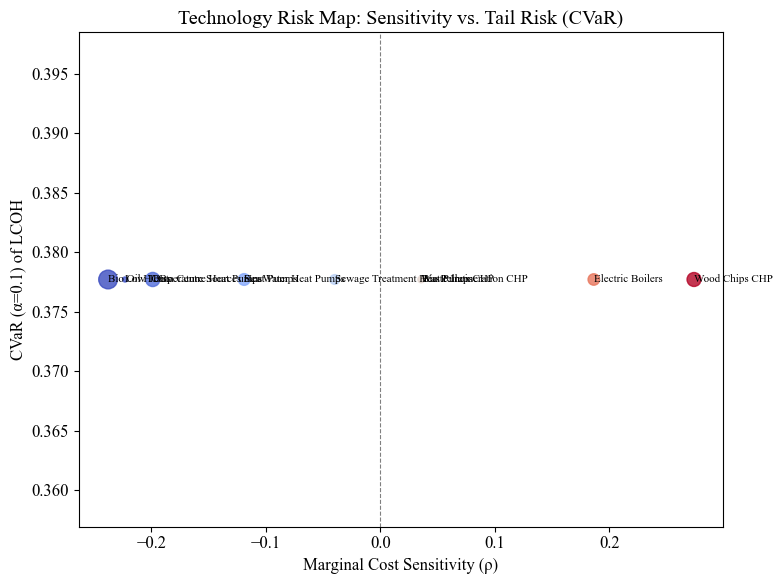

✅ Saved: DTW_results\tech_risk_exposure.csv


In [62]:
# --- Point 2: Technology Cost Sensitivity + CVaR Risk Exposure ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("DTW_results")
OUT_DIR.mkdir(exist_ok=True)

# --- Load data ---
cost_df = pd.read_csv("DTW_results/lcoh_by_cluster.csv")  # or total system cost per scenario
cap_df  = pd.read_csv("aggregates/investment_plans_wide.csv")

# normalize
cap_df.columns = [c.strip() for c in cap_df.columns]
tech_cols = [c for c in cap_df.columns if c not in ("Scenario", "Year")]
# use only final year (investment stock fully realized)
cap_latest = cap_df[cap_df["Year"] == cap_df["Year"].max()].copy()


# 1) Harmonize IDs
cap_latest["scen_num"] = cap_latest["Scenario"].apply(scen_num)
cost_df["scen_num"]    = cost_df["Scenario"].apply(scen_num)
cap_latest["Scenario"] = cap_latest["scen_num"]

# 2) Pick a cost column (handles kWh/MWh variants) and aggregate to scenario-level
cost_col = None
for c in ["LCOH_SEK_per_kWh", "lcoh_sek_per_kwh", "LCOH_SEK_per_MWh", "lcoh_sek_per_mwh", "LCOH"]:
    if c in cost_df.columns:
        cost_col = c
        break
assert cost_col is not None, "No LCOH column found in cost_df."

# Use same year as capacities (final year), or comment this block to use mean across years
yr = int(cap_latest["Year"].max())
cost_agg = (cost_df[cost_df["Year"]==yr]
            .groupby("scen_num", as_index=False)[cost_col].mean()
            .rename(columns={cost_col:"LCOH_SEK_per_kWh"}))

# merge with costs
df = cap_latest.merge(cost_df, on="Scenario", how="left")

# Optional: drop scenarios without cost
df = df.dropna(subset=["LCOH_SEK_per_kWh"]).copy()

# --- Compute sensitivity (correlation) ---
sensitivities = {}
for tech in tech_cols:
    if df[tech].nunique() > 1:  # skip constants
        sensitivities[tech] = df[[tech, "LCOH_SEK_per_kWh"]].corr().iloc[0, 1]
    else:
        sensitivities[tech] = np.nan

# --- Compute CVaR (conditional value at risk) ---
alpha = 0.1  # 10% worst outcomes
sorted_costs = df["LCOH_SEK_per_kWh"].sort_values()
VaR = np.quantile(sorted_costs, 1 - alpha)
CVaR = sorted_costs[sorted_costs >= VaR].mean()

# attribute same CVaR value for all (can later compute tech-wise CVaR if cost per tech available)
risk_df = pd.DataFrame({
    "tech": tech_cols,
    "sensitivity": [sensitivities[t] for t in tech_cols],
    "cvar": CVaR,
    "mean_cap": [df[t].mean() for t in tech_cols]
})

risk_df.to_csv(OUT_DIR / "tech_risk_exposure.csv", index=False)

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(risk_df["sensitivity"], risk_df["cvar"], 
            s=risk_df["mean_cap"]*0.2, c=risk_df["sensitivity"], cmap="coolwarm", alpha=0.8)
for _, row in risk_df.iterrows():
    plt.text(row["sensitivity"], row["cvar"], row["tech"], fontsize=8, ha="left", va="center")
plt.axvline(0, color="gray", linestyle="--", lw=0.8)
plt.xlabel("Marginal Cost Sensitivity (ρ)")
plt.ylabel(f"CVaR (α={alpha:.1f}) of LCOH")
plt.title("Technology Risk Map: Sensitivity vs. Tail Risk (CVaR)")
plt.tight_layout()
plt.show()

print(f"✅ Saved: {OUT_DIR/'tech_risk_exposure.csv'}")


In [63]:
# --- Tech-level LCOH with mapping, convheat-only production, ELGRID allocation, and CVaR(90) ---

import pandas as pd
import numpy as np
from pathlib import Path

# ---------------- CONFIG ----------------
BASE_DIR = Path(".")           # parent folder containing LTLE_scenario_* subfolders
SOURCE_MAP_XLSX = Path("analysis/source_type_mapping.xlsx")  # with columns: 'Marker', 'Source Type'

DISCOUNT_RATE = 0.05
CVaR_ALPHA = 0.10  # worst 10% tail → CVaR(90)

OUT_TS  = Path("analysis/lcoh_tech_timeseries.csv")
OUT_SUM = Path("DTW_results/tech_lcoh_cvar.csv")
OUT_TS.parent.mkdir(parents=True, exist_ok=True)
OUT_SUM.parent.mkdir(parents=True, exist_ok=True)

# Group mapping from codes → technology groups (base list)
NAMES = {
    'Waste Incineration CHP': ['BristaB2', 'HgldP3468', 'LSVTACHP'],
    'Data Centre Heat Pumps': ['DCACC'],
    'Bio Oil CHP': ['KVV1'],
    'Sewage Treatment Heat Pumps': ['HmrbySEWHP'],
    'Bio Oil HOBs': ['DECFOHOB', 'CSBOHOB', 'MINBIOOIL', 'MINFINBIOOIL'],
    'Bio Pellets CHP': ['HslbyP1toP3', 'MINSOLIDBIOP'],
    'Wood Chips CHP': ['BristaB1', 'KVV8', 'MINWOODCHIPS'],
    'Sea Water Heat Pumps': ['VVNHP'],
    'Electric Boilers': ['VVHVELHOB'],
    'Low Temperature Sources Heat Pumps': ['SUPACC'],
}

# HP/EB group list for ELEC cost allocation
ELEC_GROUPS = {
    'Low Temperature Sources Heat Pumps',
    'Data Centre Heat Pumps',
    'Sewage Treatment Heat Pumps',
    'Sea Water Heat Pumps',
    'Electric Boilers',
}

# Production fuels to keep (convheat only)
CONV_HEAT_FUELS = {"CONVHEAT", "CONVHEATNV", "CONVHEATCS"}

# ----------------------------------------

# Build reverse map: tech_code -> group (from NAMES)
code_to_group = {}
for group, codes in NAMES.items():
    for code in codes:
        code_to_group[code] = group

# Extend mapping using the Excel file for codes starting with 'S'
if SOURCE_MAP_XLSX.exists():
    src_map = pd.read_excel(SOURCE_MAP_XLSX)
    # Expect columns: 'Marker', 'Source Type'
    src_map = src_map.rename(columns={c: c.strip() for c in src_map.columns})
    src_map["Marker"] = src_map["Marker"].astype(str).str.strip()
    src_map["Source Type"] = src_map["Source Type"].astype(str).str.strip().str.lower()

    for _, r in src_map.iterrows():
        m = r["Marker"]
        st = r["Source Type"]
        if not m.startswith("S"):
            continue
        if "data centre" in st or "datacenter" in st or "data center" in st:
            code_to_group[m] = "Data Centre Heat Pumps"
        else:
            # supermarket, ice rink, subway station → Low Temperature Sources HPs
            code_to_group[m] = "Low Temperature Sources Heat Pumps"

# Helper to map technology code -> group label (fallback: None to drop)
def map_group(code: str) -> str | None:
    return code_to_group.get(str(code).strip(), None)

# Collect per-scenario data
prod_all, cost_all, use_all = [], [], []

for scen_dir in sorted(BASE_DIR.glob("LTLE_scenario_*")):
    scen = scen_dir.name
    f_prod = scen_dir / "ProdByTechAnn.csv"
    f_cost = scen_dir / "TotDiscCostByTech.csv"


    if not (f_prod.exists() and f_cost.exists()):
        continue

    # Read files
    dp = pd.read_csv(f_prod)
    dc = pd.read_csv(f_cost)
    dp["Scenario"] = scen; dc["Scenario"] = scen
    prod_all.append(dp)
    cost_all.append(dc)

if not prod_all:
    raise RuntimeError("No scenarios found under BASE_DIR with expected files.")

prod = pd.concat(prod_all, ignore_index=True)
cost = pd.concat(cost_all, ignore_index=True)
use  = pd.concat(use_all, ignore_index=True) if use_all else pd.DataFrame()

# ---- Normalize columns ----
for df in (prod, cost):
    if df.empty: 
        continue
    df.columns = [c.strip().upper() for c in df.columns]
    # Standardize essential columns
    if "TECHNOLOGY" not in df.columns or "YEAR" not in df.columns or "VALUE" not in df.columns:
        raise ValueError("Expected OSeMOSYS columns: TECHNOLOGY, YEAR, VALUE.")
    df["SCENARIO"] = df["SCENARIO"].astype(str)
    df["TECHNOLOGY"] = df["TECHNOLOGY"].astype(str)
    df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce").astype("Int64")
    df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")

# Filter production: only NAME==ProdByTechAnn (if present) and convheat fuels
if "NAME" in prod.columns:
    prod = prod[prod["NAME"].str.contains("PRODBYTECHANN", case=False, na=False)]
# Keep only convheat fuels if FUEL present; otherwise keep all (defensive)
if "FUEL" in prod.columns:
    prod = prod[prod["FUEL"].str.upper().isin(CONV_HEAT_FUELS)]
prod = prod.dropna(subset=["YEAR"]).copy(); prod["YEAR"] = prod["YEAR"].astype(int)

# Costs: keep NAME containing 'COST'
if "NAME" in cost.columns:
    cost = cost[cost["NAME"].str.contains("COST", case=False, na=False)]
cost = cost.dropna(subset=["YEAR"]).copy(); cost["YEAR"] = cost["YEAR"].astype(int)

# --- Build/Load annual electricity use by tech (use) ---
use_all = []  # (Scenario, YEAR, TECHNOLOGY, FUEL, VALUE) annualized

for scen_dir in sorted(BASE_DIR.glob("LTLE_scenario_*")):
    scen = scen_dir.name
    f_use_ann = scen_dir / "UseByTechAnn.csv"
    f_use_ts  = scen_dir / "UseByTech.csv"

    if f_use_ann.exists():
        ua = pd.read_csv(f_use_ann)
        ua.columns = [c.strip().upper() for c in ua.columns]
        # require FUEL; if missing, fall back to UseByTech.csv
        if "FUEL" in ua.columns:
            ua["SCENARIO"] = scen
            ua["YEAR"] = pd.to_numeric(ua["YEAR"], errors="coerce").astype("Int64")
            ua = ua.dropna(subset=["YEAR"]).copy(); ua["YEAR"] = ua["YEAR"].astype(int)
            ua["FUEL"] = ua["FUEL"].astype(str)
            ua = ua[ua["FUEL"].str.upper().eq("ELEC")]
            use_all.append(ua)
            continue  # done for this scenario

    # Fallback: aggregate UseByTech.csv over TIMESLICE → annual
    if f_use_ts.exists():
        ut = pd.read_csv(f_use_ts)
        ut.columns = [c.strip().upper() for c in ut.columns]
        # Find a fuel-like column
        fuel_col = None
        for cand in ["FUEL", "COMMODITY", "COMMODITY2"]:
            if cand in ut.columns:
                fuel_col = cand
                break
        if fuel_col is None:
            # if no fuel info, we cannot split ELGRID reliably; skip this scenario's use
            continue

        # Coerce and aggregate over timeslices
        ut["SCENARIO"] = scen
        ut["YEAR"] = pd.to_numeric(ut["YEAR"], errors="coerce").astype("Int64")
        ut = ut.dropna(subset=["YEAR"]).copy(); ut["YEAR"] = ut["YEAR"].astype(int)
        ut["VALUE"] = pd.to_numeric(ut["VALUE"], errors="coerce")
        ut[fuel_col] = ut[fuel_col].astype(str)

        ua = (ut.groupby(["SCENARIO","YEAR","TECHNOLOGY", fuel_col], as_index=False)["VALUE"]
                .sum())
        ua = ua.rename(columns={fuel_col: "FUEL"})
        ua = ua[ua["FUEL"].str.upper().eq("ELEC")]
        use_all.append(ua)

# Concatenate to a single annual ELEC-use table
use = pd.concat(use_all, ignore_index=True) if use_all else pd.DataFrame(columns=["SCENARIO","YEAR","TECHNOLOGY","FUEL","VALUE"])

# Map technology codes → groups for allocation
if not use.empty:
    use["Group"] = use["TECHNOLOGY"].map(map_group)
    use = use.dropna(subset=["Group"])

# UseByTech: filter ELEC if available
if not use.empty:
    if "NAME" in use.columns:
        use = use[use["NAME"].str.contains("USEBYTECH", case=False, na=False)]
    if "FUEL" in use.columns:
        use = use[use["FUEL"].str.upper().eq("ELEC")]
    use = use.dropna(subset=["YEAR"]).copy(); use["YEAR"] = use["YEAR"].astype(int)

# Units: Production TJ → GWh
prod["PRODUCTION_GWH"] = prod["VALUE"] / 3.6  # 1 GWh = 3.6 TJ

# Map technology codes → groups; drop codes we don't track
prod["Group"] = prod["TECHNOLOGY"].map(map_group)
cost["Group"] = cost["TECHNOLOGY"].map(map_group)
if not use.empty:
    use["Group"] = use["TECHNOLOGY"].map(map_group)

prod = prod.dropna(subset=["Group"])
cost_non_elgrid = cost.dropna(subset=["Group"]).copy()   # costs that already belong to a group
# ELGRID costs (to be allocated)
elgrid = cost[cost["TECHNOLOGY"].str.upper().eq("ELGRID")].copy()

# Ignore negative costs, discount rule
cost_non_elgrid = cost_non_elgrid[cost_non_elgrid["VALUE"].ge(0)].copy()
elgrid = elgrid[elgrid["VALUE"].ge(0)].copy()

# Discounting: assume TotDiscCostByTech is already discounted; set passthrough
# If you ever switch to nominal cost files, set already_discounted=False and apply discount below.
already_discounted = True
if already_discounted:
    cost_non_elgrid["COST_DISC_SEK"] = cost_non_elgrid["VALUE"]
    elgrid["COST_DISC_SEK"] = elgrid["VALUE"]
else:
    Y0 = int(min(prod["YEAR"].min(), cost["YEAR"].min()))
    cost_non_elgrid["COST_DISC_SEK"] = cost_non_elgrid["VALUE"] / (1.0 + DISCOUNT_RATE) ** (cost_non_elgrid["YEAR"] - Y0)
    elgrid["COST_DISC_SEK"] = elgrid["VALUE"] / (1.0 + DISCOUNT_RATE) ** (elgrid["YEAR"] - Y0)

# --- Allocate ELGRID costs to ELEC-consuming groups by ELEC use share ---
if not use.empty and not elgrid.empty:
    # Sum ELEC use by (Scenario, Year, Group) only for groups of interest
    elec_use = (use.dropna(subset=["Group"])
                   .query("Group in @ELEC_GROUPS")
                   .groupby(["SCENARIO","YEAR","Group"], as_index=False)["VALUE"].sum()
                   .rename(columns={"VALUE":"ELEC_USE"}))

    # Total ELEC use per (Scenario,Year) among target groups
    elec_tot = elec_use.groupby(["SCENARIO","YEAR"], as_index=False)["ELEC_USE"].sum().rename(columns={"ELEC_USE":"ELEC_TOT"})
    elec_use = elec_use.merge(elec_tot, on=["SCENARIO","YEAR"], how="left")
    elec_use["SHARE"] = np.where(elec_use["ELEC_TOT"] > 0, elec_use["ELEC_USE"] / elec_use["ELEC_TOT"], 0.0)

    # ELGRID cost per (Scenario,Year)
    grid_cost = elgrid.groupby(["SCENARIO","YEAR"], as_index=False)["COST_DISC_SEK"].sum().rename(columns={"COST_DISC_SEK":"ELGRID_COST"})

    # Allocate
    alloc = elec_use.merge(grid_cost, on=["SCENARIO","YEAR"], how="left")
    alloc["ALLOC_COST"] = alloc["SHARE"] * alloc["ELGRID_COST"]
    # Keep only needed columns
    alloc = alloc[["SCENARIO","YEAR","Group","ALLOC_COST"]]
else:
    # No UseByTech or no ELGRID → zero allocation
    alloc = pd.DataFrame(columns=["SCENARIO","YEAR","Group","ALLOC_COST"])

# --- Build tech-level LCOH ---

# --- ensure single SCENARIO column (dedupe) ---
# --- Rebuild a single clean SCENARIO column in prod ---
scen_idx = [i for i, c in enumerate(prod.columns) if c == "SCENARIO"]
cands = [prod.iloc[:, i].astype(str) for i in scen_idx]  # candidate Series

def score(s):
    s = s.str.strip().str.lower()
    bad = {"0", "0.0", "", "nan"}
    return (~s.isin(bad)).mean()  # share of "real" entries

best = max(cands, key=score) if cands else pd.Series(index=prod.index, dtype="object")
prod["__SCEN"] = best

# drop ALL existing SCENARIO columns, then keep only the rebuilt one
prod = prod.drop(columns=[c for c in prod.columns if c == "SCENARIO"])
prod = prod.rename(columns={"__SCEN": "SCENARIO"})

# Production by (Scenario,Year,Group)
P = (prod.groupby(["SCENARIO","YEAR","Group"], as_index=False)["PRODUCTION_GWH"].sum())

# Cost by (Scenario,Year,Group): own costs + allocated ELGRID
# --- Rebuild a single clean SCENARIO column in cost_non_elgrid ---
scen_idx = [i for i, c in enumerate(cost_non_elgrid.columns) if c == "SCENARIO"]
cands = [cost_non_elgrid.iloc[:, i].astype(str) for i in scen_idx]  # candidate Series

def score(s):
    s = s.str.strip().str.lower()
    bad = {"0", "0.0", "", "nan"}
    return (~s.isin(bad)).mean()  # share of "real" entries

best = max(cands, key=score) if cands else pd.Series(index=cost_non_elgrid.index, dtype="object")
cost_non_elgrid["__SCEN"] = best

# drop all duplicate SCENARIO columns, keep only the cleaned one
cost_non_elgrid = cost_non_elgrid.drop(columns=[c for c in cost_non_elgrid.columns if c == "SCENARIO"])
cost_non_elgrid = cost_non_elgrid.rename(columns={"__SCEN": "SCENARIO"})




C_own = (cost_non_elgrid.groupby(["SCENARIO","YEAR","Group"], as_index=False)["COST_DISC_SEK"].sum())
if not alloc.empty:
    C = C_own.merge(alloc, on=["SCENARIO","YEAR","Group"], how="left")
    C["ALLOC_COST"] = C["ALLOC_COST"].fillna(0.0)
    C["COST_TOTAL_SEK"] = C["COST_DISC_SEK"] + C["ALLOC_COST"]
else:
    C = C_own.copy()
    C["COST_TOTAL_SEK"] = C["COST_DISC_SEK"]

# Merge P & C
df = P.merge(C[["SCENARIO","YEAR","Group","COST_TOTAL_SEK"]], on=["SCENARIO","YEAR","Group"], how="left")
df = df[df["PRODUCTION_GWH"] > 0].copy()

# LCOH (SEK/MWh): GWh → MWh *1000
df["LCOH_SEK_per_MWh"] = df["COST_TOTAL_SEK"] / (df["PRODUCTION_GWH"] )

# Save time series (Scenario-Year-Group)
lcoh_ts = (df.rename(columns={"SCENARIO":"Scenario","YEAR":"Year","Group":"Technology"})
             [["Scenario","Year","Technology","PRODUCTION_GWH","COST_TOTAL_SEK","LCOH_SEK_per_MWh"]]
             .rename(columns={"PRODUCTION_GWH":"Production_GWh","COST_TOTAL_SEK":"Cost_SEK"}))
lcoh_ts.to_csv(OUT_TS, index=False)
print(f"✅ Saved tech-level LCOH time series → {OUT_TS.resolve()} (rows={len(lcoh_ts):,})")

# --- CVaR(90) per technology across scenarios (average over years per scenario) ---
scen_tech = (lcoh_ts.groupby(["Scenario","Technology"], as_index=False)["LCOH_SEK_per_MWh"].mean())

rows = []
for tech, sub in scen_tech.groupby("Technology"):
    vals = sub["LCOH_SEK_per_MWh"].dropna().values
    if len(vals) == 0:
        continue
    var90  = np.quantile(vals, 0.90)
    cvar90 = vals[vals >= var90].mean() if (vals >= var90).any() else var90
    rows.append({
        "Technology": tech,
        "n_scenarios": int(len(vals)),
        "mean_LCOH_SEK_per_MWh": float(np.mean(vals)),
        "std_LCOH_SEK_per_MWh":  float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "VaR90_SEK_per_MWh":     float(var90),
        "CVaR90_SEK_per_MWh":    float(cvar90),
    })

tech_cvar = pd.DataFrame(rows).sort_values("CVaR90_SEK_per_MWh").reset_index(drop=True)
tech_cvar.to_csv(OUT_SUM, index=False)
print(f"✅ Saved tech-level CVaR summary → {OUT_SUM.resolve()}")
display(tech_cvar)

✅ Saved tech-level LCOH time series → C:\Paper 4\Outputs\Raw\analysis\lcoh_tech_timeseries.csv (rows=46,345)
✅ Saved tech-level CVaR summary → C:\Paper 4\Outputs\Raw\DTW_results\tech_lcoh_cvar.csv


,Technology,n_scenarios,mean_LCOH_SEK_per_MWh,std_LCOH_SEK_per_MWh,VaR90_SEK_per_MWh,CVaR90_SEK_per_MWh
0,Waste Incineration CHP,204,2.765825e-03,8.484049e-03,8.926133e-03,2.412874e-02
1,Data Centre Heat Pumps,204,9.570245e-02,2.242784e-02,1.275784e-01,1.393459e-01
2,Sewage Treatment Heat Pumps,204,1.070537e-01,2.597816e-02,1.370140e-01,1.571019e-01
3,Sea Water Heat Pumps,204,9.877906e-02,3.675459e-02,1.463165e-01,1.634096e-01
4,Low Temperature Sources Heat Pumps,198,1.549107e-01,7.056871e-02,2.394339e-01,3.041340e-01
5,Wood Chips CHP,204,5.600625e-01,7.950316e-03,5.685238e-01,5.760949e-01
6,Electric Boilers,204,8.226033e-01,1.897194e+00,2.377989e+00,4.846084e+00
7,Bio Oil HOBs,204,6.246339e+00,2.890493e+00,9.460411e+00,9.741548e+00
8,Bio Pellets CHP,204,8.509305e+11,8.609395e+12,3.739039e+00,8.266182e+12
9,Bio Oil CHP,204,2.766249e+15,1.016617e+16,6.848486e+15,2.298292e+16


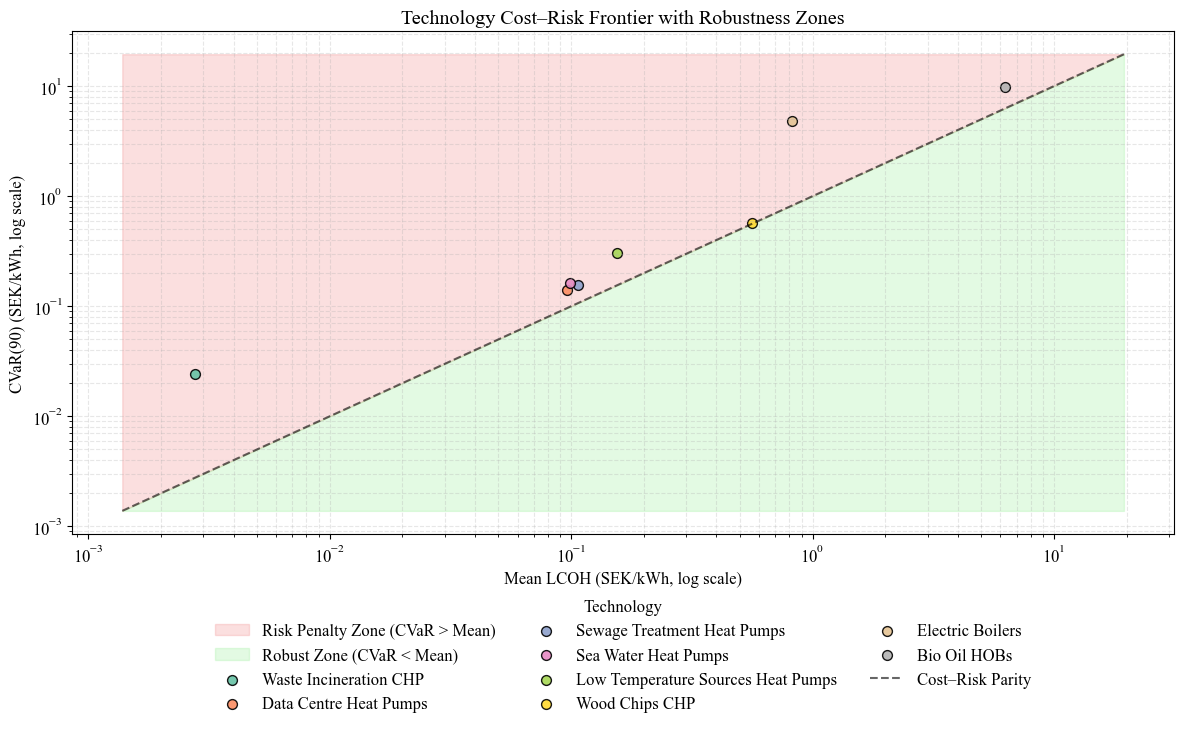

In [64]:
# --- Cost–Risk Frontier (with Risk/Robust Zones Shaded) ---

import matplotlib.pyplot as plt
# Set global font to Times New Roman, size 10
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
import seaborn as sns
import numpy as np

plot_df = tech_cvar[~tech_cvar["Technology"].isin(["Bio Pellets CHP", "Bio Oil CHP"])].copy()

# Assign color palette
palette = sns.color_palette("Set2", n_colors=len(plot_df))
plot_df["color"] = palette

# Plot base figure
plt.figure(figsize=(8, 6))

# Compute limits for shading
lims = [
    plot_df[["mean_LCOH_SEK_per_MWh", "CVaR90_SEK_per_MWh"]].min().min(),
    plot_df[["mean_LCOH_SEK_per_MWh", "CVaR90_SEK_per_MWh"]].max().max(),
]

# Create smooth line for y = x
x_vals = np.logspace(np.log10(lims[0]*0.5), np.log10(lims[1]*2), 100)

# --- Shaded regions ---
plt.fill_between(x_vals, x_vals, lims[1]*2, color="lightcoral", alpha=0.25, label="Risk Penalty Zone (CVaR > Mean)")
plt.fill_between(x_vals, lims[0]*0.5, x_vals, color="lightgreen", alpha=0.25, label="Robust Zone (CVaR < Mean)")

# Scatter points
for i, row in plot_df.iterrows():
    plt.scatter(
        row["mean_LCOH_SEK_per_MWh"], 
        row["CVaR90_SEK_per_MWh"],
        s=50, 
        color=row["color"], 
        edgecolor="black", 
        alpha=0.9, 
        label=row["Technology"]
    )

# Parity line
plt.plot(x_vals, x_vals, 'k--', alpha=0.6, label="Cost–Risk Parity")
plt.gcf().set_size_inches(12, 9)
# Log scales
plt.xscale("log")
plt.yscale("log")

# Labels and title
plt.xlabel("Mean LCOH (SEK/kWh, log scale)")
plt.ylabel("CVaR(90) (SEK/kWh, log scale)")
plt.title("Technology Cost–Risk Frontier with Robustness Zones")

# Legend below (4 columns)
plt.legend(
    title="Technology",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False
)

plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout(rect=[0, 0.15, 1, 1])
plt.show()

## 🔩 Step 4.1 — Technology Inertia and Temporal Autocorrelation

---

### 🎯 **Purpose**

This step quantifies how persistent or adaptive each technology’s capacity evolution is over time.  
Two complementary indicators are computed:

1. **Technology Inertia Index (TII)** – measures *structural lock-in* or long-term stability of investments.  
2. **Lag-1 Autocorrelation (ρ₁)** – measures *temporal inertia* or short-term persistence year-to-year.

Together, they provide insight into whether technologies are **locked-in**, **transitioning**, or **adaptive** under uncertainty.

---

### 🧮 **Mathematical Foundation**

#### **Variance (Var)** — How much a value fluctuates

Variance measures how spread-out a variable is around its mean value:

\[
\mathrm{Var}(X_i) = \frac{1}{n-1} \sum_t (X_{i,t} - \bar{X_i})^2
\]

- **Low variance** → stable pattern (small deviations from mean)  
- **High variance** → volatile or adaptive pattern

---

#### **Covariance (Cov)** — How two values move together

\[
\mathrm{Cov}(X_i, X_j) = \frac{1}{n-1} \sum_t (X_{i,t} - \bar{X_i})(X_{j,t} - \bar{X_j})
\]

- **Positive covariance** → both increase or decrease together (*synergy*)  
- **Negative covariance** → one increases while the other decreases (*substitution*)  
- **Zero covariance** → no relationship (*independent dynamics*)

Since covariance is not normalized, we often use the **correlation coefficient**:

\[
r_{ij} = \frac{\mathrm{Cov}(X_i, X_j)}{\sigma(X_i)\sigma(X_j)}
\]

which ranges from –1 (perfect substitution) to +1 (perfect synergy).

---

### ⚙️ **Technology Inertia Index (TII)**

\[
TII_i = 1 - \frac{\mathrm{Var}(\Delta X_i)}{\mathrm{Var}(X_i)}
\]

where  
\( X_i \) = capacity time-series of technology *i*  
\( \Delta X_i = X_{i,t} - X_{i,t-1} \) = annual change in capacity

**Interpretation:**

| TII | Meaning | Description |
|:--:|:--|:--|
| → 1 | High stability | Locked-in / path dependent |
| ≈ 0.5 | Moderate | Gradual and adaptive evolution |
| → 0 | High volatility | Highly flexible or uncertain pattern |

The TII captures *how much the capacity changes* relative to its total variability —  
if annual changes are small, the technology is *locked-in*; if large, it is *adaptive*.

---

### ⚙️ **Lag-1 Autocorrelation (ρ₁)**

\[
ρ_{i,1} = \frac{\mathrm{Cov}(X_{i,t}, X_{i,t-1})}{\sigma(X_{i,t})\sigma(X_{i,t-1})}
\]

Autocorrelation measures whether capacity levels in consecutive years are similar.

**Interpretation:**

| ρ₁ | Meaning | Description |
|:--:|:--|:--|
| > 0.8 | Strong persistence | Lock-in, slow adjustment |
| 0.3–0.7 | Moderate | Controlled transition |
| < 0.3 | Weak | Highly adaptive or volatile |
| < 0 | Negative | Oscillatory / boom–bust dynamics |

While TII captures *structural inertia*, autocorrelation captures *temporal stickiness* —  
together they provide a two-dimensional view of technological lock-in.

---

### 📊 **Interpreting the Results**

- **High TII + High ρ₁** → strong lock-in (stable capacity path)  
- **Low TII + Low ρ₁** → adaptive or flexible technology  
- **High TII + Low ρ₁** → sudden but stable shifts (phase transitions)  
- **Low TII + High ρ₁** → temporary oscillations around a stable level  

We’ll visualize both metrics as a **scatter plot** (TII vs ρ₁) to map technologies in the lock-in–flexibility space.

---

### 📁 **Data Input**

File: `aggregates/investment_plans_wide.csv`  
Each row contains:
- `Scenario` — scenario name or ID  
- `Year` — simulation year  
- Remaining columns — capacities by technology (MW or GWh)

---

### 🧩 **Next Step**

Compute **Technology Inertia Index (TII)** and **Autocorrelation (ρ₁)**  
for each technology across all years and scenarios,  
and visualize them in a 2D lock-in map.

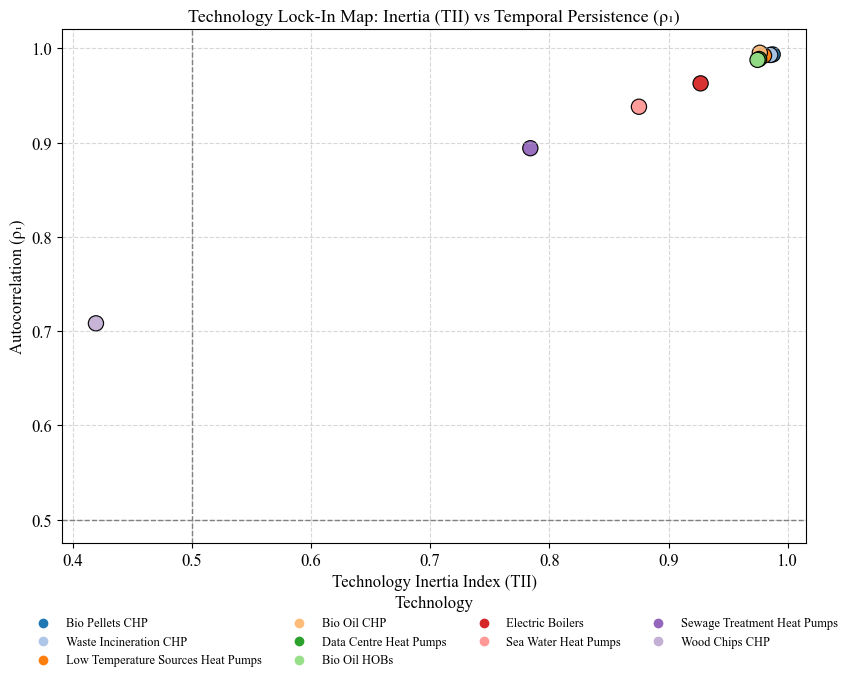

In [65]:
# --- Step 4.1: Technology Lock-In Map (High-Contrast Colors) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load investment data
df = pd.read_csv("aggregates/totcap_plans_wide.csv")

# Identify technology columns
tech_cols = [c for c in df.columns if c not in ["Scenario", "Year"]]

# Compute mean capacity per technology across scenarios
df_mean = df.groupby("Year")[tech_cols].mean()

results = []

for tech in tech_cols:
    x = df_mean[tech].values
    if len(x) < 3 or np.allclose(x, 0):
        continue

    dx = np.diff(x)
    var_x = np.var(x, ddof=1)
    var_dx = np.var(dx, ddof=1)
    tii = 1 - (var_dx / var_x) if var_x > 0 else np.nan

    x_t, x_tm1 = x[1:], x[:-1]
    rho = np.corrcoef(x_t, x_tm1)[0, 1] if np.std(x_t) > 0 and np.std(x_tm1) > 0 else np.nan

    results.append({"Technology": tech, "TII": tii, "Autocorr": rho})

tii_df = pd.DataFrame(results).dropna().sort_values("TII", ascending=False)

# --- Visualization: Technology Lock-In Map ---
plt.figure(figsize=(9, 7))

# Use tab20 for high-contrast categorical colors
palette = sns.color_palette("tab20", len(tii_df))

sns.scatterplot(
    data=tii_df, x="TII", y="Autocorr",
    hue="Technology", palette=palette, s=120, edgecolor="black", alpha=0.95
)

# Quadrant guide lines
plt.axvline(0.5, color="grey", linestyle="--", lw=1)
plt.axhline(0.5, color="grey", linestyle="--", lw=1)

plt.title("Technology Lock-In Map: Inertia (TII) vs Temporal Persistence (ρ₁)", fontsize=13)
plt.xlabel("Technology Inertia Index (TII)")
plt.ylabel("Autocorrelation (ρ₁)")
plt.grid(True, linestyle="--", alpha=0.5)

# Legend below the plot, 4 columns
plt.legend(
    bbox_to_anchor=(0.5, -0.08), loc="upper center",
    ncol=4, frameon=False, title="Technology", fontsize=9
)

plt.tight_layout()
plt.show()


In [66]:
# --- Step 4.2: Operational Lock-In Map (OII vs Operational Autocorrelation) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load utilisation data ---
# The file should contain columns: Scenario, Year, and one column per technology
df = pd.read_csv("DTW_results/utilization_raw.csv")

df_wide = df.pivot_table(
    index=["Scenario", "Year"], 
    columns="Technology", 
    values="UtilizationRate"
).reset_index()

tech_cols = [c for c in df_wide.columns if c not in ["Scenario", "Year"]]

# Compute mean utilisation per technology across all scenarios for each year
df_mean = df_wide.groupby("Year")[tech_cols].mean()

# --- Compute Operational Inertia Index (OII) and Lag-1 Autocorrelation (ρ₁ᵒ) ---
results = []

for tech in tech_cols:
    x = df_mean[tech].values
    if len(x) < 3 or np.allclose(x, 0):
        continue  # skip if too few points or near-zero series

    dx = np.diff(x)
    var_x = np.var(x, ddof=1)
    var_dx = np.var(dx, ddof=1)
    oii = 1 - (var_dx / var_x) if var_x > 0 else np.nan

    # lag-1 autocorrelation
    x_t, x_tm1 = x[1:], x[:-1]
    rho_o = np.corrcoef(x_t, x_tm1)[0, 1] if np.std(x_t) > 0 and np.std(x_tm1) > 0 else np.nan

    results.append({"Technology": tech, "OII": oii, "Autocorr_op": rho_o})

# Convert results to DataFrame
op_lockin = pd.DataFrame(results).dropna().sort_values("OII", ascending=False)

# --- Plot: Operational Lock-In Map ---
plt.figure(figsize=(9, 7))

# Use high-contrast categorical color palette
palette = sns.color_palette("tab20", len(op_lockin))

sns.scatterplot(
    data=op_lockin,
    x="OII", y="Autocorr_op",
    hue="Technology",
    palette=palette,
    s=120, edgecolor="black", alpha=0.95
)

# Add quadrant guide lines
plt.axvline(0.5, color="grey", linestyle="--", lw=1)
plt.axhline(0.5, color="grey", linestyle="--", lw=1)

# Labels and layout
plt.title("Operational Lock-In Map: Utilisation Inertia (OII) vs Temporal Persistence (ρ₁ᵒ)", fontsize=13)
plt.xlabel("Operational Inertia Index (OII)")
plt.ylabel("Operational Autocorrelation (ρ₁ᵒ)")
plt.grid(True, linestyle="--", alpha=0.5)

# Legend below the plot
plt.legend(
    bbox_to_anchor=(0.5, -0.08),
    loc="upper center",
    ncol=4,
    frameon=False,
    title="Technology",
    fontsize=9
)

plt.tight_layout()
plt.show()

# --- Save results ---
op_lockin.to_csv("analysis/operational_lockin_summary.csv", index=False)
print("✅ Operational lock-in results saved to analysis/operational_lockin_summary.csv")

KeyError: 'UtilizationRate'

In [ ]:
# --- Technology-Level Resilience Profiles (Clean Radar Charts) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# === INPUTS ===
robust_file = Path("aggregates/investment_robustness_by_year.csv")
lockin_file = Path("DTW_results/tech_lockin_index.csv")
cvar_file   = Path("DTW_results/tech_lcoh_cvar.csv")

# === LOAD DATA ===
robust = pd.read_csv(robust_file)
lockin = tii_df  # already in memory
cvar   = pd.read_csv(cvar_file)

# --- Prepare data ---
robust_mean = robust.mean(numeric_only=True).rename("Robustness").reset_index().rename(columns={"index": "Technology"})
lockin = lockin.rename(columns={lockin.columns[-1]: "LockIn"})
cvar = cvar.rename(columns={"Technology": "Technology", "CVaR90_SEK_per_MWh": "CVaR"})
cvar["CostResilience"] = 1 - (cvar["CVaR"] - cvar["CVaR"].min()) / (cvar["CVaR"].max() - cvar["CVaR"].min())

# Merge
df = (
    robust_mean.merge(lockin[["Technology","LockIn"]], on="Technology", how="inner")
               .merge(cvar[["Technology","CostResilience"]], on="Technology", how="inner")
)

# Normalize
for col in ["Robustness", "LockIn", "CostResilience"]:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# Weighted indices
df["EqualWeight"] = df[["Robustness","LockIn","CostResilience"]].mean(axis=1)
df["TransitionWeight"] = 0.4*df["Robustness"] + 0.4*df["LockIn"] + 0.2*df["CostResilience"]

# Exclude unwanted techs
df = df[~df["Technology"].isin(["Bio Oil CHP","Bio Pellets CHP"])]

# --- Radar setup ---
categories = ["Robustness", "LockIn", "CostResilience"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# --- Plot setup ---
n_tech = len(df)
ncols = 3
nrows = int(np.ceil(n_tech / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, subplot_kw=dict(polar=True), figsize=(14, 10))
axes = axes.flatten()

colors = {"EqualWeight": "#1f77b4", "TransitionWeight": "#2ca02c"}

for ax, (_, row) in zip(axes, df.iterrows()):
    tech = row["Technology"]

    # Data values
    values_eq = row[categories].values.tolist() + [row[categories[0]]]
    values_tr = [0.4*row["Robustness"], 0.4*row["LockIn"], 0.2*row["CostResilience"]]
    values_tr = values_tr + [values_tr[0]]

    # Base polar setup
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticklabels([])
    ax.grid(True, linestyle=":", alpha=0.5)

    # Plot both polygons
    ax.plot(angles, values_eq, color=colors["EqualWeight"], linewidth=2, linestyle="-", label="Equal Weight")
    ax.fill(angles, values_eq, color=colors["EqualWeight"], alpha=0.15)

    ax.plot(angles, values_tr, color=colors["TransitionWeight"], linewidth=2, linestyle="--", label="Transition Weight")
    ax.fill(angles, values_tr, color=colors["TransitionWeight"], alpha=0.15)

    # Title
    ax.set_title(tech, size=11, weight="bold", pad=10)

    # --- Add indicator labels at the tips ---
    label_radius = 1.15  # how far outside
    for i, label in enumerate(categories):
        angle = angles[i]
        ha = "left" if np.cos(angle) >= 0 else "right"
        ax.text(angle, label_radius, label, size=9, weight="bold", ha=ha, va="center")

# Turn off unused plots
for ax in axes[len(df):]:
    ax.axis("off")

# Legend
fig.legend(["Equal Weight", "Transition Weight"], loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04))
plt.suptitle("Technology-Level Resilience Profiles (Normalized, Indicator-Labeled)", size=14, weight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


In [ ]:
# --- Annotated Resilience Pareto Frontier (RAW VALUES) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === INPUT FILES ===
robust_file = Path("aggregates/investment_robustness_by_year.csv")
lockin_file = Path("DTW_results/tech_lockin_index.csv")
cvar_file   = Path("DTW_results/tech_lcoh_cvar.csv")

# === LOAD DATA ===
robust = pd.read_csv(robust_file)
lockin = tii_df
cvar   = pd.read_csv(cvar_file)

# --- Prepare robustness (mean across years) ---
robust_mean = robust.mean(numeric_only=True).rename("Robustness").reset_index().rename(columns={"index": "Technology"})

# --- Prepare lock-in ---
lockin = lockin.rename(columns={lockin.columns[-1]: "LockIn"})  # assumes last col is index value

# --- Merge raw indicators ---
df_raw = (
    robust_mean.merge(lockin[["Technology","LockIn"]], on="Technology", how="inner")
)

# --- Exclude unwanted techs ---
df_raw = df_raw[~df_raw["Technology"].isin(["Bio Oil CHP","Bio Pellets CHP"])].copy()

# --- Normalize not needed here; we use raw values directly ---
# --- Pareto Frontier calculation (upper-right boundary) ---
df_sorted = df_raw.sort_values("LockIn").reset_index(drop=True)
pareto = []
current_max = -np.inf
for _, row in df_sorted.iterrows():
    if row["Robustness"] > current_max:
        pareto.append(row)
        current_max = row["Robustness"]
pareto = pd.DataFrame(pareto)

# --- Plot setup ---
plt.figure(figsize=(11, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_raw)))

for i, (idx, row) in enumerate(df_raw.iterrows()):
    plt.scatter(row["LockIn"], row["Robustness"], s=150, color=colors[i], label=row["Technology"], edgecolor="black", alpha=0.8)
    #plt.text(row["LockIn"]+0.01, row["Robustness"]+0.01, row["Technology"], fontsize=9, fontweight="bold")

# Pareto frontier line
plt.plot(pareto["LockIn"], pareto["Robustness"], color="red", linestyle="--", linewidth=2, label="Pareto Frontier")

# --- Labels & formatting ---
plt.title("Annotated Resilience Pareto Frontier (Raw Values)", fontsize=13, weight="bold")
plt.xlabel("Lock-In / Flexibility Index (raw value)", fontsize=11)
plt.ylabel("Robustness Index (1 − σ/μ, raw value)", fontsize=11)
plt.grid(True, alpha=0.3)

# Legend below the plot
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.45), ncol=4)
plt.tight_layout(rect=[0, 0.15, 1, 0.95])

plt.show()

In [ ]:
# --- System-level Cost vs GLOBAL Regret Frontier ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# ---- Inputs
FEATURE_KPI   = Path("features_heat_kpis.csv")      # scenario-level KPIs
CLUSTER_LABEL = Path("DTW_results/totcap_dtw_labels.csv")  # optional (for coloring)

# ---- Load
feat = pd.read_csv(FEATURE_KPI)
lbl  = pd.read_csv(CLUSTER_LABEL) if CLUSTER_LABEL.exists() else None

# Normalize/derive scenario id for merging
def scen_norm(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else np.nan

# Use 'scenario' if present; else derive sequential or from file
if "scenario" in feat.columns:
    feat["scen_num"] = feat["scenario"].apply(scen_norm)
else:
    feat["scen_num"] = np.arange(1, len(feat)+1)

if lbl is not None:
    lbl["scen_num"] = lbl["Scenario"].apply(scen_norm)
    feat = feat.merge(lbl[["scen_num","Cluster"]], on="scen_num", how="left")
else:
    feat["Cluster"] = np.nan

# Column harmonization (rename only if those exist)
rename_map = {
    "total_pos_disc_cost": "TotalCost_MSEK",
    "lcoh_sek_per_mwh": "LCOH_SEK_per_MWh",
    "emission_intensity_kg_per_kwh": "EmInt_kg_per_kWh",
}
for k, v in rename_map.items():
    if k in feat.columns and v not in feat.columns:
        feat = feat.rename(columns={k: v})

# Keep essentials; drop rows without cost
df = feat[["scen_num","Cluster","TotalCost_MSEK"]].dropna(subset=["TotalCost_MSEK"]).copy()

# ---- GLOBAL regret (relative to absolute minimum cost across all scenarios)
global_min_cost = df["TotalCost_MSEK"].min()
df["Regret_MSEK_global"] = df["TotalCost_MSEK"] - global_min_cost
df["Regret_pct_global"]  = np.where(global_min_cost > 0,
                                    df["Regret_MSEK_global"] / global_min_cost,
                                    np.nan)

# ---- Pareto frontier (minimize cost & global regret)
df_sorted = df.sort_values(["TotalCost_MSEK","Regret_pct_global"]).reset_index(drop=True)
pareto_rows, current_min = [], np.inf
for _, r in df_sorted.iterrows():
    if r["Regret_pct_global"] <= current_min:
        pareto_rows.append(r)
        current_min = r["Regret_pct_global"]
pareto = pd.DataFrame(pareto_rows)

# ---- Plot
plt.figure(figsize=(8.8,6.2))
sns.scatterplot(
    data=df,
    x="TotalCost_MSEK", y="Regret_pct_global",
    hue="Cluster", palette="tab10", s=80, edgecolor="black", alpha=0.9
)

# Frontier line
plt.plot(pareto["TotalCost_MSEK"], pareto["Regret_pct_global"],
         color="red", linestyle="--", linewidth=2, label="Robust frontier (global regret)")

plt.xlabel("Total discounted system cost (MSEK)")
plt.ylabel("Global regret vs absolute best (fraction)")
plt.title("System-level Cost–Regret Frontier (Global Benchmark)")
plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, frameon=False)
plt.tight_layout(rect=[0,0.06,1,0.95])
plt.show()

# ---- Short-list: most robust scenarios on the frontier (lowest regret, then cost)
robust_global = (
    pareto.sort_values(["Regret_pct_global","TotalCost_MSEK"])
          .assign(Regret_pct_str=lambda d: (d["Regret_pct_global"]*100).round(2).astype(str) + "%")
          [["scen_num","Cluster","TotalCost_MSEK","Regret_MSEK_global","Regret_pct_str"]]
          .head(6)
)
print("Top globally robust candidate scenarios (on frontier):")
display(robust_global)

## 🧭 Investment Robustness Index (IRI) — concept & formulae

### 🎯 Purpose
We want a **scenario-level** measure of how *stable* an investment pathway is across technologies and over time, independent of outcomes like cost or emissions.  
The **Investment Robustness Index (IRI)** scores each scenario based on how close its **accumulated new capacity** trajectory is to the cross-scenario “consensus” pattern.

---

### 🔢 Definitions

- Let \(x_{s,t,y}\) be the **accumulated new capacity** for scenario \(s\), technology \(t\), year \(y\).
- Let \(\bar{x}_{t,y}\) be the **cross-scenario mean** at \((t,y)\):
  \[
  \bar{x}_{t,y}=\frac{1}{S}\sum_{s=1}^{S} x_{s,t,y}
  \]
- For a given scenario \(s\), define its **structural deviation** (root-mean-square deviation from the consensus):
  \[
  \sigma_s=\sqrt{\frac{1}{N_t N_y}\sum_{t=1}^{N_t}\sum_{y=1}^{N_y}\left(x_{s,t,y}-\bar{x}_{t,y}\right)^2}
  \]

To make scores comparable and intuitive (higher = better), we **normalize**:
\[
\mathrm{IRI}_s = 1 - \frac{\sigma_s - \min(\sigma)}{\max(\sigma)-\min(\sigma)} \;\;\in\;[0,1]
\]
- \(\mathrm{IRI}_s \approx 1\): the scenario’s investment pathway is **very close** to the ensemble consensus → **structurally robust**.
- \(\mathrm{IRI}_s \approx 0\): the scenario departs strongly from consensus → **structurally unique/sensitive**.

> **Why accumulated new capacity?**  
> It captures **strategic commitment** over time (reduces timing noise) while still reflecting the scale and direction of investments.

---

### 🧰 Data & preprocessing

- Use a 3D cube (Scenario × Year × Technology) of **accumulated new capacity**.  
- (Optional but recommended) **Scale** each technology \(t\) across years to reduce dominance by large-scale techs (e.g., divide by tech-wise max or use z-scores across scenarios).
- Compute \(\bar{x}_{t,y}\) across all scenarios, then \(\sigma_s\) per scenario, then normalize to get IRI.

---

### 📌 Interpretation & use

- Rank scenarios by **IRI** to identify the **most structurally robust investment plans**.
- Compare IRI with **global cost regret** and **emissions** to select **robust pathways** that are stable *and* performant.
- Highlight the **top-k IRI scenarios** and inspect their capacity mix evolution to narrate *why* they remain stable across uncertainties.

---

### 🔎 Reporting suggestions

- Bar chart of **IRI by scenario** (highlight top-k).  
- Scatter of **IRI vs global cost regret** (upper-left quadrant = structurally robust & low-regret).  
- For the top 3–5 IRI scenarios: capacity-stack plots over time + key KPIs.


In [ ]:
# --- Investment Robustness Index (IRI) from Accumulated New Capacity ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------- CONFIG ---------
WIDE_FILE = Path("aggregates/investment_plans_wide.csv")   # columns: Scenario, Year, <tech1>, <tech2>, ...
OUT_CSV   = Path("DTW_results/iri_by_scenario.csv")
TOP_K     = 10                                            # highlight top-k robust scenarios
SCALE_PER_TECH = True                                     # divide each tech by its global max to avoid dominance
# --------------------------

# Load wide table
dfw = pd.read_csv(WIDE_FILE)

# Basic sanity
assert "Scenario" in dfw.columns and "Year" in dfw.columns, "Expected columns 'Scenario' and 'Year' in the wide file."
tech_cols = [c for c in dfw.columns if c not in ["Scenario","Year"]]
if not tech_cols:
    raise ValueError("No technology columns found in the wide file.")

# Ensure numeric year and sort
dfw = dfw.copy()
dfw["Year"] = pd.to_numeric(dfw["Year"], errors="coerce").astype("Int64")
dfw = dfw.dropna(subset=["Year"]).copy()
dfw["Year"] = dfw["Year"].astype(int)
dfw = dfw.sort_values(["Scenario","Year"])

# --- Build accumulated NEW capacity per scenario & tech ---
acc_list = []
for scen, g in dfw.groupby("Scenario", sort=False):
    g = g.sort_values("Year")
    # annual additions = positive year-on-year increments
    add = g[tech_cols].diff().clip(lower=0.0)
    add.iloc[0] = g[tech_cols].iloc[0].clip(lower=0.0)  # first year: treat existing as initial addition if positive
    acc = add.cumsum()
    acc.insert(0, "Year", g["Year"].values)
    acc.insert(0, "Scenario", scen)
    acc_list.append(acc)

acc_df = pd.concat(acc_list, ignore_index=True)

# Optional per-tech scaling (prevents large-scale techs from dominating the variance)
scaled = acc_df.copy()
if SCALE_PER_TECH:
    for c in tech_cols:
        mx = scaled[c].max()
        if pd.notna(mx) and mx > 0:
            scaled[c] = scaled[c] / mx
        else:
            scaled[c] = 0.0

# --- Compute cross-scenario mean at each (tech, year) on the scaled cube ---
mean_by_year = (scaled.groupby("Year")[tech_cols].mean().reset_index())

# Join back to scenario-year to get deviations
merged = scaled.merge(mean_by_year, on="Year", suffixes=("", "_MEAN"))

# Per-scenario RMS deviation across (tech,year)
dev_cols = []
for c in tech_cols:
    dcol = f"{c}_DEV2"
    merged[dcol] = (merged[c] - merged[f"{c}_MEAN"])**2
    dev_cols.append(dcol)

rms = (merged.groupby("Scenario")[dev_cols].mean().sum(axis=1))**0.5
iri_df = rms.reset_index().rename(columns={0:"Sigma"})
# Normalize to [0,1], higher = more robust
sig_min, sig_max = iri_df["Sigma"].min(), iri_df["Sigma"].max()
if sig_max > sig_min:
    iri_df["IRI"] = 1.0 - (iri_df["Sigma"] - sig_min) / (sig_max - sig_min)
else:
    iri_df["IRI"] = 1.0  # all identical

# Save
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
iri_df.sort_values("IRI", ascending=False).to_csv(OUT_CSV, index=False)
print(f"✅ Saved IRI by scenario → {OUT_CSV.resolve()}")

# --- Plot ranked IRI with top-k highlighted ---
plot_df = iri_df.sort_values("IRI", ascending=False).reset_index(drop=True)
top_mask = plot_df.index < TOP_K

plt.figure(figsize=(20,5))
colors = np.where(top_mask, "#1f77b4", "#cccccc")
plt.bar(plot_df["Scenario"].astype(str), plot_df["IRI"], color=colors, edgecolor="black", linewidth=0.5)
plt.xticks(
    ticks=range(0, len(plot_df), 10),
    labels=range(1, len(plot_df)+1, 10),
    rotation=90
)
plt.ylabel("Investment Robustness Index (IRI)")
plt.title("Scenario-wise Investment Robustness (Accumulated New Capacity)")
# Legend proxies
import matplotlib.patches as mpatches
plt.legend(handles=[
    mpatches.Patch(color="#1f77b4", label=f"Top {TOP_K}"),
    mpatches.Patch(color="#cccccc", label="Others"),
], loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

# Show top-k table inline
display(plot_df.head(TOP_K).assign(rank=lambda d: d.index+1)[["rank","Scenario","IRI"]])

## 🧭 Step 1 — Visualise Investment Composition for the Top 10 Most Robust Scenarios

This step identifies and visualises the **technology composition** of the top 10 most robust investment pathways.

Each scenario’s investment plan is normalised by its total installed capacity in every year, allowing for a **comparison of technology shares** rather than absolute capacity levels.

### 🔍 Objectives
- Display how the **technology mix evolves** across the 10 most robust scenarios.  
- Reveal common patterns, such as **dominant or consistently emerging technologies**.  
- Highlight whether robustness arises from **similar** or **divergent** investment structures.

### 🧠 Interpretation
- **Consistent technology shares** across scenarios indicate **structural robustness**.  
- **High variation** between scenarios indicates **strategic flexibility** or **pathway uncertainty**.  
- The comparison provides a foundation for later analysis of **aggregate drivers of robustness**.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === INPUTS ===
INVEST_FILE = "aggregates/investment_plans_wide.csv"
robust_top_file = "DTW_results/top10_robust_investment_scenarios.csv"  # from previous step

# === LOAD DATA ===
inv = pd.read_csv(INVEST_FILE)
top10 = plot_df.head(10)

# Keep only relevant scenarios
top_scenarios = top10["Scenario"].astype(str).unique().tolist()
inv["Scenario"] = inv["Scenario"].astype(str)
df = inv[inv["Scenario"].isin(top_scenarios)].copy()

# Identify technology columns
tech_cols = [c for c in df.columns if c not in ["Scenario", "Year"]]

# --- Normalize scenario ordering for consistent color assignment ---
df = df.sort_values(["Scenario", "Year"])

# --- Plot stacked area chart per scenario ---
for scen, sub in df.groupby("Scenario"):
    plt.figure(figsize=(8,5))
    sub = sub.sort_values("Year")
    sub[tech_cols] = sub[tech_cols].clip(lower=0)
    sub.plot.area(
        x="Year", 
        y=tech_cols,
        figsize=(8,5),
        alpha=0.9
    )
    plt.title(f"Investment Composition over Time – Scenario {scen}")
    plt.ylabel("Installed Capacity (MW)")
    plt.xlabel("Year")
    plt.tight_layout()
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Technology")
    plt.show()

## 🧩 Step 2 — Aggregate and Compare the Mean Investment Composition of Robust Scenarios

To uncover the **structural drivers of robustness**, we compute the **mean** and **standard deviation** of investment shares for each technology across the **top 10 most robust scenarios**.

This step helps identify which technologies consistently appear across robust pathways and which ones contribute to uncertainty or fragility.

### 🔍 Objectives
- Identify technologies that **consistently appear** in robust pathways (low variance in investment share).  
- Distinguish **key contributors to resilience**, i.e., those with high mean share and low variance.  
- Detect **volatile or high-risk technologies** that show inconsistent uptake patterns across scenarios.

### 🧠 Interpretation
- **High mean, low variance** → Core, stable components of robust energy pathways.  
- **Low mean, high variance** → Peripheral or opportunistic technologies that only appear in niche or extreme conditions.  
- The combination of these trends indicates whether robustness is achieved through:
  - **Diversified investment portfolios** (broad but stable mix), or  
  - **Dominance of specific resilient technologies** (specialisation with reliability).


In [ ]:

# === INPUTS ===
INVEST_FILE = "aggregates/investment_plans_wide.csv"

# === LOAD ===
inv = pd.read_csv(INVEST_FILE)
top10 = plot_df.head(10)
top_scenarios = top10["Scenario"].astype(str).unique().tolist()

inv["Scenario"] = inv["Scenario"].astype(str)
df = inv[inv["Scenario"].isin(top_scenarios)].copy()

# Identify technology columns
tech_cols = [c for c in df.columns if c not in ["Scenario", "Year"]]

# --- Compute total capacity and shares ---
df["TotalCap"] = df[tech_cols].sum(axis=1)
for c in tech_cols:
    df[c] = np.where(df["TotalCap"] > 0, df[c] / df["TotalCap"], 0)

# --- Mean and std across all 10 scenarios ---
agg = (
    df.groupby("Year")[tech_cols]
    .agg(["mean", "std"])
)

# Flatten multi-index columns
agg.columns = [f"{tech}_{stat}" for tech, stat in agg.columns]
agg = agg.reset_index()

# --- Plot mean investment share with variation (error band) ---
plt.figure(figsize=(10, 6))
for tech in tech_cols:
    plt.plot(agg["Year"], agg[f"{tech}_mean"], label=tech)
    plt.fill_between(
        agg["Year"],
        agg[f"{tech}_mean"] - agg[f"{tech}_std"],
        agg[f"{tech}_mean"] + agg[f"{tech}_std"],
        alpha=0.2
    )

plt.title("Average Investment Composition Across Top 10 Robust Scenarios")
plt.ylabel("Mean Share of Total Capacity")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Technology")
plt.tight_layout()
plt.show()

## 🧩 Step 3 — Trajectory Clustering of the Top 10 Robust Scenarios

While Step 2 examined mean investment shares across all robust scenarios, this step explores **temporal similarity** among the top 10 investment trajectories.

We use **Dynamic Time Warping (DTW)**–based clustering to group scenarios that evolve similarly over time, even if their changes occur at different speeds or start years.

### 🔍 Objectives
- Identify **archetypal evolution patterns** among the top 10 robust scenarios.  
- Detect whether robustness stems from **similar temporal pathways** or from **diverse strategies** that nonetheless yield stable outcomes.  
- Provide insight into the **temporal coherence** of robust investment decisions.

### 🧠 Interpretation
- **Tight clusters** → Scenarios follow similar investment timing and dynamics → indicates predictable, resilient transitions.  
- **Scattered clusters** → Multiple viable routes to robustness → high flexibility but lower structural predictability.  
- This helps determine whether the energy system’s robustness is **path-dependent** or **path-diverse**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.utils import to_time_series_dataset
from sklearn.preprocessing import StandardScaler

# === INPUT FILES ===
INVEST_FILE = "aggregates/investment_plans_wide.csv"
TOP10_FILE  = "DTW_results/top10_robust_investment_scenarios.csv"

# === LOAD ===
inv = pd.read_csv(INVEST_FILE)
top10 = plot_df.head(10)
top_scenarios = top10["Scenario"].astype(str).unique().tolist()
inv["Scenario"] = inv["Scenario"].astype(str)

# Filter only top 10
df = inv[inv["Scenario"].isin(top_scenarios)].copy()

# Identify technology columns
tech_cols = [c for c in df.columns if c not in ["Scenario", "Year"]]

# Normalise total capacity per year → relative shares
df["TotalCap"] = df[tech_cols].sum(axis=1)
for c in tech_cols:
    df[c] = np.where(df["TotalCap"] > 0, df[c] / df["TotalCap"], 0)

# --- Prepare DTW input ---

# --- Build multivariate time-series cube (no duplicate years) ---
years = sorted(df["Year"].unique())
mat_list, scen_order = [], []

for scen, g in df.groupby("Scenario", sort=False):
    # Sum capacities per tech per year to ensure unique year index
    g = g.groupby("Year", as_index=False)[tech_cols].sum()
    g = g.set_index("Year").reindex(years).fillna(0)
    mat_list.append(g[tech_cols].values)
    scen_order.append(scen)

X = to_time_series_dataset(mat_list)  # shape: (N_scen, T_years, F_techs)

# --- Standardize (scale to 0–1) ---
X_scaled = X / np.max(X)  # normalize globally so all values lie between 0–1


# --- Cluster trajectories ---
n_clusters = 3
model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42)
labels = model.fit_predict(X_scaled)

# --- Assign clusters ---
scen_cluster = pd.DataFrame({"Scenario": top_scenarios, "Cluster": labels})
scen_cluster.to_csv("DTW_results/top10_dtw_clusters.csv", index=False)
print("✅ Saved DTW cluster assignments → DTW_results/top10_dtw_clusters.csv")

# --- Visualize representative trajectories ---
plt.figure(figsize=(10,6))
for k in range(n_clusters):
    cluster_data = X_scaled[labels == k]
    plt.plot(cluster_data.mean(axis=0), label=f"Cluster {k}", linewidth=2)
plt.title("Representative Investment Trajectories Among Top 10 Robust Scenarios")
plt.xlabel("Time Index (Year)")
plt.ylabel("Normalised Investment Share (Aggregated)")
plt.legend()
plt.tight_layout()
plt.show()
scen_cluster

### 📊 Cluster-Averaged Investment Composition (Top 10 Robust Scenarios)

After grouping the top 10 most robust scenarios using **Dynamic Time Warping (DTW)** clustering,  
this step visualizes the **average investment composition** within each cluster.  

- Each bar represents the **mean normalized investment share** of technologies across all years and scenarios in that cluster.  
- The purpose is to interpret what makes each cluster distinct:
  - Which technologies dominate the investment mix?
  - Which clusters reflect diversified vs. specialized strategies?
  - How consistent are technology shares across the robust scenarios?

This provides an interpretable link between **quantitative robustness** and **qualitative investment patterns**.

In [ ]:
# --- Cluster Composition Analysis ---

import seaborn as sns

# Merge cluster info with normalized investments
df_clustered = df.merge(scen_cluster, on="Scenario", how="left")

# Average investment share per cluster and technology
cluster_mean = (
    df_clustered.groupby(["Cluster"])[tech_cols]
    .mean()
    .reset_index()
    .melt(id_vars="Cluster", var_name="Technology", value_name="MeanShare")
)

# Sort technologies by average contribution
tech_order = cluster_mean.groupby("Technology")["MeanShare"].mean().sort_values(ascending=False).index

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=cluster_mean,
    x="Technology",
    y="MeanShare",
    hue="Cluster",
    palette="tab10"
)

plt.title("Average Normalized Investment Composition per DTW Cluster", fontsize=13, weight="bold")
plt.xlabel("Technology")
plt.ylabel("Average Investment Share")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster", bbox_to_anchor=(0.5, -0.25), loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### ⏳ Temporal Investment Dynamics across DTW Clusters

This step explores **how investment patterns evolve over time** within each DTW cluster of the top 10 robust scenarios.

- Each curve represents the **mean normalized capacity trajectory** of a technology across all scenarios in that cluster.  
- The goal is to interpret **investment timing and sequencing**:
  - Which technologies ramp up early vs. late?
  - Are there shared temporal strategies among robust scenarios?
  - Does any cluster show diversification or convergence over time?

This complements the previous bar plot by adding a **time dimension**, showing how robust clusters evolve through the planning horizon.


In [ ]:
# --- Mean normalized investment trajectories per cluster ---

years = sorted(df["Year"].unique())

plt.figure(figsize=(12, 8))

# Compute mean time series for each cluster
for cluster_id in sorted(df_clustered["Cluster"].dropna().unique()):
    cluster_data = df_clustered[df_clustered["Cluster"] == cluster_id]
    mean_traj = (
        cluster_data.groupby("Year")[tech_cols]
        .mean()
        .reset_index()
        .melt(id_vars="Year", var_name="Technology", value_name="Share")
    )

    sns.lineplot(
        data=mean_traj,
        x="Year", y="Share", hue="Technology",
        linewidth=2, palette="tab10"
    )
    plt.title(f"Cluster {cluster_id}: Average Normalized Investment Trajectories", fontsize=13, weight="bold")
    plt.xlabel("Year")
    plt.ylabel("Normalized Investment Share")
    plt.legend(bbox_to_anchor=(0.5, -0.25), loc="upper center", ncol=4, title="Technology")
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

### 🧩 Cluster Characterization (Investment-Only)

Since detailed cost and emission data are not available at this stage,  
we characterize each DTW cluster using **investment composition** metrics only.

For each cluster, we compute:
- **Average technology shares** across all scenarios  
- **Investment diversity** using the Shannon entropy (a measure of diversification)  
- **Standard deviation of technology shares** (to assess internal variability)

This provides a structural interpretation of each cluster — whether it represents:
- Concentrated technology investment (specialization)  
- Diversified and balanced portfolios  
- Transition-oriented investment patterns.


In [ ]:
from scipy.stats import entropy

# --- Compute diversity and variability per cluster ---
def cluster_entropy(sub):
    vals = sub[tech_cols].values
    ent = [entropy(row / row.sum()) for row in vals if row.sum() > 0]
    return np.mean(ent) if ent else np.nan

def cluster_variability(sub):
    return sub[tech_cols].std().mean()

cluster_stats = (
    df_clustered.groupby("Cluster")
    .apply(lambda g: pd.Series({
        "InvestmentDiversity": cluster_entropy(g),
        "InvestmentVariability": cluster_variability(g)
    }))
    .reset_index()
)

# Add average technology mix per cluster
cluster_mix = (
    df_clustered.groupby("Cluster")[tech_cols]
    .mean()
    .reset_index()
)

# Combine into one summary table
cluster_summary = cluster_stats.merge(cluster_mix, on="Cluster", how="left")

print("📊 Cluster Characterization Summary (Investment Composition & Diversity):")
display(cluster_summary.round(3))


### 🧭 Composite Pathway Robustness Index (CRI)

Since the top 10 robust scenarios are derived from investment-based robustness analysis,
the final composite index integrates four complementary indicators:

1. **Investment robustness (IRI)** — higher is better  
2. **Investment consistency (σ)** — lower standard deviation indicates stable investment patterns  
3. **Structural stability (from DTW clusters)** — measures how similar and cohesive each scenario’s trajectory is within its cluster  
4. **Technology risk exposure (Avg. CVaR)** — lower cost variability across technologies

Each indicator is normalized (0–1) and combined into a single **Composite Robustness Index (CRI)**:

\[
\text{CRI}_i = w_1 \cdot \tilde{IRI}_i + w_2 \cdot (1 - \tilde{\sigma}_i) + w_3 \cdot S_i + w_4 \cdot (1 - \tilde{CVaR}_i)
\]

where  
\( \tilde{IRI}, \tilde{\sigma}, \tilde{CVaR} \) are normalized indicators (0–1),  
\( S_i \) is cluster stability, and \( w_i \) are equal weights (default = 0.25).

The scenario with the highest **CRI** represents the **most robust and balanced pathway** —  
it combines high robustness, low volatility, low technological risk, and consistent investment structure.


In [ ]:
import pandas as pd
import numpy as np

# === LOAD ===
top10 = plot_df.head(10)
tech_cvar = pd.read_csv("DTW_results/tech_lcoh_cvar.csv")
dtw_clusters = pd.read_csv("DTW_results/top10_dtw_clusters.csv")

# Merge
summary = top10.merge(dtw_clusters, on="Scenario", how="left")

# Add variability from DTW clusters if not present
summary["ClusterStability"] = 1.0  # (placeholder — can be refined later)

# --- CVaR scaling (check units!) ---
mean_cvar = tech_cvar["CVaR90_SEK_per_MWh"].mean()
summary["AvgCVaR_SEK_per_kWh"] = mean_cvar / 1000  # use /1000 only if MWh→kWh

# --- Safe normalization ---
def normalize_safe(x):
    if x.max() == x.min():
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

summary["IRI_norm"] = normalize_safe(summary["IRI"])
summary["Sigma_norm"] = normalize_safe(summary["Sigma"])
summary["CVaR_norm"] = normalize_safe(summary["AvgCVaR_SEK_per_kWh"])
summary["ClusterStability_norm"] = normalize_safe(summary["ClusterStability"])

# --- Compute CRI ---
w = dict(iri=0.25, sigma=0.25, structure=0.25, cvar=0.25)
summary["CRI"] = (
    w["iri"] * summary["IRI_norm"]
    + w["sigma"] * (1 - summary["Sigma_norm"])
    + w["structure"] * summary["ClusterStability_norm"]
    + w["cvar"] * (1 - summary["CVaR_norm"])
)

summary = summary.sort_values("CRI", ascending=False).reset_index(drop=True)
summary["Rank"] = np.arange(1, len(summary) + 1)

print("🏆 Composite Robustness Index (CRI) — Top 10 Pathways")
display(summary[["Rank", "Scenario", "IRI", "Sigma", "AvgCVaR_SEK_per_kWh", "ClusterStability", "CRI"]].round(3))

### 🧱 Step 5 — Visualising the Most Robust Investment Pathway

After identifying the scenario with the highest **Composite Robustness Index (CRI)**,  
we now inspect its **investment composition and evolution** over time.

This visualisation helps understand *why* the scenario is robust —  
for example, it may feature:
- A balanced portfolio across multiple technologies,  
- Steady, predictable investments instead of sharp transitions, or  
- Diversified technology adoption patterns that reduce exposure to uncertainty.

**Plot:**  
A stacked area chart showing the total installed (or new) capacity by technology over time,  
for the single most robust scenario.  
This reveals its “investment fingerprint” — how technology shares evolve across the planning horizon.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === INPUT FILES ===
INVEST_FILE = "aggregates/investment_plans_wide.csv"
top10_file  = "DTW_results/top10_robust_investment_scenarios.csv"

# === LOAD ===
inv = pd.read_csv(INVEST_FILE)
top10 = plot_df.head(10)

# Identify most robust scenario (highest IRI)
best_scen = top10.sort_values("IRI", ascending=False).iloc[0]["Scenario"]
print(f"🏆 Most robust scenario: {best_scen}")

# Filter for that scenario
df = inv[inv["Scenario"] == best_scen].copy()

# Identify technology columns
tech_cols = [c for c in df.columns if c not in ["Scenario", "Year"]]

# Sort by year
df = df.sort_values("Year")

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.stackplot(df["Year"], [df[c] for c in tech_cols], labels=tech_cols)
plt.title(f"Investment Composition over Time — {best_scen}")
plt.xlabel("Year")
plt.ylabel("Capacity (MW or PJ)")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === INPUT FILES ===
INVEST_FILE = "aggregates/investment_plans_wide.csv"
top10_file  = "DTW_results/top10_robust_investment_scenarios.csv"

# === LOAD ===
inv = pd.read_csv(INVEST_FILE)
top10 = plot_df

# --- Identify best and least among top 10 ---
best_top10  = top10.sort_values("IRI", ascending=False).iloc[0]["Scenario"]
least_top10 = top10.sort_values("IRI", ascending=True).iloc[0]["Scenario"]

# --- Identify least overall (if available) ---
try:
    all_scen = pd.read_csv("DTW_results/all_scenario_IRI.csv")  # optional master CRI list
    least_overall = all_scen.sort_values("IRI", ascending=True).iloc[0]["Scenario"]
except FileNotFoundError:
    print("⚠️ No all_scenario_IRI.csv found; using least of top10 as overall proxy.")
    least_overall = least_top10

print(f"🏆 Most robust (Top 10): {best_top10}")
print(f"⚪ Least robust (Top 10): {least_top10}")
print(f"🔴 Least robust (Overall): {least_overall}")

# --- Helper to plot a stacked area chart for a scenario ---
def plot_investment_pathway(scenario, df, ax, title):
    data = df[df["Scenario"] == scenario].copy().sort_values("Year")
    tech_cols = [c for c in data.columns if c not in ["Scenario", "Year"]]
    ax.stackplot(data["Year"], [data[c] for c in tech_cols], labels=tech_cols)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Capacity (MW or PJ)")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=4, fontsize=8)
    ax.set_xlim(data["Year"].min(), data["Year"].max())

# --- Plot setup ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot most vs least (Top 10)
plot_investment_pathway(best_top10, inv, axes[0], f"Most Robust (Top 10): {best_top10}")
plot_investment_pathway(least_top10, inv, axes[1], f"Least Robust (Top 10): {least_top10}")

plt.suptitle("Investment Pathways: Best vs Least Robust (Top 10 Scenarios)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# --- Now compare Best (Top 10) vs Least Overall ---
if least_overall != least_top10:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_investment_pathway(best_top10, inv, axes[0], f"Most Robust (Overall Best): {best_top10}")
    plot_investment_pathway(least_overall, inv, axes[1], f"Least Robust (Overall Worst): {least_overall}")
    plt.suptitle("Investment Pathways: Best vs Worst Overall Scenarios", fontsize=14, weight="bold")
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === INPUTS ===
HEAT_FILE = "aggregates/heat_generation_long.csv"          # Scenario, Year, Technology, GWh
TOP10_FILE = "DTW_results/top10_robust_investment_scenarios.csv"  # Scenario, IRI, Sigma

# (optional) full list to get the absolute worst overall
ALL_IRI_FILE = "DTW_results/all_scenario_IRI.csv"           # Scenario, IRI (if available)

# === LOAD ===
heat = pd.read_csv(HEAT_FILE)
top10 = plot_df

# Best and least within Top-10
best_top10  = top10.sort_values("IRI", ascending=False).iloc[0]["Scenario"]
least_top10 = top10.sort_values("IRI", ascending=True).iloc[0]["Scenario"]

# Least overall (if available), else fall back to least_top10
try:
    all_iri = pd.read_csv(ALL_IRI_FILE)
    least_overall = all_iri.sort_values("IRI", ascending=True).iloc[0]["Scenario"]
except FileNotFoundError:
    least_overall = least_top10

print(f"🏆 Most robust (Top-10): {best_top10}")
print(f"⚪ Least robust (Top-10): {least_top10}")
print(f"🔴 Least robust (Overall): {least_overall}")

# === Helper: stacked area for a scenario ===
def plot_heat_pathway(heat_df, scenario, ax, title):
    sub = (heat_df[heat_df["Scenario"] == scenario]
           .groupby(["Year","Technology"], as_index=False)["GWh"].sum())
    # pivot to Year x Technology
    pv = sub.pivot(index="Year", columns="Technology", values="GWh").fillna(0.0)
    pv = pv.sort_index()
    ax.stackplot(pv.index, pv.T.values, labels=pv.columns)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Heat generation (GWh)")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=4, fontsize=8)
    ax.set_xlim(pv.index.min(), pv.index.max())

# === Plot 1: Best vs Least (within Top-10) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=False)
plot_heat_pathway(heat, best_top10, axes[0], f"Most Robust (Top-10): {best_top10}")
plot_heat_pathway(heat, least_top10, axes[1], f"Least Robust (Top-10): {least_top10}")
plt.suptitle("Heat Generation Pathways — Best vs Least (Top-10)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()

# === Plot 2: Best vs Worst (Overall), only if different from least_top10 ===
if least_overall != least_top10:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=False)
    plot_heat_pathway(heat, best_top10,  axes[0], f"Most Robust (Top-10): {best_top10}")
    plot_heat_pathway(heat, least_overall, axes[1], f"Least Robust (Overall): {least_overall}")
    plt.suptitle("Heat Generation Pathways — Best (Top-10) vs Worst (Overall)", fontsize=14, weight="bold")
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.show()


# 🧩 Section 3.1 – Overview of Scenario Ensemble

## 3.1 Overview of Scenario Ensemble

This section presents descriptive statistics and visualizations summarizing the scenario ensemble. 
It includes overall variability metrics, cost and emission distributions, and the cost–emission trade-off, 
with optional visualization of technology-mix variability.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
sns.set_style("white")  # No gridlines

### Table 1 – Ensemble Summary Statistics

The table below summarizes the central tendency and variability across the scenario ensemble 
for four key indicators: Levelized Cost of Hydrogen (LCOH), Emissions Intensity, 
Diversity Index (H*), and Cost Robustness (R₍C₎).


In [ ]:
import pandas as pd
import numpy as np

# === LOAD ===
top10 = plot_df
tech_cvar = pd.read_csv("DTW_results/tech_lcoh_cvar.csv")
dtw_clusters = pd.read_csv("DTW_results/top10_dtw_clusters.csv")

# Merge
summary = top10.merge(dtw_clusters, on="Scenario", how="left")

# Add variability from DTW clusters if not present
summary["ClusterStability"] = 1.0  # (placeholder — can be refined later)

# --- CVaR scaling (check units!) ---
mean_cvar = tech_cvar["CVaR90_SEK_per_MWh"].mean()
summary["AvgCVaR_SEK_per_kWh"] = mean_cvar / 1000  # use /1000 only if MWh→kWh

# --- Safe normalization ---
def normalize_safe(x):
    if x.max() == x.min():
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

summary["IRI_norm"] = normalize_safe(summary["IRI"])
summary["Sigma_norm"] = normalize_safe(summary["Sigma"])
summary["CVaR_norm"] = normalize_safe(summary["AvgCVaR_SEK_per_kWh"])
summary["ClusterStability_norm"] = normalize_safe(summary["ClusterStability"])

# --- Compute CRI ---
w = dict(iri=0.25, sigma=0.25, structure=0.25, cvar=0.25)
summary["CRI"] = (
    w["iri"] * summary["IRI_norm"]
    + w["sigma"] * (1 - summary["Sigma_norm"])
    + w["structure"] * summary["ClusterStability_norm"]
    + w["cvar"] * (1 - summary["CVaR_norm"])
)

summary = summary.sort_values("CRI", ascending=False).reset_index(drop=True)
summary["Rank"] = np.arange(1, len(summary) + 1)

print("🏆 Composite Robustness Index (CRI) — Top 10 Pathways")
display(summary[["Rank", "Scenario", "IRI", "Sigma", "AvgCVaR_SEK_per_kWh", "ClusterStability", "CRI"]].round(3))

In [ ]:
features = pd.read_csv("features_heat_kpis.csv")
features = features[['emission_intensity_kg_per_kwh', 'scenario', 'lcoh_sek_per_mwh', 'hhi']]



# Ensure both have compatible scenario identifiers
summary['scenario_num'] = summary['Scenario'].apply(
    lambda x: int(re.search(r'(\d+)', str(x)).group()) if pd.notnull(x) else None
)
features['scenario'] = features['scenario'].astype(str).str.strip()
features['lcoh_sek_per_mwh'] = features['lcoh_sek_per_mwh']/1000  # Convert to SEK/kWh

# Ensure consistent column naming for merge
features['scenario'] = features['scenario'].astype(int)

# Merge using the numeric scenario ID
merged = pd.merge(
    summary,
    features,
    left_on='scenario_num',
    right_on='scenario',
    how='inner'
)

# Keep only required columns
summary_metrics = merged[['scenario', 'CRI', 'hhi', 'lcoh_sek_per_mwh', 'emission_intensity_kg_per_kwh']].copy()

# Rename columns to match plotting code
summary_metrics.rename(columns={
    'hhi': 'Diversity_index',
    'lcoh_sek_per_mwh': 'LCOH',
    'emission_intensity_kg_per_kwh': 'Emissions_intensity',
    'CRI': 'Cost_robustness',
    'scenario': 'Scenario'
}, inplace=True)

# Check result
print(f"Merged successfully: {len(summary_metrics)} scenarios")
summary_metrics.head()


## 3.1 Overview of Scenario Ensemble

This section summarizes the ensemble of scenarios using descriptive statistics and visualizations.  
It includes variability indicators, distributions of key outcomes, and trade-offs between cost and emissions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

# Plotting style
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
sns.set_style("white")  # removes gridlines


### Table 1 – Ensemble Summary Statistics

The table presents central tendency and dispersion of four key indicators across all scenarios:  
Levelized Cost of Hydrogen (LCOH), Emission Intensity, Diversity Index (H*), and Cost Robustness (R₍C₎).

In [ ]:
# Generate ensemble summary statistics
metrics = {
    'LCOH (€ / MWh)': summary_metrics['LCOH'],
    'Emissions intensity (tCO₂/MWh)': summary_metrics['Emissions_intensity'],
    'Diversity index (H*)': summary_metrics['Diversity_index'],
    'Cost robustness (R₍C₎)': summary_metrics['Cost_robustness']
}

summary_table = pd.DataFrame({
    'Metric': metrics.keys(),
    'Mean': [v.mean() for v in metrics.values()],
    'Min': [v.min() for v in metrics.values()],
    'Max': [v.max() for v in metrics.values()],
    'Standard deviation': [v.std() for v in metrics.values()],
    'Coefficient of variation (%)': [100 * v.std() / v.mean() for v in metrics.values()]
}).round(3)

display(summary_table)


### Figure 1a – Distribution of LCOH

Histogram showing the distribution of LCOH across all scenarios with mean and interquartile markers.


In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(summary_metrics['LCOH'], kde=True, color='steelblue', edgecolor=None)

mean_val = summary_metrics['LCOH'].mean()
p25, p75 = np.percentile(summary_metrics['LCOH'], [25, 75])

plt.axvline(mean_val, color='black', linestyle='--', linewidth=1)
plt.axvline(p25, color='grey', linestyle=':', linewidth=1)
plt.axvline(p75, color='grey', linestyle=':', linewidth=1)

plt.xlabel('LCOH (SEK / kWh)', labelpad=8)
plt.ylabel('Frequency', labelpad=8)
sns.despine()
plt.tight_layout()
plt.savefig('fig_LCOH_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 1b – Distribution of Emissions Intensity

Histogram showing variability in emissions intensity across all scenarios with mean and quartile markers.

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(summary_metrics['Emissions_intensity'], kde=True, color='salmon', edgecolor=None)

mean_val = summary_metrics['Emissions_intensity'].mean()
p25, p75 = np.percentile(summary_metrics['Emissions_intensity'], [25, 75])

plt.axvline(mean_val, color='black', linestyle='--', linewidth=1)
plt.axvline(p25, color='grey', linestyle=':', linewidth=1)
plt.axvline(p75, color='grey', linestyle=':', linewidth=1)

plt.xlabel(r'Emission intensity (kgCO$_2$ / kWh)', labelpad=8)
plt.ylabel('Frequency', labelpad=8)
sns.despine()
plt.tight_layout()
plt.savefig('fig_emission_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 2 – Cost–Emission Trade-off

Scatter plot showing the relationship between emission intensity and LCOH across all scenarios.  
Colour represents the diversity index (H*). Spearman’s ρ quantifies the monotonic correlation.

In [ ]:
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Spearman correlation (two-sided test of no monotonic association)
rho, pval = spearmanr(summary_metrics['Emissions_intensity'], summary_metrics['LCOH'])
print(f"Spearman correlation (ρ): {rho:.3f}, p-value: {pval:.6f}")

# Format p-value for display (avoid showing '0.000')
p_text = f"p = {pval:.3f}" if pval >= 0.001 else "p < 0.001"

# Plot
plt.figure(figsize=(6,5))
sns.set_style("white")  # clean, no grid
sc = plt.scatter(
    summary_metrics['Emissions_intensity'],
    summary_metrics['LCOH'],
    c=summary_metrics['Diversity_index'],
    cmap='viridis',
    s=30,
    edgecolors='none',
    alpha=0.85
)

# Optional trendline: comment out if you prefer no line
# sns.regplot(
#     x='Emissions_intensity', y='LCOH', data=summary_metrics,
#     scatter=False, lowess=True, color='gray', line_kws={'lw': 1.1, 'alpha': 0.7}
# )

plt.xlabel(r'Emissions intensity (kgCO$_2$/kWh)', labelpad=8)
plt.ylabel('LCOH (SEK/kWh)', labelpad=8)
sns.despine()
plt.grid(False)  # ensure grid is off

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Diversity index (H*)', rotation=270, labelpad=15)

# Annotation (top-right corner inside axes)
plt.annotate(
    f"Spearman ρ = {rho:.2f}\n({p_text})",
    xy=(0.98, 0.98), xycoords='axes fraction',
    fontsize=10, ha='right', va='top',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.6)
)

plt.tight_layout()
plt.savefig('fig_cost_emission_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=summary_metrics, x='Emissions_intensity', y='LCOH', scatter_kws={'alpha':0.6})
plt.text(0.13, 0.44, f"ρ = {rho:.2f}", fontsize=10)
plt.xlabel("Emissions intensity (tCO₂/MWh)")
plt.ylabel("LCOH (€/MWh)")
plt.title("Cost–Emission Trade-off")
plt.show()


## 3.2 Trade-offs and Resilience

This section presents (i) the cost–emission Pareto frontier across scenarios and (ii) a resilience radar comparing normalised robustness indicators for selected entities.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# === Style ===
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.grid": False,   # no grid lines
})

### Figure 3 — Cost–Emission Pareto Frontier

Non-dominated scenarios when both **LCOH** and **emission intensity** are minimised.  
All scenarios are shown as a scatter; Pareto-efficient points are highlighted and connected in order of increasing cost.


In [ ]:
# --- Inputs expected in `summary_metrics` ---
# Columns: ['Scenario', 'LCOH', 'Emissions_intensity', 'Diversity_index', 'Cost_robustness', ...]
# Units are whatever you currently have; labels below reflect SEK/MWh and kgCO2/kWh by default.

df = summary_metrics.copy()

# 1) Clean / filter
df = df[['Scenario', 'LCOH', 'Emissions_intensity', 'Diversity_index']].dropna()

# 2) Pareto frontier: minimise BOTH LCOH and Emissions_intensity
def pareto_frontier_min(df, cost_col='LCOH', emis_col='Emissions_intensity'):
    # Sort by cost ascending
    d = df.sort_values(cost_col, kind='mergesort').reset_index(drop=True)
    frontier_idx = []
    current_min_emis = np.inf
    for i, row in d.iterrows():
        e = row[emis_col]
        if e < current_min_emis:          # strictly better on emissions at this (sorted) cost
            frontier_idx.append(i)
            current_min_emis = e
    return d.loc[frontier_idx].sort_values(cost_col).reset_index(drop=True)

frontier = pareto_frontier_min(df)

# 3) Correlation on the full cloud (Spearman)
rho, pval = spearmanr(df['Emissions_intensity'], df['LCOH'])
print(f"Spearman ρ (cloud): {rho:.3f}  |  p-value: {pval:.3g}")

# 4) Plot
fig, ax = plt.subplots(figsize=(6.2, 5.2))

# Base scatter (colour by Diversity_index if available; fall back to single colour)
if 'Diversity_index' in df.columns:
    sc = ax.scatter(df['Emissions_intensity'], df['LCOH'],
                    c=df['Diversity_index'], cmap='viridis', s=26, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Diversity index (H*)', rotation=270, labelpad=15)
else:
    ax.scatter(df['Emissions_intensity'], df['LCOH'], s=26, edgecolors='none')

# Frontier overlay: highlighted points + connecting line
ax.plot(frontier['Emissions_intensity'], frontier['LCOH'],
        lw=1.5, color='black')
ax.scatter(frontier['Emissions_intensity'], frontier['LCOH'],
           s=36, facecolor='none', edgecolor='black', linewidth=1.2)

# Axes labels (with proper CO2 subscript, no title)
ax.set_xlabel(r'Emission intensity (kgCO$_2$ / kWh)', labelpad=8)
ax.set_ylabel('LCOH (SEK / MWh)', labelpad=8)

plt.tight_layout()
plt.savefig('fig_pareto_frontier.png', dpi=300, bbox_inches='tight')
plt.show()


### Figure 4 — Resilience Radar Diagram

Normalised comparison across four dimensions (higher is always better on the radar):  
**Cost robustness (R₍C₎)**, **Emission robustness** *(1 − Emissions variability)*, **Diversity (H*)**, and **Cost robustness against LCOH variability** *(1 − LCOH variability)*.

In [ ]:
import numpy as np
import pandas as pd
import re

sm = summary_metrics.copy()

def _extract_num_id(s):
    m = re.search(r'(\d+)', str(s))
    return int(m.group(1)) if m else np.nan

# --- Build a numeric key from `merged` and prepare proxies ---
if 'merged' in globals():
    # Make a numeric key from the string Scenario in `merged`
    m2 = merged.copy()
    m2['Scenario_num'] = m2['Scenario'].apply(_extract_num_id)

    # ---- LCOH_variability from AvgCVaR (if available) ----
    if 'AvgCVaR_SEK_per_kWh' in m2.columns:
        proxy = m2[['Scenario_num', 'AvgCVaR_SEK_per_kWh']].dropna().copy()
        proxy['LCOH_CVaR_per_MWh'] = proxy['AvgCVaR_SEK_per_kWh'] * 1000.0  # kWh → MWh

        # Merge left: sm['Scenario'] (int), right: proxy['Scenario_num'] (int)
        sm = sm.merge(
            proxy[['Scenario_num','LCOH_CVaR_per_MWh']],
            left_on='Scenario', right_on='Scenario_num', how='left'
        ).drop(columns=['Scenario_num'])

        # If CVaR is usable, compute relative deviation; else fallback later
        if sm['LCOH_CVaR_per_MWh'].notna().any():
            sm['LCOH_variability'] = (sm['LCOH_CVaR_per_MWh'] - sm['LCOH']).abs() / sm['LCOH']
            sm.drop(columns=['LCOH_CVaR_per_MWh'], inplace=True)

    # ---- Emissions_variability from Sigma (if available) ----
    if 'Sigma' in m2.columns:
        sig = m2[['Scenario_num','Sigma']].dropna().copy()
        rng = sig['Sigma'].max() - sig['Sigma'].min()
        if rng == 0:
            sig['Emissions_variability'] = 0.5
        else:
            sig['Emissions_variability'] = (sig['Sigma'] - sig['Sigma'].min()) / rng

        sm = sm.merge(
            sig[['Scenario_num','Emissions_variability']],
            left_on='Scenario', right_on='Scenario_num', how='left'
        ).drop(columns=['Scenario_num'])

# ---- Robust fallbacks if still missing or degenerate ----
def _minmax01(x):
    x = np.asarray(x, dtype=float)
    if np.all(np.isnan(x)):
        return x
    mn, mx = np.nanmin(x), np.nanmax(x)
    if np.isclose(mx, mn):
        return np.full_like(x, 0.5, dtype=float)
    return (x - mn) / (mx - mn)

# LCOH_variability fallback: use robust deviation from ensemble median (normalised)
if 'LCOH_variability' not in sm.columns or sm['LCOH_variability'].isna().all():
    med_L = np.nanmedian(sm['LCOH'])
    dev = (sm['LCOH'] - med_L).abs()
    sm['LCOH_variability'] = _minmax01(dev)

# Emissions_variability fallback: robust deviation from ensemble median (normalised)
if 'Emissions_variability' not in sm.columns or sm['Emissions_variability'].isna().all():
    med_E = np.nanmedian(sm['Emissions_intensity'])
    devE = (sm['Emissions_intensity'] - med_E).abs()
    sm['Emissions_variability'] = _minmax01(devE)

# Finalise
summary_metrics = sm.copy()

print("Ready for radar. Columns present:",
      {'Emissions_variability': 'Emissions_variability' in summary_metrics.columns,
       'LCOH_variability': 'LCOH_variability' in summary_metrics.columns})
print(summary_metrics[['Scenario','LCOH_variability','Emissions_variability']].head())


In [ ]:
# ====== Provide/assemble `radar_input` ======
# Option A (example): Top-K scenarios by Cost_robustness (CRI)
K = 5

# Expect columns in summary_metrics (or merge your own):
#   'Scenario', 'Cost_robustness', 'Diversity_index',
#   'Emissions_variability', 'LCOH_variability'
needed = ['Scenario', 'Cost_robustness', 'Diversity_index', 'Emissions_variability', 'LCOH_variability']
missing = [c for c in needed if c not in summary_metrics.columns]
if missing:
    raise ValueError(
        "Missing columns for radar plot: "
        + ", ".join(missing)
        + "\nPlease add variability metrics per entity (e.g., CVs) before running Figure 4."
    )

radar_input = (summary_metrics[needed]
               .dropna()
               .sort_values('Cost_robustness', ascending=False)
               .head(K)
               .reset_index(drop=True))

# If you prefer cluster medoids/means: group by your cluster column and aggregate, e.g.:
# radar_input = (summary_metrics.groupby('Cluster_ID', as_index=False)
#                .agg({'Cost_robustness':'mean',
#                      'Diversity_index':'mean',
#                      'Emissions_variability':'mean',
#                      'LCOH_variability':'mean'})
#               ).rename(columns={'Cluster_ID':'Scenario'})

In [ ]:
# --- Normalisation helpers ---
def minmax01(x):
    x = np.asarray(x, dtype=float)
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    if np.isclose(xmax, xmin):
        return np.ones_like(x) * 0.5  # flat case
    return (x - xmin) / (xmax - xmin)

# Build the four axes so that "higher is better" on the radar
# Keep label order consistent with manuscript
axes_labels = [
    'Cost robustness (R$_C$)',      # higher better
    'Emission robustness',          # 1 - Emissions_variability
    'Diversity (H*)',               # higher better
    'Cost stability',               # 1 - LCOH_variability
]

vals_cost_robust   = minmax01(radar_input['Cost_robustness'])  # higher is better
vals_emis_robust   = 1.0 - minmax01(radar_input['Emissions_variability'])  # invert
vals_diversity     = minmax01(radar_input['Diversity_index'])  # higher is better
vals_cost_stability= 1.0 - minmax01(radar_input['LCOH_variability'])       # invert

# Stack in the same order as labels
vals_matrix = np.vstack([
    vals_cost_robust,
    vals_emis_robust,
    vals_diversity,
    vals_cost_stability
]).T   # shape: (entities, 4)

# Close the polygons by repeating first column at the end
vals_matrix_closed = np.concatenate([vals_matrix, vals_matrix[:, :1]], axis=1)

# Angles (4 axes + closure)
num_axes = len(axes_labels)
angles = np.linspace(0, 2*np.pi, num_axes, endpoint=False)
angles_closed = np.concatenate([angles, angles[:1]])

# --- Plot (no grid lines) ---
fig = plt.figure(figsize=(6.2, 6.2))
ax = plt.subplot(111, polar=True)
ax.grid(False)  # no radial/angular grids

# Axis labels
ax.set_xticks(angles)
ax.set_xticklabels(axes_labels)
ax.set_yticklabels([])  # optional: hide radial tick labels to keep clean

# Plot each entity
for i, row in radar_input.iterrows():
    label = str(row['Scenario'])
    ax.plot(angles_closed, vals_matrix_closed[i, :], linewidth=1.4)
    ax.fill(angles_closed, vals_matrix_closed[i, :], alpha=0.18)
    # Optional: small label near the first axis
    ax.text(angles[0], vals_matrix_closed[i, 0] + 0.04, label, ha='center', va='center')

plt.tight_layout()
plt.savefig('fig_resilience_radar_topk.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df = pd.read_csv("DTW_results/totcap_dtw_labels.csv")
df_inputs = pd.read_csv("scenario_log.csv")
df["Scenario_Number"] = df["Scenario"].str.extract(r"(\d+)").astype(int)
df["Scenario"] = df["Scenario_Number"]
df = df.drop(columns=["Scenario_Number"])
df_merge = df.merge(
    df_inputs,
    on='Scenario',
    how='left'
)

df_merge

In [ ]:
cols_to_avg = ["biomass_multiplier", "msw_multiplier", "hp_multiplier", 
               "demand_growth", "msw_mcv", "msw_R2050", "msw_k", 
               "n_shutdowns", "n_outages", "n_spikes"]

cluster_means = df_merge.groupby("Cluster")[cols_to_avg].mean(numeric_only=True)

cluster_means.to_csv("DTW_results/cluster_characteristics.csv")